## Imports and File Path Setup

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import time
import os
import sys
import zarr
import napari 
import dask.array as da
import math
import dask.array as da 
import matplotlib.patches as mpatches
from tifffile import imwrite
from matplotlib.patches import Patch
from tqdm.notebook import tqdm
from scipy.stats import linregress
from scipy.io import loadmat

In [95]:
# Change this variable to where your python packages are. Don't remove the r
package_dir = r'C:\Users\Kenny\LLSM-CME-ANALYSIS\Final\src'

# Change this variable to the directory where all your data is. Don't remove the r
base_dir = r'\\10.158.28.194\ActiveNAS\Kenny'
#base_dir = r'C:\Users\Kenny\akamatsu'
# Change this variable to the current data you are analyzing in your base_dir.
input_file_directory = 'lumenoid_2_analysis/'

In [96]:
pythonPackagePath = os.path.abspath(package_dir)
sys.path.append(pythonPackagePath)
from intensity_time_plots import filter_track_ids_by_length_ranges, random_track_ids
from intensity_time_plots import intensity_time_plot, createBufferForLifetimeCohort, intensity_time_plot_onetrack
from intensity_time_plots import createBufferForLifetimeCohort_normalized, cumulative_plots, cumulative_plots_ax

# from parallel import Detector
from gaussian_visualization import visualize_3D_gaussians
filtered_tracks_treatment = pd.read_pickle(os.path.join(base_dir, input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))

## AP2 Histogram Lifetimes

In [4]:
###### Set the following variables #######


# Background intensity for each channel

# background_channel_1 = 240
# background_channel_2 = 150
# background_channel_3 = 170

# # framerate (in milliseconds)

# framerate_msec = 2200

# protein names (optional)

channel1_name = 'Arp2/3-Halo'
channel2_name = 'Dynamin2-tagGFP2'
channel3_name = 'AP2-tagRFPt'

In [ ]:
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0

# use this list to see all possible values to plot
# track_df.columns

In [6]:
# filtered_tracks_control
# label1 = 'Control'
# label2 = 'Tracks Filtered'

label1 = 'Apical'
label2 = 'Lateral'
label3 = 'Basal'

In [7]:
# range of track lengths to plot in each cohort, in frames
custom_length_ranges = [[5, 10], [11,15], [16, 20], [21, 25], [26, 30], [31, 40], [41,90]]

In [8]:
def trackFilter(region_to_plot: str, plot_all_channels: bool, tracks: pd.DataFrame, channels_to_plot: list = [True, True]):
    """
    Filter out tracks based on the specifcations of the

    Parameters:
    1. region_to_plot (str): Region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    2. plot_all_channels (bool): If True, all channels are considered. If False, only postive tracks are considered.
    3. tracks (pd.Dataframe): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'.
    4. channels_to_plot (list): List of booleans indicating which channels to plot. Default is [True, True] for both channels.

    Outputs:
    1. pd.DataFrame: Filtered DataFrame containing tracks with the specified region and channel conditions.
    """
        

    if region_to_plot == 'All':
        #filtered_tracks_all_control = filtered_tracks_control.copy()
        filtered_tracks_all_treatment = tracks.copy()

    else:
        # filtered_tracks_all_control = filtered_tracks_control.copy()
        filtered_tracks_all_treatment = tracks.copy()
        # filtered_tracks_all_control = filtered_tracks_all_control[filtered_tracks_all_control['membrane_region'] == region_to_plot]
        filtered_tracks_all_treatment = filtered_tracks_all_treatment[filtered_tracks_all_treatment['membrane_region'] == region_to_plot]

    #channels_to_plot = [True, True]
    if plot_all_channels:
    # tracks_channel_subset_control = filtered_tracks_all_control.copy()
        tracks_channel_subset_treatment = filtered_tracks_all_treatment.copy()
        return tracks_channel_subset_treatment
    else:
        tracks_channel_subset_treatment = filtered_tracks_all_treatment[(filtered_tracks_all_treatment['channel1_positive'] == channels_to_plot[0]) & (filtered_tracks_all_treatment['channel2_positive'] == channels_to_plot[1])]
        return tracks_channel_subset_treatment

In [9]:
# Plot histogram of all track lengths (lifetimes)
def createHistogramAP2Lifetimes(tracks: pd.DataFrame,framerate_msec: int, no_seperation: bool, bins = np.linspace(0, 300, 51)):
    # Create a histogram of AP2 lifetimes based on the provided tracks DataFrame.
    """
    Parameters:
    1. tracks (pd.DataFrame): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'.
    2. framerate_msec (int): Framerate in milliseconds to convert track lengths to seconds.
    3. plot_all_channels (bool): If True, all channels are considered. If False, tracks with all positive channels are considered.
    4. bins (np.ndarray): Array of bin edges for the histogram. Default is np.linspace(0, 300, 51).

    Outputs:
    1. A histogram plot showing the distribution of AP2 lifetimes in seconds.

    """
    if no_seperation:
        # For using the tracks_channel_subset 
        #n, bins, patches = plt.hist(all_lifetimes, bins=50, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)

        # For using the raw membrane region filtered tracks
        n, bins, patches = plt.hist(tracks['track_length']*framerate_msec/1000, bins=bins, facecolor='#2ab0ff', edgecolor='#e0e0e0', linewidth=0.5, alpha=0.7)

        n = n.astype('int')

        # Good old loop. Choose colormap of your taste
        for i in range(len(patches)):
            patches[i].set_facecolor(plt.cm.viridis(n[i]/max(n)))

        #plt.hist(all_lifetimes, bins=50, edgecolor=black)
        plt.xlabel('Time (s)')  # X-axis label
        plt.ylabel('Frequency')  # Y-axis label
        plt.title('Track lengths (lifetimes)')  # Title of the histogram
        plt.show()
    else:
        tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
        tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
        tracks_basal = tracks[tracks['membrane_region'] == 'Basal']
        # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
        #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
        #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
        all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
        all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
        all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000
        plt.hist(all_lifetimes_apical, bins=bins, color = 'red', edgecolor='black', alpha=0.35, density=True, label=label1)
        plt.hist(all_lifetimes_lateral, bins=bins, color = 'blue', edgecolor='black', alpha=0.35, density=True, label=label2)
        plt.hist(all_lifetimes_basal, bins=bins, color = 'green', edgecolor='black', alpha=0.35, density=True, label=label3)
        plt.xlabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
        plt.ylabel('Density', fontsize = 12, weight = 'bold')  # Y-axis label
        plt.title(f'AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
        plt.legend(prop = {'weight':'bold'})
        plt.show()

## Box and Whisker plots of AP2 lifetimes in Membrane Regions

In [10]:
def createBoxWhiskerPlot(tracks: pd.DataFrame, seperate_regions: bool, framerate_msec: int):
    """
    Create a box-and-whisker plot(s) of AP2 lifetimes based on the provided tracks DataFrame.

    Parameters:
    1. tracks (pd.DataFrame): DataFrame containing track information, including 'membrane_region' and 'track_length'.
    2. seperate_regions (bool): If True, plots lifetimes for each membrane region separately. If False, pools all data into one boxplot.
    3. framerate_msec (int): Framerate in milliseconds to convert track lengths to seconds.
    
    Outputs:
    1. A box-and-whisker plot of AP2 lifetimes, either for each membrane region separately or pooled together.
    
    
    """
    if seperate_regions:
        all_lifetimes = tracks['track_length']*framerate_msec/1000
        plt.boxplot(all_lifetimes, labels=['Lumenoid 2'])
        plt.ylabel('AP2 lifetime (s)', fontsize = 12, weight = 'bold')  # X-axis label
        plt.title('Boxplot of AP2 lifetimes in Lumenoid', fontsize = 14, weight = 'bold')
        plt.show()
    else:
        tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
        tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
        tracks_basal = tracks[tracks['membrane_region'] == 'Basal']

        # 'all lifetimes' is a variable of all the track lengths, multipilied by time per track
        #all_lifetimes_control =  tracks_channel_subset_control['track_length']*framerate_msec/1000
        #all_lifetimes_treatment =  tracks_channel_subset_treatment['track_length']*framerate_msec/1000
        all_lifetimes_apical = tracks_apical['track_length']*framerate_msec/1000
        all_lifetimes_lateral = tracks_lateral['track_length']*framerate_msec/1000
        all_lifetimes_basal = tracks_basal['track_length']*framerate_msec/1000
        data = [all_lifetimes_apical, all_lifetimes_lateral, all_lifetimes_basal]
        fig, ax = plt.subplots()
        box = ax.boxplot(data, labels=[label1, label2, label3])
        title = 'AP2 lifetimes in Membrane Regions'
        ax.set_ylabel('AP2 lifetime (s)', fontsize=12, weight='bold')
        ax.set_title(title, fontsize=14, weight='bold')
        for i, line in enumerate(box['medians']):
            x, y = line.get_xdata()[1], line.get_ydata()[0]
            print("x:", line.get_xdata())
            print("y:",line.get_ydata())
            ax.text(x + 0.05, y, f'{y:.2f}s', va='center', ha='left', fontsize=10, color='black')
            plt.title(f'AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')
        plt.show()

In [11]:
def compareLumenoidsBoxPlot(lumenoid1: pd.DataFrame, lumenoid2: pd.DataFrame, region_to_plot: str, lumenoid1_name: str, lumenoid2_name: str, lumenoid1_frame_ms: int, lumenoid2_frame_ms: int):
    """
    Used to compare the lifetimes of two lumenoids in a box-and-whisker plot

    Parameters:
    1. lumenoid1 (pd.Dataframe): Name of the first lumenoid to filter tracks.
    2. lumenoid2 (pd.Dataframe): Name of the second lumenoid to filter tracks.
    3. region_to_plot (str): The region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    4. lumenoid1_name (str): Name of the first lumenoid for labeling.
    5. lumenoid2_name (str): Name of the second lumenoid for labeling.
    6. lumenoid1_frame_ms (int): Frame rate in milliseconds for the first lumenoid.
    7. lumenoid2_frame_ms (int): Frame rate in milliseconds for the second lumenoid.

    Outputs:
    1. A box-and-whisker plot comparing the lifetimes of the two lumenoids in the specified region.

    """

    if region_to_plot == 'All':
        lumenoid1_lifetimes = lumenoid1['track_length']*lumenoid1_frame_ms/1000
        lumenoid2_lifetimes = lumenoid2['track_length']*lumenoid2_frame_ms/1000
        
        # lumenoid1_all_lifetimes = lumenoid1_all_lifetimes[lumenoid1_all_lifetimes <= 300]
        # lumenoid2_all_lifetimes = lumenoid2_all_lifetimes[lumenoid2_all_lifetimes <= 300]
        title = 'AP2 lifetimes in All Regions'
    else:
        lumenoid1_region_tracks = lumenoid1[lumenoid1['membrane_region'] == region_to_plot]
        lumenoid2_region_tracks = lumenoid2[lumenoid2['membrane_region'] == region_to_plot]

        lumenoid1_lifetimes = lumenoid1_region_tracks['track_length']*lumenoid1_frame_ms/1000
        lumenoid2_lifetimes = lumenoid2_region_tracks['track_length']*lumenoid2_frame_ms/1000

        # lumenoid1_region_lifetimes = lumenoid1_region_lifetimes[lumenoid1_region_lifetimes <= 300]
        # lumenoid2_region_lifetimes = lumenoid2_region_lifetimes[lumenoid2_region_lifetimes <= 300]
        title = f'AP2 lifetimes in {region_to_plot}'
    data = [lumenoid1_lifetimes, lumenoid2_lifetimes]
    fig, ax = plt.subplots()
    box = ax.boxplot(data, labels=[lumenoid1_name, lumenoid2_name])

    ax.set_ylabel('AP2 lifetime (s)', fontsize=12, weight='bold')
    ax.set_title(title, fontsize=14, weight='bold')
    for i, line in enumerate(box['medians']):
        x, y = line.get_xdata()[1], line.get_ydata()[0]
        print("x:", line.get_xdata())
        print("y:",line.get_ydata())
        ax.text(x + 0.05, y, f'{y:.2f}s', va='center', ha='left', fontsize=10, color='black')

    name1 = f"{lumenoid1_name} (n={len(lumenoid1_region_tracks) if region_to_plot != 'All' else len(lumenoid1)})"
    name2 = f"{lumenoid2_name} (n={len(lumenoid2_region_tracks) if region_to_plot != 'All' else len(lumenoid2)})"
    plt.legend([name1, name2])
    plt.show()

## CDF Plot

In [43]:
def plot_cumulative_lifetime(tracks: pd.DataFrame, framerate: int, label_list: list, title = None):
    """
    Plots a cumulative frequency plot of AP2 lifetimes in different membrane regions.
    Parameters:
    1. tracks (pd.DataFrame): DataFrame containing track information, must have 'membrane_region' and 'track_length' columns.
    2. framerate (int): Framerate in milliseconds to convert track lengths to seconds.
    3. label_list (list): List of labels for the different membrane regions to be plotted.
    4. title (str): Title of the plot.
    
    Outputs:
    1. A plot showing the cumulative frequency of AP2 lifetimes in different membrane regions.
    """
    plt.figure(figsize=(8, 7))
    alpha_values = {'orange': 0.5, 'blue': 0.35}
    tracks_apical = tracks[tracks['membrane_region'] == 'Apical']
    tracks_lateral = tracks[tracks['membrane_region'] == 'Lateral']
    tracks_basal = tracks[tracks['membrane_region'] == 'Basal']
    all_lifetimes_apical = tracks_apical['track_length']*framerate/1000
    all_lifetimes_lateral = tracks_lateral['track_length']*framerate/1000
    all_lifetimes_basal = tracks_basal['track_length']*framerate/1000

    all_lifetimes_apical_df = pd.DataFrame(all_lifetimes_apical)
    all_lifetimes_lateral_df = pd.DataFrame(all_lifetimes_lateral)
    all_lifetimes_basal_df = pd.DataFrame(all_lifetimes_basal)
    # Define colors for conditions
    conditions = {label_list[0]: (all_lifetimes_apical_df, 'orange'), label_list[1]: (all_lifetimes_lateral_df, 'blue'), label_list[2]: (all_lifetimes_basal_df,'green')}
    
    for label, (df, color) in conditions.items():
        subset = np.sort(df['track_length'])
        cum_freq = np.arange(1, len(subset) + 1) / len(subset)
        alpha = alpha_values.get(color, 1.0)
        plt.plot(subset, cum_freq, label=label, color=color, linewidth=2)

    # Formatting
    plt.xlabel('AP2 lifetime (s)', fontsize=12, weight='bold')
    plt.ylabel('Cumulative frequency', fontsize=12, weight='bold')
    plt.xlim(0, 305)
    plt.ylim(0, 1.05)

    # Add horizontal dashed reference line at 0.5
    plt.axhline(0.5, linestyle="--", color="black")
    
    # Add shaded region (0-50s)
    # plt.axvspan(0, 50, color='brown', alpha=0.2)

    # Title and legend
    plt.title(title, fontsize=14, weight='bold')

    legend_handles = []
    for label, (df, color) in conditions.items():
        alpha = alpha_values.get(color, 1.0)
        patch = mpatches.Patch(color=color,alpha = alpha, label=label)
        legend_handles.append(patch)
    plt.legend(handles = legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(0.025, 1), prop = {'weight':'bold'})
    plt.title('Cumulative AP2 lifetimes in Membrane Regions', fontsize = 14, weight = 'bold')  # Title of the histogram
    # Show plot
    # plt.show()
    return plt

## Statistics Functions

In [13]:

def calculate_region_stats(track_data, frame_ms, channels_to_compare="channel1", region ='All'):
    """

    Parameters:
    1. track_data (pd.DataFrame): DataFrame containing track information, including 'membrane_region', 'channel1_positive', and 'channel2_positive'
    2. frame_ms (int): Framerate in miliseconds
    3. channels_to_compare (str): String indicating which channels to compare. Default is "channel1" and other options are "channel2" or "both".
    4. region (str): Region to filter tracks by. If 'All', no filtering is applied. Otherwise should be 'Apical', 'Lateral', or 'Basal'.
    """
    channels_to_plot = [True,True]
    positive_text = "Arp2/3+ Dynamin+"
    if region != "All":
         subset = track_data[track_data['membrane_region'] == region].copy()
    else:
        subset = track_data.copy()


    if channels_to_compare == "channel1":
        negative_text = "Arp2/3- Dynamin+"
        total_opposite_tracks = subset[(subset['channel1_positive'] != channels_to_plot[0]) & (subset['channel2_positive'] == channels_to_plot[1])]
    elif channels_to_compare == "channel2":
        negative_text = "Arp2/3+ Dynamin-" 
        total_opposite_tracks = subset[(subset['channel1_positive'] == channels_to_plot[0]) & (subset['channel2_positive'] != channels_to_plot[1])]
    elif channels_to_compare == "both":
        negative_text = "Arp2/3- Dynamin-"
        total_opposite_tracks = subset[(subset['channel1_positive'] != channels_to_plot[0]) & (subset['channel2_positive'] != channels_to_plot[1])]
    else:
        raise ValueError("Invalid channels_to_compare value. Use 'channel1', 'channel2', or 'both'")
    

    

    total_tracks = len(subset)
    total_positive_tracks = subset[(subset['channel1_positive'] == channels_to_plot[0]) & (subset['channel2_positive'] == channels_to_plot[1])]
    positive_lifetimes = total_positive_tracks['track_length']*(frame_ms/1000)
    negative_lifetimes = total_opposite_tracks['track_length']*(frame_ms/1000)
    total_positive_tracks = len(total_positive_tracks)
    total_negative_tracks = len(total_opposite_tracks)
    print(f"Total tracks in {region}: {total_tracks}")
    print(f"Total {positive_text} in {region}: {total_positive_tracks}")
    print(f"Total {negative_text} in {region}: {total_negative_tracks}")
    print(f"Percentage of {positive_text} tracks in {region}: {total_positive_tracks / total_tracks * 100:.2f}%")
    print(f"Percentage of {negative_text} in {region}: {total_negative_tracks / total_tracks * 100:.2f}%")
    #print(f'Median lifetime of {positive_text} in {region}: {np.median(positive_lifetimes):.2f} s')
    #print(f'Median lifetime of {negative_text} in {region}: {np.median(negative_lifetimes):.2f} s')
    print(f'Mean lifetime of {positive_text} in {region}: {np.mean(positive_lifetimes):.2f} s')
    print(f'Mean lifetime of {negative_text} in {region}: {np.mean(negative_lifetimes):.2f} s')
##calculate_region_stats(filtered_tracks_treatment, lumenoid2_frame_ms, 'channel1', 'Basal')

## Intensity Functions

In [14]:
def intensity_region_plot(track: pd.DataFrame, toNormalize: bool=True, toFrequencyDensity: bool=True,channel_to_plot: str="channel1"):
    """
    """
    if channel_to_plot == "channel1":
        columns = ['C1_adjusted_voxel_sum']
        title_channel = 'Arp2/3'
    elif channel_to_plot == "channel2":
        columns = ['C2_adjusted_voxel_sum']
        title_channel = 'Dynamin2'
    #marker = ['ArpC3']
    tracks_apical = track[track['membrane_region'] == 'Apical']
    tracks_lateral = track[track['membrane_region'] == 'Lateral']
    tracks_basal = track[track['membrane_region'] == 'Basal']

    apical_AP2 = tracks_apical['C3_adjusted_voxel_sum'].reset_index(drop=True)
    lateral_AP2 = tracks_lateral['C3_adjusted_voxel_sum'].reset_index(drop=True)
    basal_AP2 = tracks_basal['C3_adjusted_voxel_sum'].reset_index(drop=True)

    max_apical_AP2 = []
    for j in range(len(apical_AP2)):
        max_apical_AP2.append(max(apical_AP2[j]))  
    max_lateral_AP2 = []
    for j in range(len(lateral_AP2)):
        max_lateral_AP2.append(max(lateral_AP2[j])) 
    max_basal_AP2 = []
    for j in range(len(basal_AP2)):
        max_basal_AP2.append(max(basal_AP2[j])) 

    for i in range(len(columns)):
        # Create a figure with 2 subplots side by side
        # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        fig1, ax1 = plt.subplots(figsize=(6, 5.25))
        fig2, ax2 = plt.subplots(figsize=(6, 5.25))

        apical =  tracks_apical[columns[i]].reset_index(drop=True)
        lateral =  tracks_lateral[columns[i]].reset_index(drop=True)
        basal =  tracks_basal[columns[i]].reset_index(drop=True)
        max_apical = []
        for j in range(len(apical)):
            max_apical.append(max(apical[j]))  
        max_lateral = []
        for j in range(len(lateral)):
            max_lateral.append(max(lateral[j])) 
        max_basal = []
        for j in range(len(basal)):
            max_basal.append(max(basal[j]))  

        # Normalize to max AP2 intensity, optional
        if toNormalize:
            max_apical = (np.array(max_apical) / np.array(max_apical_AP2)).tolist()
            max_lateral = (np.array(max_lateral) / np.array(max_lateral_AP2)).tolist()
            max_basal = (np.array(max_basal) / np.array(max_basal_AP2)).tolist()

        bins = np.linspace(min(min(max_apical), min(max_lateral),min(max_basal)), max(max(max_apical), max(max_lateral),max(max_basal)), 50)
        # Plot histogram on the first subplot
        if toFrequencyDensity:
            ax1.hist(max_apical, bins=bins, color='orange', edgecolor='black', alpha=0.7,density=True, label=label1)
            ax1.hist(max_lateral, bins=bins, color='blue', edgecolor='black', alpha=0.5,density=True, label=label2)
            ax1.hist(max_basal, bins=bins, color='green', edgecolor='black', alpha=0.35,density=True, label=label3)
            ax1.set_ylabel('Frequency Density', fontsize=12, weight='bold')
        else:
            ax1.hist(max_apical, bins=bins, color='orange', edgecolor='black', alpha=0.7, label=label1)
            ax1.hist(max_lateral, bins=bins, color='blue', edgecolor='black', alpha=0.5, label=label2)
            ax1.hist(max_basal, bins=bins, color='green', edgecolor='black', alpha=0.35, label=label3)
            ax1.set_ylabel('Frequency', fontsize=12, weight='bold')
        ax1.set_xlabel('Normalized Intensity (A.U.)', fontsize=12, weight='bold')
        ax1.legend(prop={'weight': 'bold'}, loc ='upper right')
        boxplot_data = [max_apical, max_lateral, max_basal]
        bp = ax2.boxplot(boxplot_data, patch_artist=True)
        median_line = bp['medians'][0]
        median_y = median_line.get_ydata()[0]  # Y-value of the median
        ax2.hlines(y=median_y, xmin=1, xmax=2, color='grey', linewidth=0.5, linestyle='--')

        # Loop through each median line and place value beside it
        for j, median in enumerate(bp['medians']):
            xdata = median.get_xdata()
            ydata = median.get_ydata()
            x = xdata.mean()   # horizontal center of median line
            y = ydata[0]       # vertical location of median

            if j == 0:
                # Left box: place text to the left
                ax2.text(x - 0.25, y, f'{y:.2f}', ha='right', va='center', fontsize=10, weight='bold', color='black')
            elif j == 1:
                # middle box: place text to the right
                ax2.text(x + 0.25, y, f'{y:.2f}', ha='left', va='center', fontsize=10, weight='bold', color='black')
            else:
                # Right box: place text to the right
                ax2.text(x + 0.25, y, f'{y:.2f}', ha='left', va='center', fontsize=10, weight='bold', color='black')

        bp['boxes'][0].set(facecolor='orange', alpha=0.7)
        bp['boxes'][1].set(facecolor='blue', alpha=0.5)
        bp['boxes'][2].set(facecolor='green', alpha=0.35)
        for k in range(3):
            bp['medians'][k].set(color='black', linewidth=1.5)
        ax2.set_xticklabels([label1, label2, label3], fontsize=12, weight='bold')
        ax2.set_ylabel(f'Normalized maximum {title_channel} intensity (A.U.)', fontsize=12, weight='bold')
        # Adjust layout
        plt.tight_layout()
        plt.show()

In [15]:
def cohort_intensity(track, track_id_arrays, framerate_msec, backgroundIntensity,value_to_plot):
    for n, cohort in enumerate(custom_length_ranges):
        primary_buffer, secondary_buffer, tertiary_buffer = createBufferForLifetimeCohort(dataframe = track,
        listOfTrackIdsAssignedToCohort = track_id_arrays[n], backgroundIntensity = backgroundIntensity,
        intensity_to_plot = [f'c3_{value_to_plot}',f'c2_{value_to_plot}', f'c1_{value_to_plot}'], track_id_col_name = 'track_id')

        cumulative_plots(buffers = [primary_buffer, secondary_buffer, tertiary_buffer],
        background_intensity= [background_channel_3, background_channel_2, background_channel_1], time_shift = 50+cohort[1], framerate_msec = framerate_msec, colors = ['magenta', 'lime', 'blue'], 
                    legend_vals = [channel3_name, channel2_name, channel1_name])
        plt.xlim(0, 75+cohort[1]*framerate_msec/1000)
        # plt.xlim(35, 85)

        plt.title(f'Amplitude over time in cohort {custom_length_ranges[n]}', fontsize=16)
        plt.xlabel('Time (s)', fontsize=14)
        plt.ylabel('Amplitude', fontsize=14)
        # increase tick sizes
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.show()

## CCS Growth Distribution

In [16]:
def create_growth_dist_histogram(slopes: list, title: str = 'Growth Distribution', bins = np.linspace(-0.09, 0.09, 6)):
    """
    Creates a histogram for the growth distribution like the Ferguson paper

    Parameters:
        1. slopes(list): A list containing the slopes that you extracted from growth_distribution or extract_slope
        2. title(str): String to name your title. Default is Growth Distribution
        3. bins: The bins on the histogram. Default is np.linspace(-0.09, 0.09, 6)

    Outputs:
        A histogram plot showing the percent frequency of slopes in the specified bins.

    """
    weights = np.ones_like(slopes) / len(slopes) * 100

    # Plot percent frequency histogram
    plt.hist(slopes, bins=bins, weights=weights, color='red', edgecolor='black', alpha=0.35, label='slope')
    plt.xlabel('Slope', fontsize=12, weight='bold')
    plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
    plt.title(f'{title}', fontsize=14, weight='bold')
    plt.legend(prop={'weight': 'bold'})
    plt.show()

In [17]:
def extract_trackid_data(track: pd.DataFrame, track_id: int):
    """
    Extracts a specific trackid data
    
    Parameters:
        1. track(pd.Dataframe): The dataframe you are extracting data from
        2. track_id(int): The track_id to extract

    Returns:
        pd.DataFrame: A DataFrame containing the data for the specified track_id.
    """
    track_data = track[track['track_id'] == track_id].copy(deep = True)
    return track_data

In [141]:
def group_intensities_trackid(track: pd.DataFrame, track_id: int):
    """
    Extracts the AP2 intensitied on a specific track

    track(pd.Dataframe): The dataframe you are extracting data from
    track_id(int): The track_id to extract

    Returns:
        A list of the c3_voxel_sum_adjusted values for the specified track_id.
    """
    track_data = extract_trackid_data(track,track_id)
    
    return track_data['c3_voxel_sum_adjusted'].tolist()[0]


In [19]:
from scipy.signal import savgol_filter
def savgol_smooth_length_scaled(track: pd.DataFrame, poly: int = 5, base_frac:float = 0.20):
    '''
      The savgol_smooth_length_scaled function applies a Savitzky-Golay filter to smooth the track data based on the length of the track.

      Parameters:
         1. track (pd.DataFrame): The track data to be smoothed
         2. poly (int): The polynomial order for the Savitzky-Golay filter. Default is 5. Must be less than window_length - 1.
         Note: If poly is greater than or equal to window_length, it will be set to window_length - 1.
         3. base_frac (float): Fraction of the track length to determine the window size for smoothing. Default is 0.40. I.E 10 frames with  0.20 to captures window of 2 frames

      Returns:
         pd.Series: The smoothed track data.
    '''
    length = len(track)
    window_length = min(length, max(3, int(base_frac * length) | 1)) # odd and ≥3
    polyorder = min(poly, window_length - 1)
    return savgol_filter(track, window_length=window_length, polyorder=polyorder)

In [20]:
# deprecated, should use auto_extract_slope. This function was the original translation of the matlab code found in Fergunson Paper.
def extract_slope(intensities, framerate_msec: int, time_interval: int = 12, forwardp: float = 0.25, background_channel_3: int = 170):
    """
    Extracts slopes from AP2 intensities

    1. intensities(list): A list that contains np.arrays of intensities
    2. framerate_msec(int): The framerate in milliseconds
    3. time_interval(int): Time interval to extract the slopes. Default is 12 seconds
    4. fowardp(float): look foward in time? unsure more details below
    5. background_channel_3(int): The background intensity for AP2. I put the default as 170 as that is what I found in other notebooks
    """
    # Defining frame range of 12 seconds to fit the line
    # time interval in seconds

    prange = time_interval/(framerate_msec/1000)  # Convert time interval to seconds
    if prange < 3:
        prange = 3
    # From Ferguson et al. (2016), originally designed to analyze data using no future knowledge, you can
    # adjust the percent of the frame range that looks forward in time.
    # adjusting this should change the shape of histograms, so maintain
    # consistency while comparing analyses.
    #forwardp = 0.25
    front = math.ceil(forwardp * (prange-1))
    rear = math.floor((1-forwardp) * (prange-1))

    slopes = []
    for i, intensity in enumerate(intensities):
        lint = len(intensity)
        # intdiff = np.zeros(lint) # this will introduce additional zeros to the distrbution, which we don't want
        intdiff = []
        if lint <= prange:
            # Skip to next track if not enough data points
            continue
            # slopes.append(intdiff) # Don't think we should return empty slopes, since slope of 0 means stalled endocytosis
        # performing least squares fitting
        # curmax = np.max(intensity) - background_channel_3 # we are already using adjusted intensities, so no need to subtract background here
        curmax = np.max(intensity)  # Use the maximum intensity directly
        for j in range(rear, lint - front):
            sub_start = max(0, j - rear)
            sub_end = min(lint, j + front + 1)
            sub_indices = np.arange(sub_start, sub_end)

            # temp = (intensity[sub_indices] - background_channel_3) / curmax # we are already using adjusted intensities, so no need to subtract background here
            temp = intensity[sub_indices] / curmax  # Use the maximum intensity directly
            tempx = sub_indices * (framerate_msec/1000)
            tempy = temp

            n = len(tempx)
            numer = n * np.sum(tempx * tempy) - np.sum(tempx) * np.sum(tempy)
            denom = n * np.sum(tempx ** 2) - (np.sum(tempx)) ** 2
            if denom != 0:
                intdiff.append(numer / denom)
            else:
                # intdiff[j] = 0 # this will introduce additional zeros to the distrbution, which we don't want
                # skip this point if denominator is zero
                continue
        slopes.append(np.array(intdiff))
    return slopes

In [21]:
def auto_extract_slope(intensities: list, framerate_msec: int, time_interval: float = 10, forwardp: float = 0.0, getFrames = False):
    """
    Extracts slopes and an optional frame list of the AP2 intensities in a track

    Paremeters:
        1. intensities(list): A list that contains np.arrays of intensities
        2. framerate_msec(int): The framerate in milliseconds
        3. time_interval(float): Time interval to extract the slopes. Default is 10 seconds
        4. fowardp(float): look foward in time? unsure more details below
        5. getFrames(bool): If True, returns a list of frames corresponding to the slopes, otherwise just returns slopes.

    Returns:
        1. slopes(list): A list of slopes for a track
        2. frame_of_slope(list): If getFrames is true, will also return list of frames corresponding to the slopes
    """
    # Defining frame range of 12 seconds to fit the line
    # time interval in seconds
    import math

    prange = time_interval/(framerate_msec/1000)  # Convert time interval to seconds
    if prange < 3:
        prange = 3
    # From Ferguson et al. (2016), originally designed to analyze data using no future knowledge, you can
    # adjust the percent of the frame range that looks forward in time.
    # adjusting this should change the shape of histograms, so maintain
    # consistency while comparing analyses.
    #forwardp = 0.25
    front = math.ceil(forwardp * (prange-1))
    rear = math.floor((1-forwardp) * (prange-1))
    frame_of_slope = []
    slopes = []
    for i, intensity in enumerate(intensities):
        lint = len(intensity)
        # intdiff = np.zeros(lint) # this will introduce additional zeros to the distrbution, which we don't want
        intdiff = []
        if lint <= prange:
            # Skip to next track if not enough data points
            continue
            # slopes.append(intdiff) # Don't think we should return empty slopes, since slope of 0 means stalled endocytosis
        # performing least squares fitting
        # curmax = np.max(intensity) - background_channel_3 # we are already using adjusted intensities, so no need to subtract background here
        curmax = np.max(intensity)  # Use the maximum intensity directly
        for j in range(rear, lint - front):
            sub_start = max(0, j - rear)
            sub_end = min(lint, j + front + 1)
            sub_indices = np.arange(sub_start, sub_end)

            # temp = (intensity[sub_indices] - background_channel_3) / curmax # we are already using adjusted intensities, so no need to subtract background here
            tempy = intensity[sub_indices] / curmax  # Use the maximum intensity directly
            tempx = sub_indices * (framerate_msec/1000)
            #tempy = temp
            if len(tempx) >= 2:  # linregress needs at least 2 points
                slope, intercept, r_value, p_value, std_err = linregress(tempx, tempy)
                intdiff.append(slope)
                frame_of_slope.append(j)
        slopes.append(np.array(intdiff))
    if getFrames:
        return slopes, frame_of_slope
    return slopes

In [22]:
# deprecated, should use auto_growth_distribution. This function was  used in tendom with extract_slope to do the growth distrubution.
def growth_distribution(track, framerate_msec, time_interval, forwardp=0.25):
    """
    Computes the CCS growth distribution of the WHOLE dataframe

    track(pd.Dataframe): The dataframe to perform growth_distribution
    framerate_msec(int): The framerate in milliseconds
    time_interval(int): The time interval to extract slopes
    fowardp(float): Refer to slope_extract
    """
    all_slopes = []
    for trackid in tqdm(track['track_id'].unique(), desc="Processing tracks"):
        #if trackid not in trackid_done:
        #print(f'{trackid} running')
        testing = [np.array(group_intensities_trackid(track, trackid))]
        gathered_slopes = extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp)
        if len(gathered_slopes) > 0:
            all_slopes = all_slopes + gathered_slopes[0].tolist()
        #print(len(all_slopes))
        #trackid_done.add(trackid)
        #print(f'{trackid} done')
    return all_slopes

In [142]:
def auto_growth_distribution(track: pd.DataFrame, framerate_msec: int, time_interval: float, forwardp: float=0.0):
    """
    Computes the CCS growth distribution of the WHOLE dataframe

    Parameters:
        1. track(pd.Dataframe): The dataframe to perform growth_distribution
        2. framerate_msec(int): The framerate in milliseconds
        3. time_interval(float): The time interval to extract slopes
        4. fowardp(float): Refer to slope_extract
    Returns:
        A list of slopes extracted from the track data.
    """
    all_slopes = []
    for trackid in tqdm(track['track_id'].unique(), desc="Processing tracks"):
        #if trackid not in trackid_done:
        #print(f'{trackid} running')
        testing = [(group_intensities_trackid(track, trackid))]
        gathered_slopes = auto_extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp)
        if len(gathered_slopes) > 0:
            all_slopes = all_slopes + gathered_slopes[0].tolist()
        #print(len(all_slopes))
        #trackid_done.add(trackid)
        #print(f'{trackid} done')
    return all_slopes

In [24]:
def smoothed_auto_growth_distribution(track: pd.DataFrame, framerate_msec: int, time_interval: float, base_frac: float= 0.2, poly=5, forwardp=0.0):
    """
    Computes the CCS growth distribution of the WHOLE dataframe
    Parameters:
        1. track(pd.Dataframe): The dataframe to perform growth_distribution
        2. framerate_msec(int): The framerate in milliseconds
        3. time_interval(float): The time interval to extract slopes
        4. base_frac(float): Fraction of the track length to determine the window size for smoothing. Default is 0.20.
        5. poly(int): The polynomial order for the Savitzky-Golay filter    
        6. fowardp(float): Refer to slope_extract

    Returns:
        A list of slopes extracted from the track data after applying Savitzky-Golay smoothing
    """
    all_slopes = []
    for trackid in tqdm(track['track_id'].unique(), desc="Processing tracks"):
        #if trackid not in trackid_done:
        #print(f'{trackid} running')
        testing = [savgol_smooth_length_scaled(group_intensities_trackid(track,trackid),poly=poly,base_frac=base_frac)]
        gathered_slopes = auto_extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp)
        if len(gathered_slopes) > 0:
            all_slopes = all_slopes + gathered_slopes[0].tolist()
        #print(len(all_slopes))
        #trackid_done.add(trackid)
        #print(f'{trackid} done')
    return all_slopes

In [ ]:
def membrane_region_growth_distribution(region_df: pd.DataFrame, full_df: pd.DataFrame, lumenoid_frame_ms: int, 
                                        isSmoothed: bool=False, isSeperate: bool=False, time_interval: float=10, forwardp:float=0):
    '''
    Computes the growth distribution of membrane regions (Apical, Lateral, Basal) in a given DataFrame.

    Parameters:
        1. region_df (pd.DataFrame): DataFrame containing the membrane region information.
        2. full_df (pd.DataFrame): DataFrame containing the full track data from Notebook 3.
        3. lumenoid_frame_ms (int): The frame rate in milliseconds.
        4. isSmoothed (bool): If True, applies Savitzky-Golay smoothing to the slopes. Default is False.
        5. isSeperate (bool): If True, plots histograms side-by-side for each membrane region. Default is False.
        6. time_interval (float): The time interval in seconds for slope extraction. Default is 10 seconds.
        7. forwardp (float): The percentage of the frame range that looks forward in time for slope extraction. Default is 0.

    Outputs:
        A histogram plot showing the percent frequency of slopes for each membrane region (Apical, Lateral, Basal).
    '''
    apical_tracks = trackFilter("Apical", "False", region_df)
    ccs_apical_tracks = full_df[full_df['track_id'].isin(apical_tracks['track_id'])]


    lateral_tracks = trackFilter("Lateral", "False", region_df)
    ccs_lateral_tracks = full_df[full_df['track_id'].isin(lateral_tracks['track_id'])]

    basal_tracks = trackFilter("Basal", "False", region_df)
    ccs_basal_tracks = full_df[full_df['track_id'].isin(basal_tracks['track_id'])]

    if isSmoothed:
        apical_slopes = smoothed_auto_growth_distribution(ccs_apical_tracks, lumenoid_frame_ms, time_interval=time_interval, forwardp=forwardp)
        lateral_slopes = smoothed_auto_growth_distribution(ccs_lateral_tracks, lumenoid_frame_ms, time_interval=time_interval, forwardp=forwardp)
        basal_slopes = smoothed_auto_growth_distribution(ccs_basal_tracks, lumenoid_frame_ms, time_interval=time_interval, forwardp=forwardp)
    else:
        apical_slopes = auto_growth_distribution(ccs_apical_tracks, lumenoid_frame_ms, time_interval=time_interval, forwardp=forwardp)
        lateral_slopes = auto_growth_distribution(ccs_lateral_tracks, lumenoid_frame_ms, time_interval=time_interval, forwardp=forwardp)
        basal_slopes = auto_growth_distribution(ccs_basal_tracks, lumenoid_frame_ms, time_interval=time_interval, forwardp=forwardp)
    # Number of bins to share across all datasets
    bins = np.histogram_bin_edges(np.concatenate([apical_slopes, lateral_slopes, basal_slopes]), bins= np.linspace(-0.2,0.2,10))

    # Calculate weights for percent frequency
    apical_weights = np.ones_like(apical_slopes) / len(apical_slopes) * 100
    lateral_weights = np.ones_like(lateral_slopes) / len(lateral_slopes) * 100
    basal_weights = np.ones_like(basal_slopes) / len(basal_slopes) * 100
    if isSeperate:
        # Compute histogram data
        apical_counts, bin_edges = np.histogram(apical_slopes, bins=bins, weights=apical_weights)
        lateral_counts, lateral_edges = np.histogram(lateral_slopes, bins=bins, weights=lateral_weights)
        basal_counts, apical_edges = np.histogram(basal_slopes, bins=bins, weights=basal_weights)

        # Width for each bar group
        bar_width = (bin_edges[1] - bin_edges[0]) / 4  # divide bin width for spacing

        # Bar positions (centers shifted)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        plt.bar(bin_centers - bar_width, apical_counts, width=bar_width, color='red', edgecolor='black', alpha=0.7, label='Apical')
        plt.bar(bin_centers, lateral_counts, width=bar_width, color='cyan', edgecolor='black', alpha=0.7, label='Lateral')
        plt.bar(bin_centers + bar_width, basal_counts, width=bar_width, color='green', edgecolor='black', alpha=0.7, label='Basal')


    else:
        # Plot histograms as percent frequencies
        plt.hist(apical_slopes, bins=bins, weights=apical_weights, color='red', edgecolor='black', alpha=0.35, label='Apical')
        plt.hist(lateral_slopes, bins=bins, weights=lateral_weights, color='cyan', edgecolor='black', alpha=0.35, label='Lateral')
        plt.hist(basal_slopes, bins=bins, weights=basal_weights, color='green', edgecolor='black', alpha=0.35, label='Basal')

    # Axis and legend styling
    plt.xlabel('Slope', fontsize=12, weight='bold')
    plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
    if isSmoothed:
        plt.title('Smoothed Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
    else:
        plt.title('Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
    plt.legend(prop={'weight': 'bold'})
    plt.show()

In [26]:
def slope_dateframe(track: pd.DataFrame, framerate_msec: int, time_interval:float, forwardp=0):
    '''
    Function to make a dateframe to coorelate the track's to their slopes.

    Parameters:
        1. track: type(pd.dataframe), The dataframe that has all the tracks
        2. framerate_msec: type(int), The framerate in milliseconds of the dataset
        3. time_interval: type(float), The number to be used for slope extraction
        4. forwardp: type(float), The number to look ahead for slope extraction. More info in auto_extract_slope

    Output:
        Returns a dataframe with the track ids to their slopes
    '''
    df_slopes = pd.DataFrame(columns=['track_id', 'slopes'])
    for trackid in tqdm(track['track_id'].unique(), desc="Processing tracks"):
        #if trackid not in trackid_done:
        #print(f'{trackid} running')
        testing = [np.array(group_intensities_trackid(track, trackid))]
        gathered_slopes = auto_extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp)
        if len(gathered_slopes) > 0:
            df_slopes.loc[len(df_slopes)] = {'track_id': trackid,'slopes': gathered_slopes[0]}
        #print(len(all_slopes))
        #trackid_done.add(trackid)
        #print(f'{trackid} done')
    return df_slopes

In [27]:
def smoothed_slope_dateframe(track: pd.DataFrame, framerate_msec: int, time_interval:float, forwardp: float=0, poly: int=5, base_frac: float=0.2):
    '''
    Function to make a dateframe to coorelate the track's to their slopes.

    Parameters:
        1. track: type(pd.dataframe), The dataframe that has all the tracks
        2. framerate_msec: type(int), The framerate in milliseconds of the dataset
        3. time_interval: type(float), The number to be used for slope extraction
        4. forwardp: type(float), The number to look ahead for slope extraction. More info in auto_extract_slope
        5. poly: type(int), The polynomial order for the Savitzky-Golay filter. Default is 5.
        6. base_frac: type(float), Fraction of the track length to determine the window size for smoothing. Default is 0.20.

    Output:
        Returns a dataframe with the track ids to their slopes after applying the Savitzky-Golay smoothing
    '''
    df_slopes = pd.DataFrame(columns=['track_id', 'slopes'])
    for trackid in tqdm(track['track_id'].unique(), desc="Processing tracks"):
        #if trackid not in trackid_done:
        #print(f'{trackid} running')
        testing = [savgol_smooth_length_scaled(group_intensities_trackid(track, trackid),poly=poly, base_frac=base_frac)]
        gathered_slopes = auto_extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp)
        if len(gathered_slopes) > 0:
            df_slopes.loc[len(df_slopes)] = {'track_id': trackid,'slopes': gathered_slopes[0]}
        #print(len(all_slopes))
        #trackid_done.add(trackid)
        #print(f'{trackid} done')
    return df_slopes

In [28]:
def slope_plot(track: pd.DataFrame, track_id: int, framerate_msec: int, time_interval: float, forwardp: float=0, y_padding: float = 0.02):
    '''
    Function to plot the slope extraction of a track and returns a list of slopes of the track and a list of frames the aligns with the list of slopes

    Parameters:
      1. track(pd.DataFrame): The dataframe that has all the tracks
      2. track_id(int): The track_id to extract slopes from
      3. framerate_msec(int): The framerate of the dataset in milliseconds
      4. time_interval(float): The time interval to extract slopes
      5. forwardp(float): The percentage of the frame range that looks forward in time for slope extraction
      6. y_padding(float): The padding for the y-axis to make the plot look better. Default is 0.02
    Outputs:
      A plot showing the slopes of the track over frames(time)
    Returns:
      1. slopes_testing(list): A list of slopes extracted from the track data
      2. frame_slope_testing(list): A list of frames corresponding to the slopes extracted
    '''
    testing = [np.array(group_intensities_trackid(track, track_id))]
    slopes_testing, frame_slope_testing = auto_extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp, getFrames=True)
    #print(frame_slope_testing)
    #test_id = extract_trackid_data(track,track_id)
    num_rows = 1
    num_cols = 1
    
    y_min = min(slopes_testing[0]) - y_padding
    y_max = max(slopes_testing[0]) + y_padding
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 8.75))
    gradient = np.linspace(1, 0, 500).reshape(-1, 1)  # vertical gradient
    axes.imshow(gradient, extent=[min(frame_slope_testing), max(frame_slope_testing), y_min, y_max], aspect='auto',
          cmap='rainbow', alpha=0.3, zorder=0)

    axes.scatter(frame_slope_testing, slopes_testing[0],facecolors='none',edgecolors='black')
    axes.yaxis.grid(True)
    axes.xaxis.grid(True)
    axes.set_ylim(y_min, y_max)
    axes.set_xlabel('Frame', fontweight = 'bold', labelpad = 10, fontsize = 14)
    axes.set_ylabel('Slope', fontweight = 'bold', labelpad = 10, fontsize = 14)
    return slopes_testing, frame_slope_testing

In [29]:
def smoothed_slope_plot(track: pd.DataFrame, track_id: int, framerate_msec: int, time_interval: float, poly: int = 5, base_frac: float = 0.4, forwardp=0, y_padding = 0.02):
    '''
    Function to plot the slope extraction of a track and returns a list of slopes of the track and a list of frames the aligns with the list of slopes

    Parameters:
      1. track(pd.DataFrame): The dataframe that has all the tracks
      2. track_id(int): The track_id to extract slopes from
      3. framerate_msec(int): The framerate of the dataset in milliseconds
      4. time_interval(float): The time interval to extract slopes
      5. poly(int): The polynomial order for the Savitzky-Golay filter. Default is 5.
      6. base_frac(float): Fraction of the track length to determine the window size for smoothing. Default is 0.40.
      7. forwardp(float): The percentage of the frame range that looks forward in time for slope extraction
      8. y_padding(float): The padding for the y-axis to make the plot look better. Default is 0.02

    Outputs:
      A plot showing the slopes after applying the Savitzky-Golay smoothing of the track over frames(time)
    Returns:
      1. slopes_testing(list): A list of slopes extracted from the track data Savitzky-Golay smoothing
      2. frame_slope_testing(list): A list of frames corresponding to the slopes extracted

    '''
    testing = [savgol_smooth_length_scaled(group_intensities_trackid(track,track_id),poly=poly,base_frac=base_frac)]
    slopes_testing, frame_slope_testing = auto_extract_slope(testing,framerate_msec,time_interval=time_interval,forwardp=forwardp, getFrames=True)
    #print(frame_slope_testing)
    #test_id = extract_trackid_data(track,track_id)
    num_rows = 1
    num_cols = 1
    y_min = min(slopes_testing[0]) - y_padding
    y_max = max(slopes_testing[0]) + y_padding
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 8.75))
    gradient = np.linspace(1, 0, 500).reshape(-1, 1)  # vertical gradient
    axes.imshow(gradient, extent=[min(frame_slope_testing), max(frame_slope_testing), y_min, y_max], aspect='auto',
          cmap='rainbow', alpha=0.3, zorder=0)

    axes.scatter(frame_slope_testing, slopes_testing[0],facecolors='none',edgecolors='black')
    axes.yaxis.grid(True)
    axes.xaxis.grid(True)
    axes.set_ylim(y_min, y_max)
    axes.set_xlabel('Frame', fontweight = 'bold', labelpad = 10, fontsize = 14)
    axes.set_ylabel('Slope', fontweight = 'bold', labelpad = 10, fontsize = 14)
    return slopes_testing, frame_slope_testing

In [30]:
def sliding_window_avg(arr: np.ndarray, window_size: int):
    '''
    Computes the sliding window average of a 1D numpy array.
    Parameters:
        1. arr (np.ndarray): The input 1D numpy array.
        2. window_size (int): The size of the sliding window.
    Returns:
        np.ndarray: A 1D numpy array containing the average of each sliding window.

    '''
    # Create sliding windows of shape (n_windows, window_size)
    windows = np.lib.stride_tricks.sliding_window_view(arr, window_size)
    # Take the mean of each window
    return windows.mean(axis=1)

In [31]:
def slope_color_coded_intensity_time_plot(dataframe: pd.DataFrame, tracks_to_plot: np.ndarray, slope_list: list, 
                                        avg_size: int, frame_list: list, threshold, track_id_col_name: str = 'track_id', 
                                        frame_col_name: str = 'frame', line_colors: str = 'black', 
                                        graph_title = 'AP2 Intensity', normalized: bool = False, save_plot: bool = False):
    
    '''
    
    The function takes in a track to plot the AP2 intensity and highlights the
    formation, plateau and dissulution stages baed on the given avg_size and threshold to classify the stages

    Parameters:
        1. dataframe: type(DataFrame), this is the raw dataframe which contains all of the relevant intensity values
        2. tracks_to_plot: type(list), contains the tracks id's of tracks within the specified length range
        3. slope_list: type(list), The slopes via slope_plot function
        4. avg_size: type(int), The number of frames used to average the slope to determine the stages
        5. frame_list: type(list), the list of frames that corresponds to the track's intensity values
        6. threshold: type(float), the float representing the threshold to classify the stages based on the average slope
        7. track_id_col_name: type(str), the column name which contains the track id's number. Default value: 'track_id'
        8. frame_col_name: type(string), the column name which contains the track's frame data. Default value: 'frame'
        9. line_colors: type(string), the string that determine the base color of the AP2 intensity
        10. graph_title: tyoe(string), the string that titles the graph. Default value: 'AP2 Intensity'
        11. normalized: type(bool), if the intensity values are normalized. Default value: False
        12. save_plot: type(bool), a toggle if you want to download the graph.

    Output: 
        An AP2 intensity graph that has been color coded to classify formation, plateau, and dissulution stages for a track.
    
    '''
    # change frame_list to track_data[frame_column] for original
    num_rows = 1
    num_cols = 1
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 8.75))

    # Filter DataFrame for the selected track_id
    track_data = dataframe[dataframe[track_id_col_name] == tracks_to_plot].copy(deep = True)
    

    lines = []
    #for i in range(channels_to_plot):
    min_val = track_data['c3_voxel_sum_adjusted'].min()
    track_data['c3_voxel_sum_adjusted'] -= min_val
    max_val = track_data['c3_voxel_sum_adjusted'].max()          

    # normalize by max_intensity
    if normalized:  
        track_data['c3_voxel_sum_adjusted'] /= max_val

    #smoothed_intensity = np.delete(smoothed_intensity,intensity_to_delete)
    mask_keep = np.isin(track_data[frame_col_name], frame_list)
    intensities = np.array(track_data['c3_voxel_sum_adjusted'])[mask_keep]
    axes.plot(frame_list, intensities, label='c3_voxel_sum_adjusted', color=line_colors, linewidth = 3)
    # print(track_data[intensity_to_plot[i]])
    avg_slopes = sliding_window_avg(np.array(slope_list), avg_size)
        # Color assignments (spanning windows)
    colors = np.empty(len(frame_list), dtype=object)
    for i, avg in enumerate(avg_slopes):
        # Decide color based on slope at center
        if avg > threshold:
            c = "green"
        elif avg < -threshold:
            c = "blue"
        else:
            c = "red"

        # Span full window frames
        start_idx = max(0, i)              # window start
        end_idx = min(len(frame_list), i + avg_size)  # window end (exclusive)
        colors[start_idx:end_idx] = c
        #print("Done")
        # Fill any NaN edges with nearest color
    colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()

    # --- Merge contiguous runs ---
    # Plotting Colors
    start_idx = 0
    for i in range(1, len(colors)):
        if colors[i] != colors[i-1]:
            axes.plot(frame_list[start_idx:i+1], intensities[start_idx:i+1],
                      color=colors[i-1], linewidth=5, alpha=0.8)
            start_idx = i
    axes.plot(frame_list[start_idx:], intensities[start_idx:], 
              color=colors[-1], linewidth=5, alpha=0.8)
    

    # axes.set_title(f'Track {tracks_to_plot}, length {length}')
    axes.set_xlabel('Frame', fontweight = 'bold', labelpad = 10, fontsize = 14)
    axes.set_ylabel('Intensity (A.U.)', fontweight = 'bold', labelpad = 10, fontsize = 14)
    #axes[row, col].legend()
    axes.tick_params(axis='x', reset=True, direction='out', 
                 color='black', length=4, labelsize=12)
    axes.tick_params(axis='x', which='both', top=False)
    axes.tick_params(axis='y', reset=True, direction='out', 
                    color='black', length=4, labelsize=12)
    axes.tick_params(axis='y', which='both', right=False)

    axes.grid(False)


    # for i in range(channels_to_plot):
    #     handles.append(lines[i])
    #     labels.append(legend_values[i])
        
    legend_elements = [
        Patch(facecolor='green', label=f'Formation(Avg > {threshold}'),
        Patch(facecolor='red', label=f'Plateau (-{threshold} <= Avg <= {threshold})'),
        Patch(facecolor='blue', label=f' Dissulution (Avg < -{threshold})')
    ]
    # Set a single legend for all subplots
    legend = fig.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon= True,  bbox_to_anchor=(1.15, 0.89))
    for text in legend.get_texts():
        text.set_fontweight('bold')
    # Adjust layout for better spacing
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, hspace=0.5)
    plt.title(f'Track ID {tracks_to_plot} {graph_title} ( Color based on the average slope of {avg_size} frames)')

    # save_plot = False  # Set this to True if you want to save the plot
    if save_plot:
        filename = f'intensity_plot_track_{tracks_to_plot}.png'
        plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"Plot saved as {filename}")
    #fig.suptitle(f'Intensity over time \n Channel 3 color: red \n Channel 2 color: green \n Channel 1 color: blue', fontsize=18, fontweight='bold')
    #plt.subplots_adjust(top=0.90)
    plt.show()

In [32]:
def smooth_slope_color_coded_intensity_time_plot(dataframe: pd.DataFrame, tracks_to_plot: np.ndarray, slope_list: list, 
                                        avg_size: int, frame_list: list, threshold: float, poly: int = 5, base_frac: float = 0.4, track_id_col_name: str = 'track_id', 
                                        frame_col_name: str = 'frame', line_colors: str = 'black', 
                                        graph_title = 'AP2 Intensity', normalized: bool = False, save_plot: bool = False):
    
    '''
    The function takes in a track to plot the AP2 intensity and highlights the
    formation, plateau and dissulution stages baed on the given avg_size and threshold to classify the stages

    Parameters:
        1. dataframe: type(DataFrame), this is the raw dataframe which contains all of the relevant intensity values
        2. tracks_to_plot: type(list), contains the tracks id's of tracks within the specified length range
        3. slope_list: type(list), The slopes via slope_plot function
        4. avg_size: type(int), The number of frames used to average the slope to determine the stages
        5. frame_list: type(list), the list of frames that corresponds to the track's intensity values
        6. threshold: type(float), the float representing the threshold to classify the stages based on the average slope
        7. poly: type(int), The polynomial order for the Savitzky-Golay filter. Default is 5.
        8. base_frac: type(float), Fraction of the track length to determine the window size for smoothing. Default is 0.40.
        9. track_id_col_name: type(str), the column name which contains the track id's number. Default value: 'track_id'
        10. frame_col_name: type(string), the column name which contains the track's frame data. Default value: 'frame'
        11. line_colors: type(string), the string that determine the base color of the AP2 intensity
        12. graph_title: tyoe(string), the string that titles the graph. Default value: 'AP2 Intensity'
        13. normalized: type(bool), if the intensity values are normalized. Default value: False
        14. save_plot: type(bool), a toggle if you want to download the graph.

    Output: 
        An AP2 intensity graph after applying the Savitzky-Golay smoothing that has been color coded to classify formation, plateau, and dissulution stages for a track.
    
    '''
    # change frame_list to track_data[frame_column] for original
    num_rows = 1
    num_cols = 1
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 8.75))

    # Filter DataFrame for the selected track_id
    track_data = dataframe[dataframe[track_id_col_name] == tracks_to_plot].copy(deep = True)
    

    lines = []
    #for i in range(channels_to_plot):
    min_val = track_data['c3_voxel_sum_adjusted'].min()
    track_data['c3_voxel_sum_adjusted'] -= min_val
    max_val = track_data['c3_voxel_sum_adjusted'].max()          

    # normalize by max_intensity
    if normalized:  
        track_data['c3_voxel_sum_adjusted'] /= max_val
    smoothed_intensity = savgol_smooth_length_scaled(track_data['c3_voxel_sum_adjusted'].tolist(),poly=poly,base_frac=base_frac)

    # figure out the values we need to remove in the itensity list 
    mask_keep = np.isin(track_data[frame_col_name], frame_list)
    smoothed_intensity = np.array(smoothed_intensity)[mask_keep]
    axes.plot(frame_list, smoothed_intensity, label='c3_voxel_sum_adjusted', color=line_colors, linewidth = 3)
    # print(track_data[intensity_to_plot[i]])
    #lines.append(line)
    #threshold = 0.1
    
    avg_slopes = sliding_window_avg(np.array(slope_list), avg_size)
    # Color assignments (spanning windows)
    colors = np.empty(len(frame_list), dtype=object)
    for i, avg in enumerate(avg_slopes):
        # Decide color based on slope at center
        if avg > threshold:
            c = "green"
        elif avg < -threshold:
            c = "blue"
        else:
            c = "red"

        # Span full window frames
        start_idx = max(0, i)              # window start
        end_idx = min(len(frame_list), i + avg_size)  # window end (exclusive)
        colors[start_idx:end_idx] = c

    # Fill any NaN edges with nearest color
    colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()

    # Plotting Colors
    start_idx = 0
    for i in range(1, len(colors)):
        if colors[i] != colors[i-1]:
            axes.plot(frame_list[start_idx:i+1], smoothed_intensity[start_idx:i+1],
                      color=colors[i-1], linewidth=5, alpha=0.8)
            start_idx = i
    axes.plot(frame_list[start_idx:], smoothed_intensity[start_idx:], 
              color=colors[-1], linewidth=5, alpha=0.8)

    # for i, avg in enumerate(avg_slopes):
    #     if avg > threshold:
    #         color = "green"
    #     elif avg < -threshold:
    #         color = 'blue'
    #     else:
    #         color = 'red'
    #     mask = (frame_list >= frame_list[i]) & (frame_list <= frame_list[i + avg_size - 1])
    #     #print(track_data[frame_col_name])
    #     axes.plot(frame_list[mask], smoothed_intensity[mask], color=color, linewidth=5, alpha=0.8)
        #print("Done")
    # axes.set_title(f'Track {tracks_to_plot}, length {length}')
    axes.set_xlabel('Frame', fontweight = 'bold', labelpad = 10, fontsize = 14)
    axes.set_ylabel('Intensity (A.U.)', fontweight = 'bold', labelpad = 10, fontsize = 14)
    #axes[row, col].legend()
    axes.tick_params(axis='x', reset=True, direction='out', 
                 color='black', length=4, labelsize=12)
    axes.tick_params(axis='x', which='both', top=False)
    axes.tick_params(axis='y', reset=True, direction='out', 
                    color='black', length=4, labelsize=12)
    axes.tick_params(axis='y', which='both', right=False)

    axes.grid(False)


    # for i in range(channels_to_plot):
    #     handles.append(lines[i])
    #     labels.append(legend_values[i])
        
    legend_elements = [
        Patch(facecolor='green', label=f'Formation(Avg > {threshold}'),
        Patch(facecolor='red', label=f'Plateau (-{threshold} <= Avg <= {threshold})'),
        Patch(facecolor='blue', label=f' Dissulution (Avg < -{threshold})')
    ]
    # Set a single legend for all subplots
    legend = fig.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon= True,  bbox_to_anchor=(1.15, 0.89))
    for text in legend.get_texts():
        text.set_fontweight('bold')
    # Adjust layout for better spacing
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, hspace=0.5)
    plt.title(f'Track ID {tracks_to_plot} {graph_title} ( Color based on the average slope of {avg_size} frames, and smoothing base frac ={base_frac})')

    # save_plot = False  # Set this to True if you want to save the plot
    if save_plot:
        filename = f'intensity_plot_track_{tracks_to_plot}.png'
        plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"Plot saved as {filename}")
    #fig.suptitle(f'Intensity over time \n Channel 3 color: red \n Channel 2 color: green \n Channel 1 color: blue', fontsize=18, fontweight='bold')
    #plt.subplots_adjust(top=0.90)
    plt.show()

## Lumenoid 2 Plots

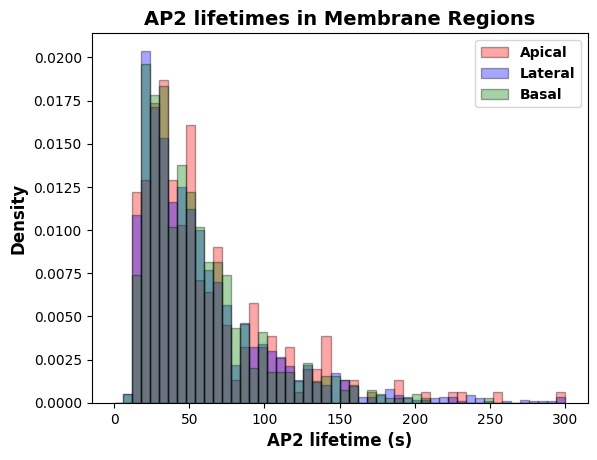

In [97]:
tracks_channel_subset_treatment = trackFilter('All', False, filtered_tracks_treatment)
lumenoid2_frame_ms = 2100
createHistogramAP2Lifetimes(tracks_channel_subset_treatment,lumenoid2_frame_ms,False)

<module 'matplotlib.pyplot' from 'c:\\Users\\Kenny\\anaconda3\\envs\\cme_pipeline\\lib\\site-packages\\matplotlib\\pyplot.py'>

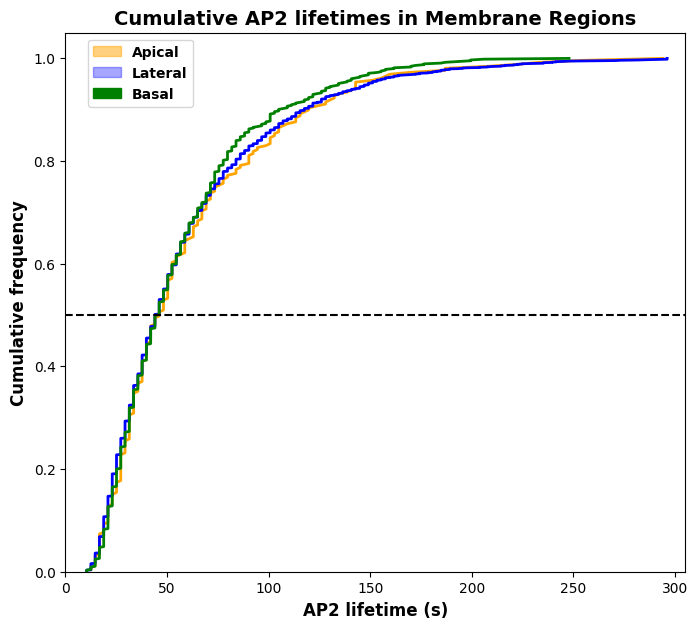

In [98]:
# Cumulative plot of track lifetimes
plot_cumulative_lifetime(tracks_channel_subset_treatment, lumenoid2_frame_ms, [label1, label2, label3])


x: [0.85 1.15]
y: [46.2 46.2]
x: [1.85 2.15]
y: [44.1 44.1]
x: [2.85 3.15]
y: [46.2 46.2]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_26924\1416389447.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[label1, label2, label3])


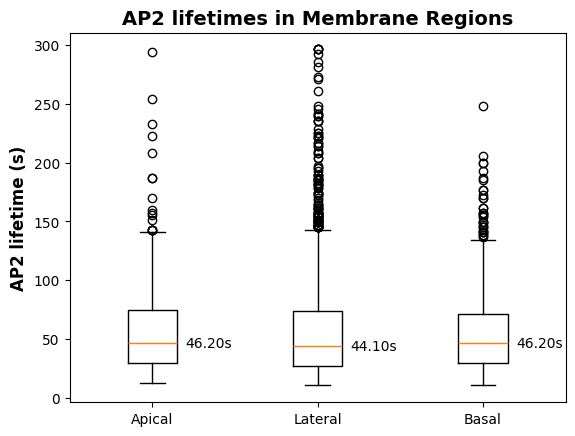

In [99]:
createBoxWhiskerPlot(tracks_channel_subset_treatment,False,lumenoid2_frame_ms)

In [100]:
apical_tracks = trackFilter('Apical', False, filtered_tracks_treatment)
filtered_tracks_treatment.columns

Index(['mu_x', 'mu_y', 'mu_z', 'track_id', 'track_length', 'track_start',
       'track_end', 'c3_peak', 'c2_peak', 'c1_peak', 'c3_peak_frame',
       'c2_peak_frame', 'c1_peak_frame', 'mean_displacement', 'mean_z',
       'mean_z_displacement', 'max_radius_from_origin',
       'max_distance_between_two_points', 'c3_voxel_sum_adjusted',
       'c2_voxel_sum_adjusted', 'c1_voxel_sum_adjusted',
       'c3_voxel_sum_adjusted_peak', 'c2_voxel_sum_adjusted_peak',
       'c1_voxel_sum_adjusted_peak', 'c3_voxel_sum_adjusted_peak_frame',
       'c2_voxel_sum_adjusted_peak_frame', 'c1_voxel_sum_adjusted_peak_frame',
       'max_z_movement', 'max_y_movement', 'max_x_movement',
       'channel2_positive', 'channel1_positive', 'membrane_region',
       'track_radius'],
      dtype='object')

## Lumenoid 1 Plots

In [36]:
compare_lumenoid_input_file_directory = 'lumenoid_1cropped_analysis/'
compare_lumenoid_df = pd.read_pickle(os.path.join(base_dir, compare_lumenoid_input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))
lumenoid1_frame_ms = 2200


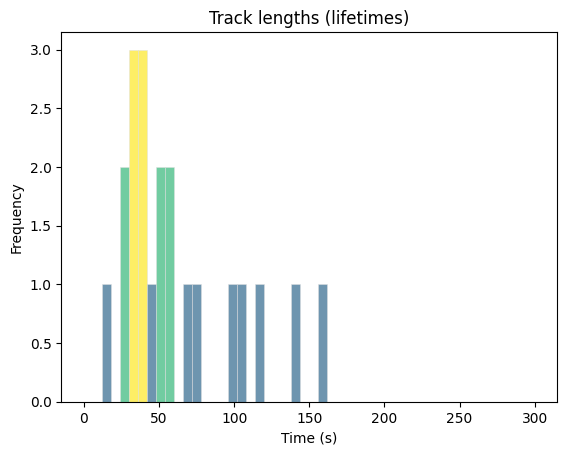

In [37]:
tracks_channel_subset_compare = trackFilter('All', False, compare_lumenoid_df)
createHistogramAP2Lifetimes(tracks_channel_subset_compare,lumenoid1_frame_ms,True)

x: [0.85 1.15]
y: [44. 44.]
x: [1.85 2.15]
y: [24.2 24.2]
x: [2.85 3.15]
y: [24.2 24.2]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_22148\1416389447.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[label1, label2, label3])


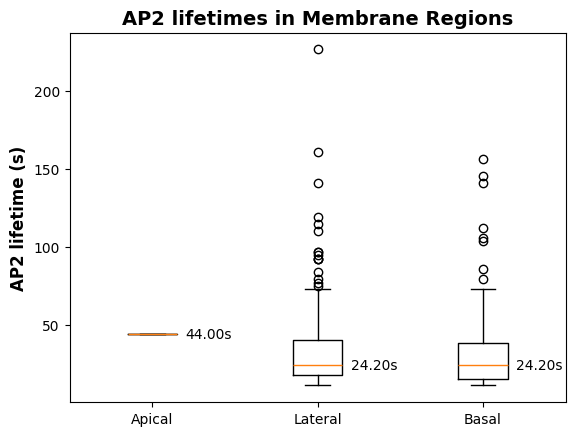

In [38]:
createBoxWhiskerPlot(compare_lumenoid_df,False,lumenoid1_frame_ms)

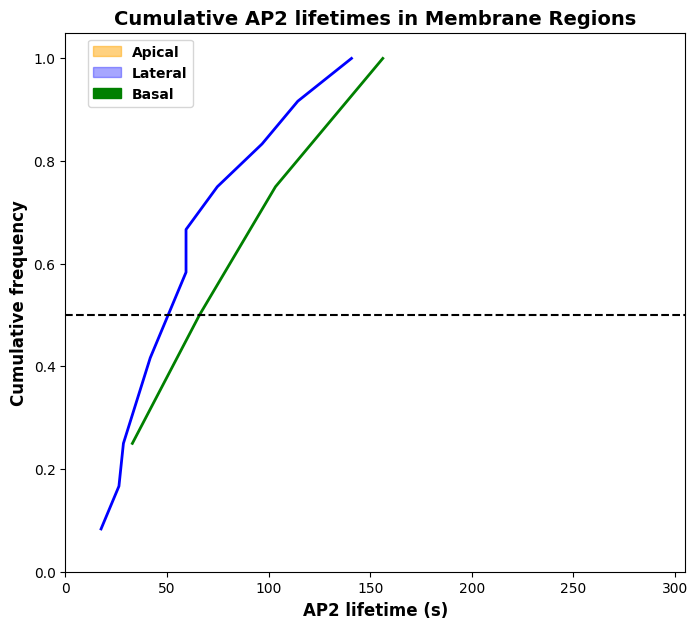

In [39]:

# plt = plot_cumulative_lifetime(all_lifetimes_control_df, all_lifetimes_treatment_df, [label1, label2], title)
plt = plot_cumulative_lifetime(tracks_channel_subset_compare, lumenoid1_frame_ms, [label1, label2, label3])
# if plot_all_channels == True:
#     plt.text(0.5, 0.8, f'Plotting all channels: {plot_all_channels}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# if plot_all_channels == False:
#     plt.text(0.5, 0.8, f'Plotting channels: {channels_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# plt.text(0.5, 0.75, f'Plotting region: {region_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')

plt.show()

## New Lumenoid from Valerie

In [37]:
new_lumenoid_input_file_directory = '20250717_MA3_Day3_5min_10um-05_analysis/'
new_lumenoid_filtered_tracks = pd.read_pickle(os.path.join(base_dir, new_lumenoid_input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))
new_lumenoid_frame_ms = 1500


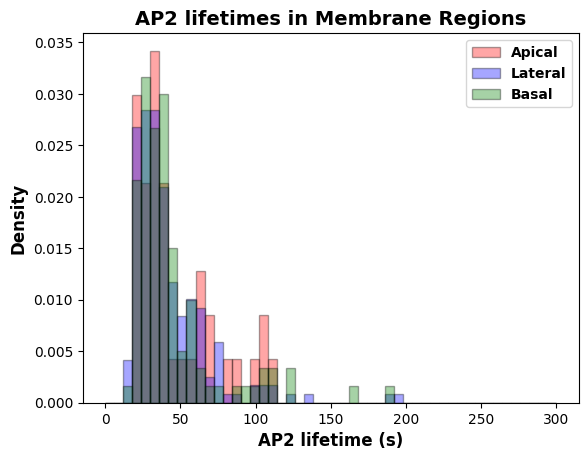

In [38]:
new_lumenoid_histogram = trackFilter('All', False, new_lumenoid_filtered_tracks)
createHistogramAP2Lifetimes(new_lumenoid_histogram,new_lumenoid_frame_ms,False)

x: [0.85 1.15]
y: [31.5 31.5]
x: [1.85 2.15]
y: [28.5 28.5]
x: [2.85 3.15]
y: [25.5 25.5]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_18544\1416389447.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[label1, label2, label3])


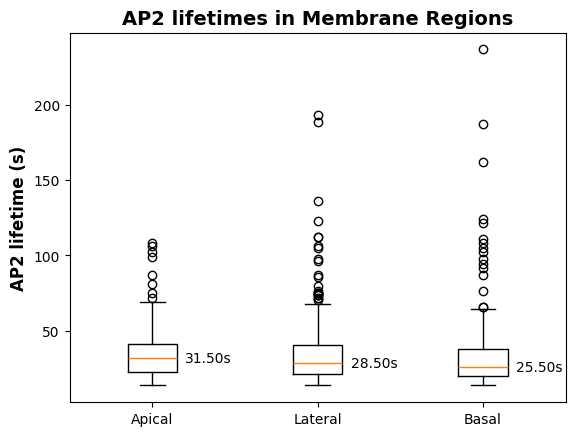

In [39]:
createBoxWhiskerPlot(new_lumenoid_filtered_tracks,False,new_lumenoid_frame_ms)

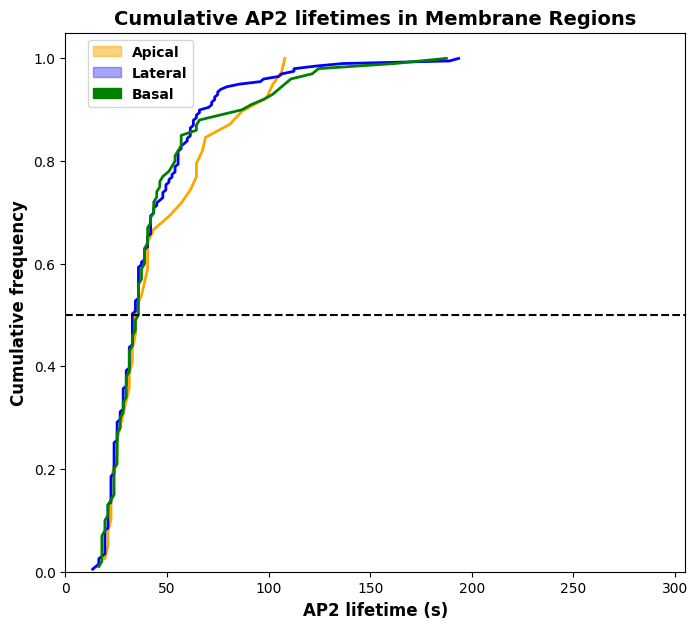

In [40]:

# plt = plot_cumulative_lifetime(all_lifetimes_control_df, all_lifetimes_treatment_df, [label1, label2], title)
plt = plot_cumulative_lifetime(new_lumenoid_histogram, new_lumenoid_frame_ms, [label1, label2, label3])
# if plot_all_channels == True:
#     plt.text(0.5, 0.8, f'Plotting all channels: {plot_all_channels}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# if plot_all_channels == False:
#     plt.text(0.5, 0.8, f'Plotting channels: {channels_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')
# plt.text(0.5, 0.75, f'Plotting region: {region_to_plot}', transform=plt.gca().transAxes, fontsize=12, weight='bold')

plt.show()

## Lumenoid 1 and Lumenoid 2 Comparasion Plots

x: [0.925 1.075]
y: [44.1 44.1]
x: [1.925 2.075]
y: [29.4 29.4]


C:\Users\Kenny\AppData\Local\Temp\ipykernel_22492\696557318.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[lumenoid1_name, lumenoid2_name])


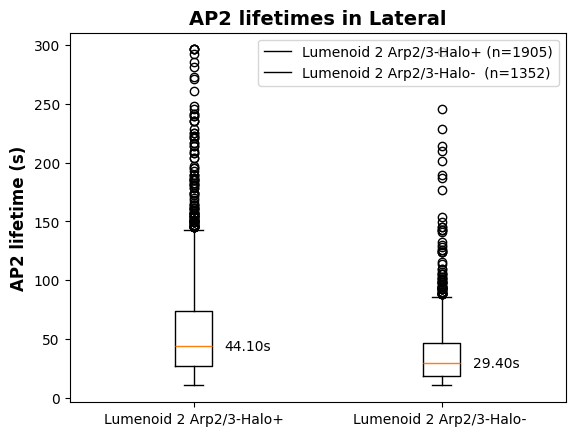

In [ ]:
channels_to_plot = [True,True]
arp_negative = [False, True]
first_lumenoid = trackFilter('All', False, filtered_tracks_treatment, channels_to_plot)
second_lumenoid = trackFilter('All', False, filtered_tracks_treatment,arp_negative)
compareLumenoidsBoxPlot(first_lumenoid, second_lumenoid, 'Lateral', 'Lumenoid 2 Arp2/3-Halo+', 'Lumenoid 2 Arp2/3-Halo- ', lumenoid2_frame_ms, lumenoid2_frame_ms)


C:\Users\Kenny\AppData\Local\Temp\ipykernel_18544\696557318.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data, labels=[lumenoid1_name, lumenoid2_name])


x: [0.925 1.075]
y: [44.1 44.1]
x: [1.925 2.075]
y: [29.4 29.4]


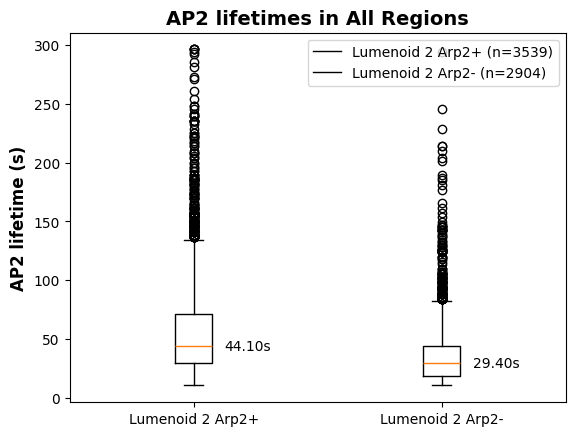

In [91]:
channels_to_plot = [True,True]
arp_negative = [False, True]
dynamin_negative = [True, False]
first_lumenoid = trackFilter('All', False, filtered_tracks_treatment,channels_to_plot)
second_lumenoid = trackFilter('All', False, filtered_tracks_treatment,arp_negative)
compareLumenoidsBoxPlot(first_lumenoid, second_lumenoid, 'All', 'Lumenoid 2 Arp2+', 'Lumenoid 2 Arp2-', lumenoid2_frame_ms, lumenoid2_frame_ms)


In [ ]:
calculate_region_stats(filtered_tracks_treatment, lumenoid2_frame_ms, 'channel1', 'Apical')

Total tracks in Apical: 880
Total Arp2/3+ Dynamin+ in Apical: 259
Total Arp2/3- Dynamin+ in Apical: 230
Percentage of Arp2/3+ Dynamin+ tracks in Apical: 29.43%
Percentage of Arp2/3- Dynamin+ in Apical: 26.14%
Mean lifetime of Arp2/3+ Dynamin+ in Apical: 60.35 s
Mean lifetime of Arp2/3- Dynamin+ in Apical: 36.43 s


## Intensity Plots

In [42]:
lumenoid_intensity = trackFilter('All', False, filtered_tracks_treatment,channels_to_plot)
intensity_region_plot(lumenoid_intensity,True,True,'channel1')

NameError: name 'channels_to_plot' is not defined

In [ ]:
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
intensity_track = pd.read_pickle(input_directory_all_tracks_full)

#### Apical Intensity

number of tracks between [5,10] frames long are 33
number of tracks between [11,15] frames long are 46
number of tracks between [16,20] frames long are 45
number of tracks between [21,25] frames long are 32
number of tracks between [26,30] frames long are 18
number of tracks between [31,40] frames long are 29
number of tracks between [41,90] frames long are 51


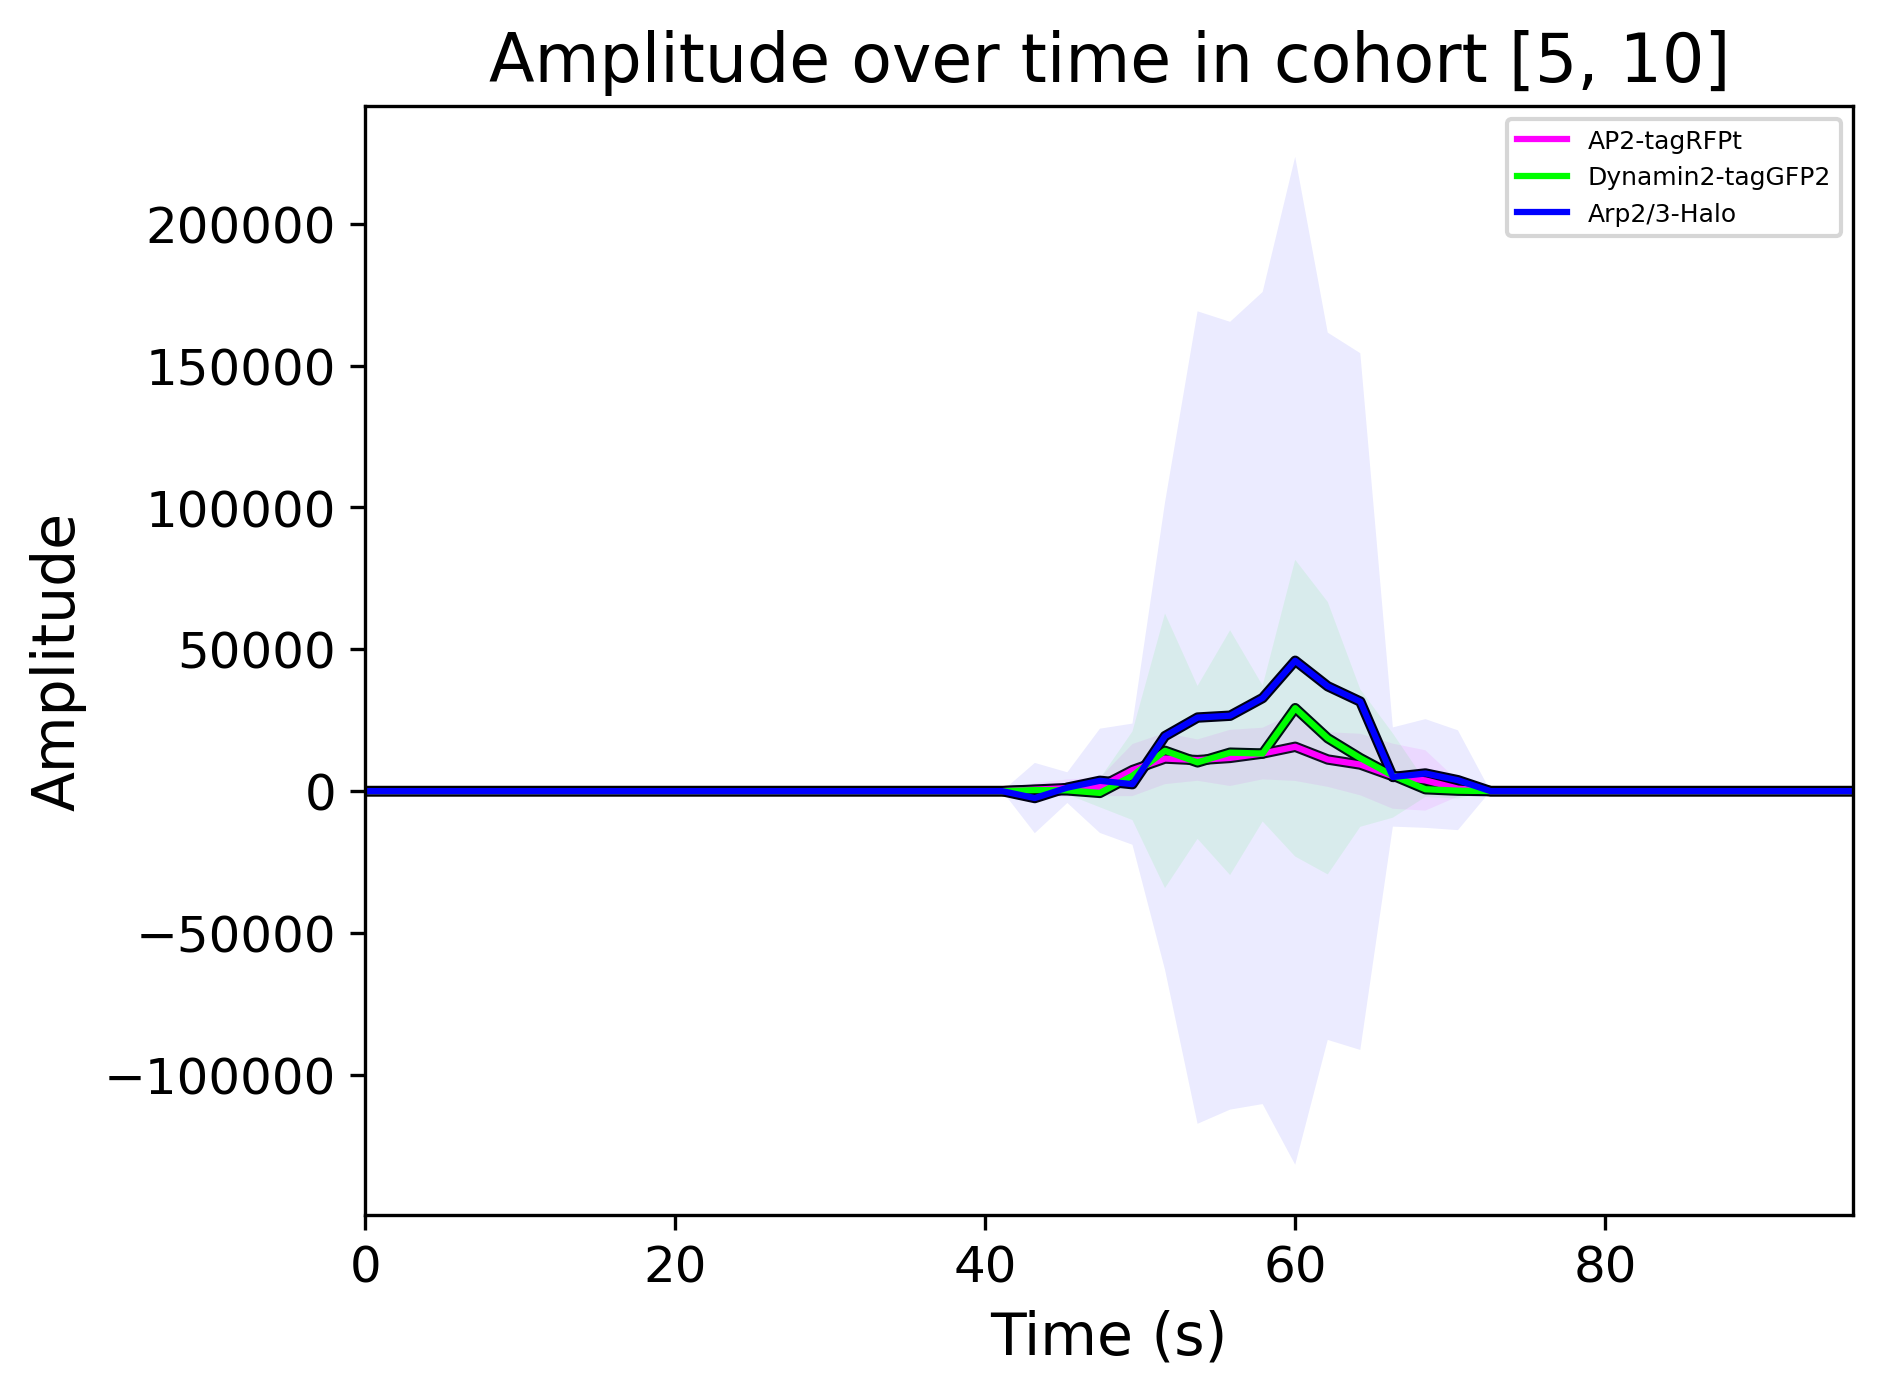

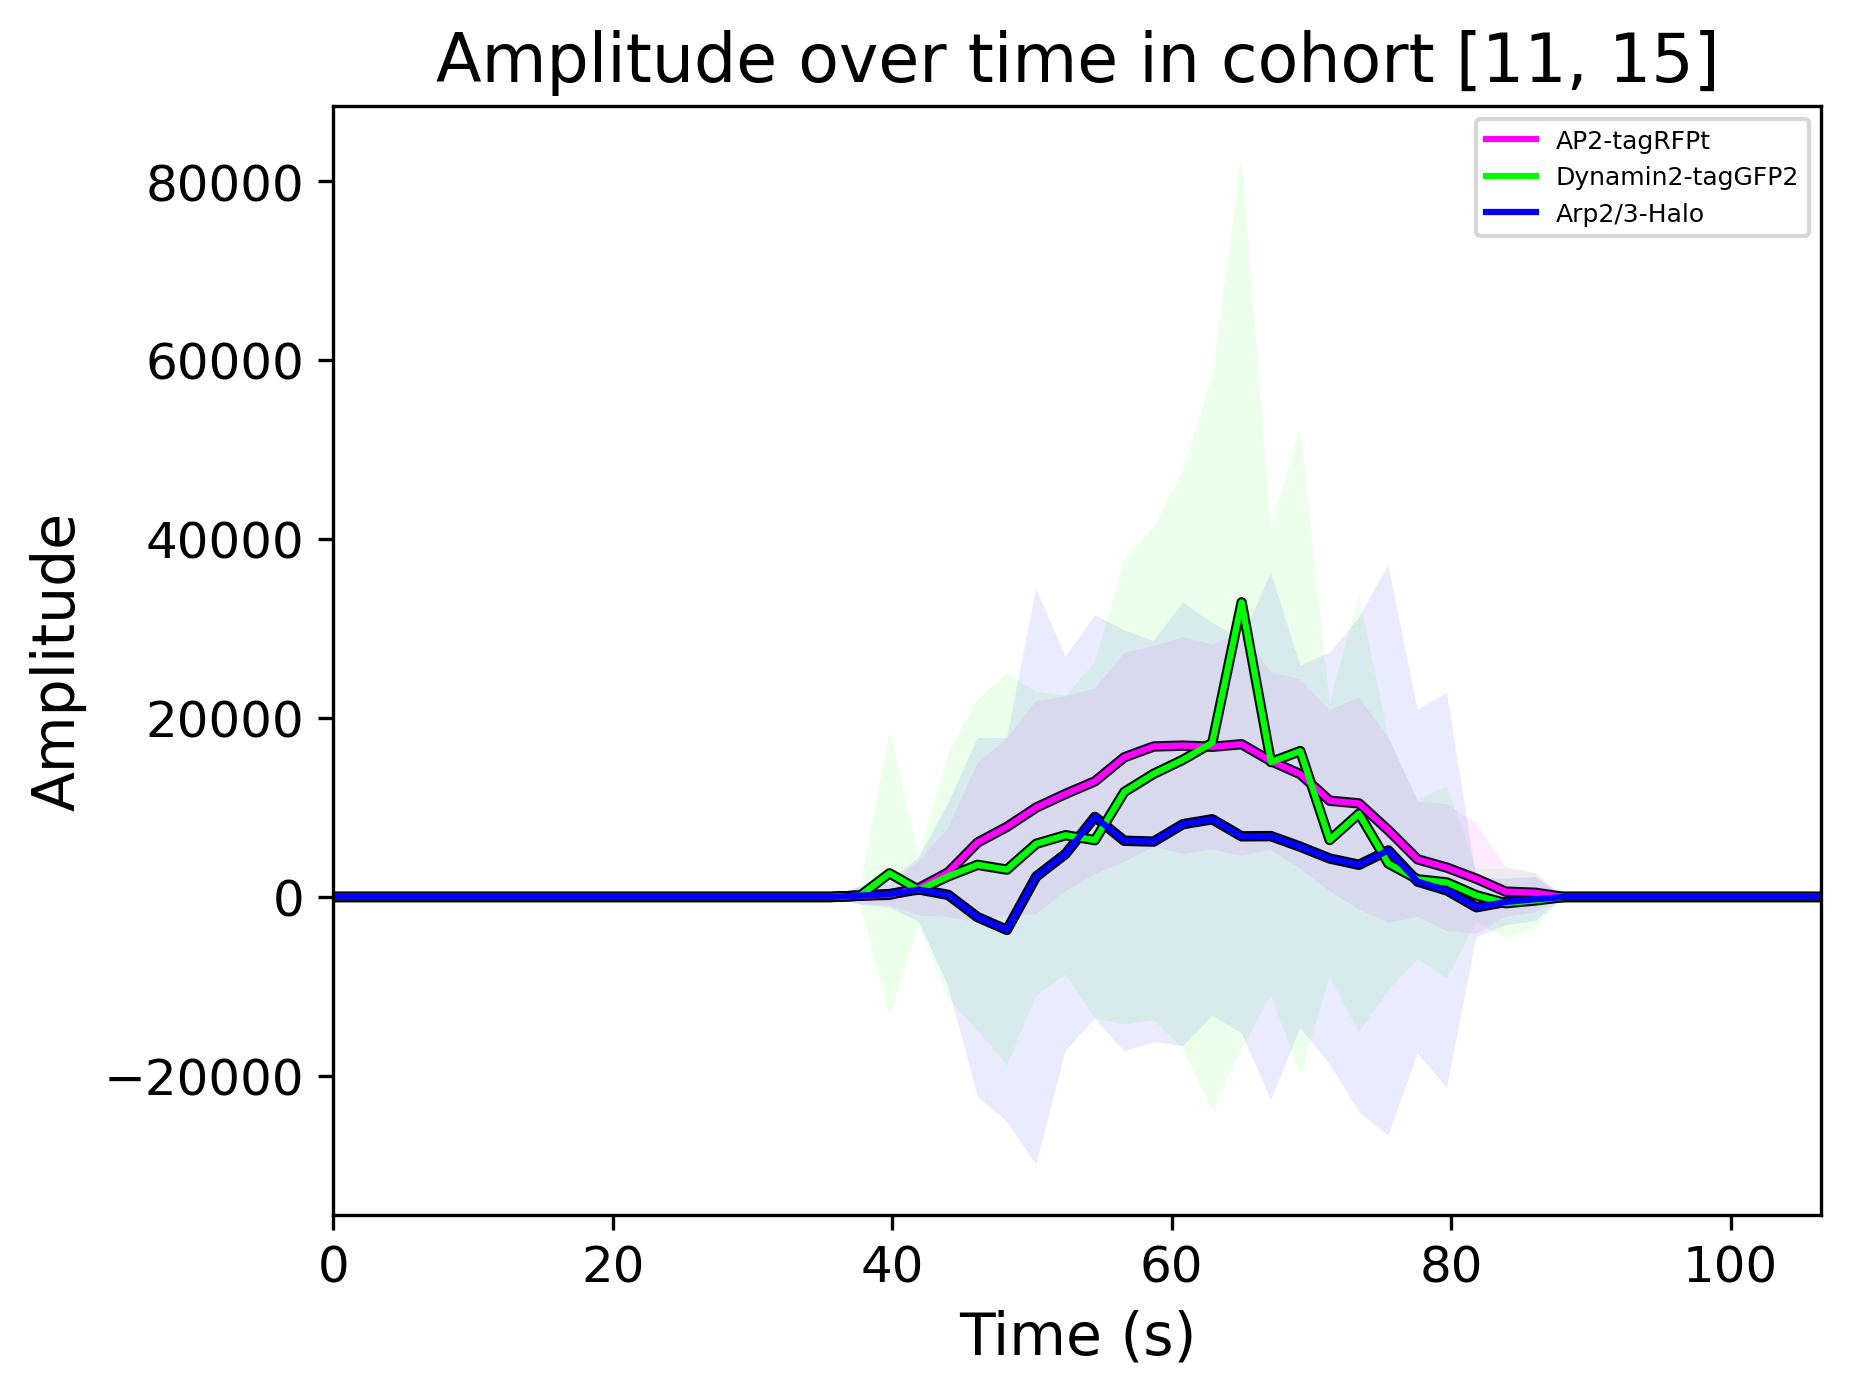

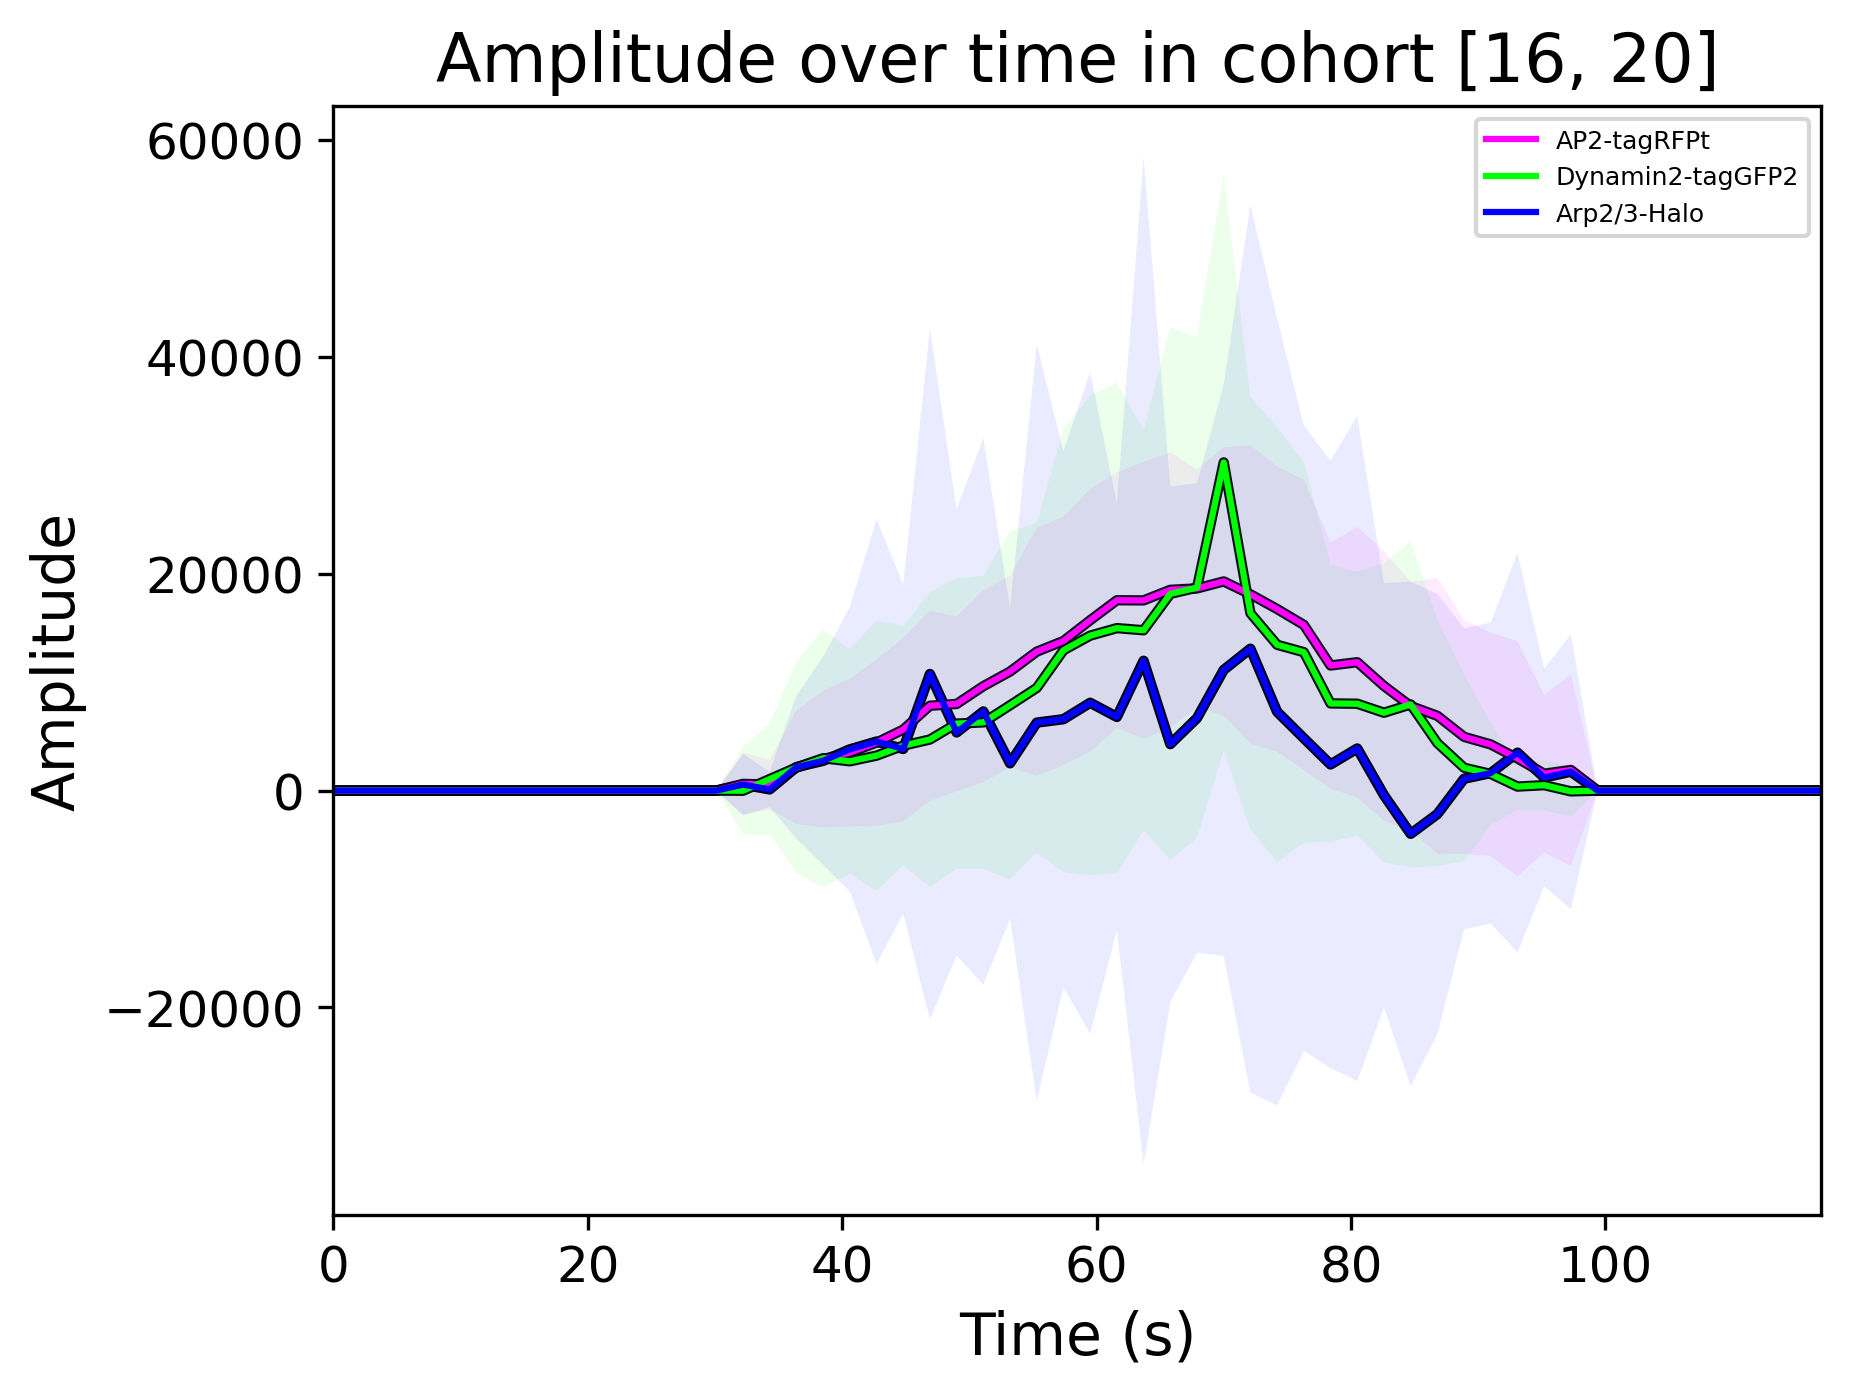

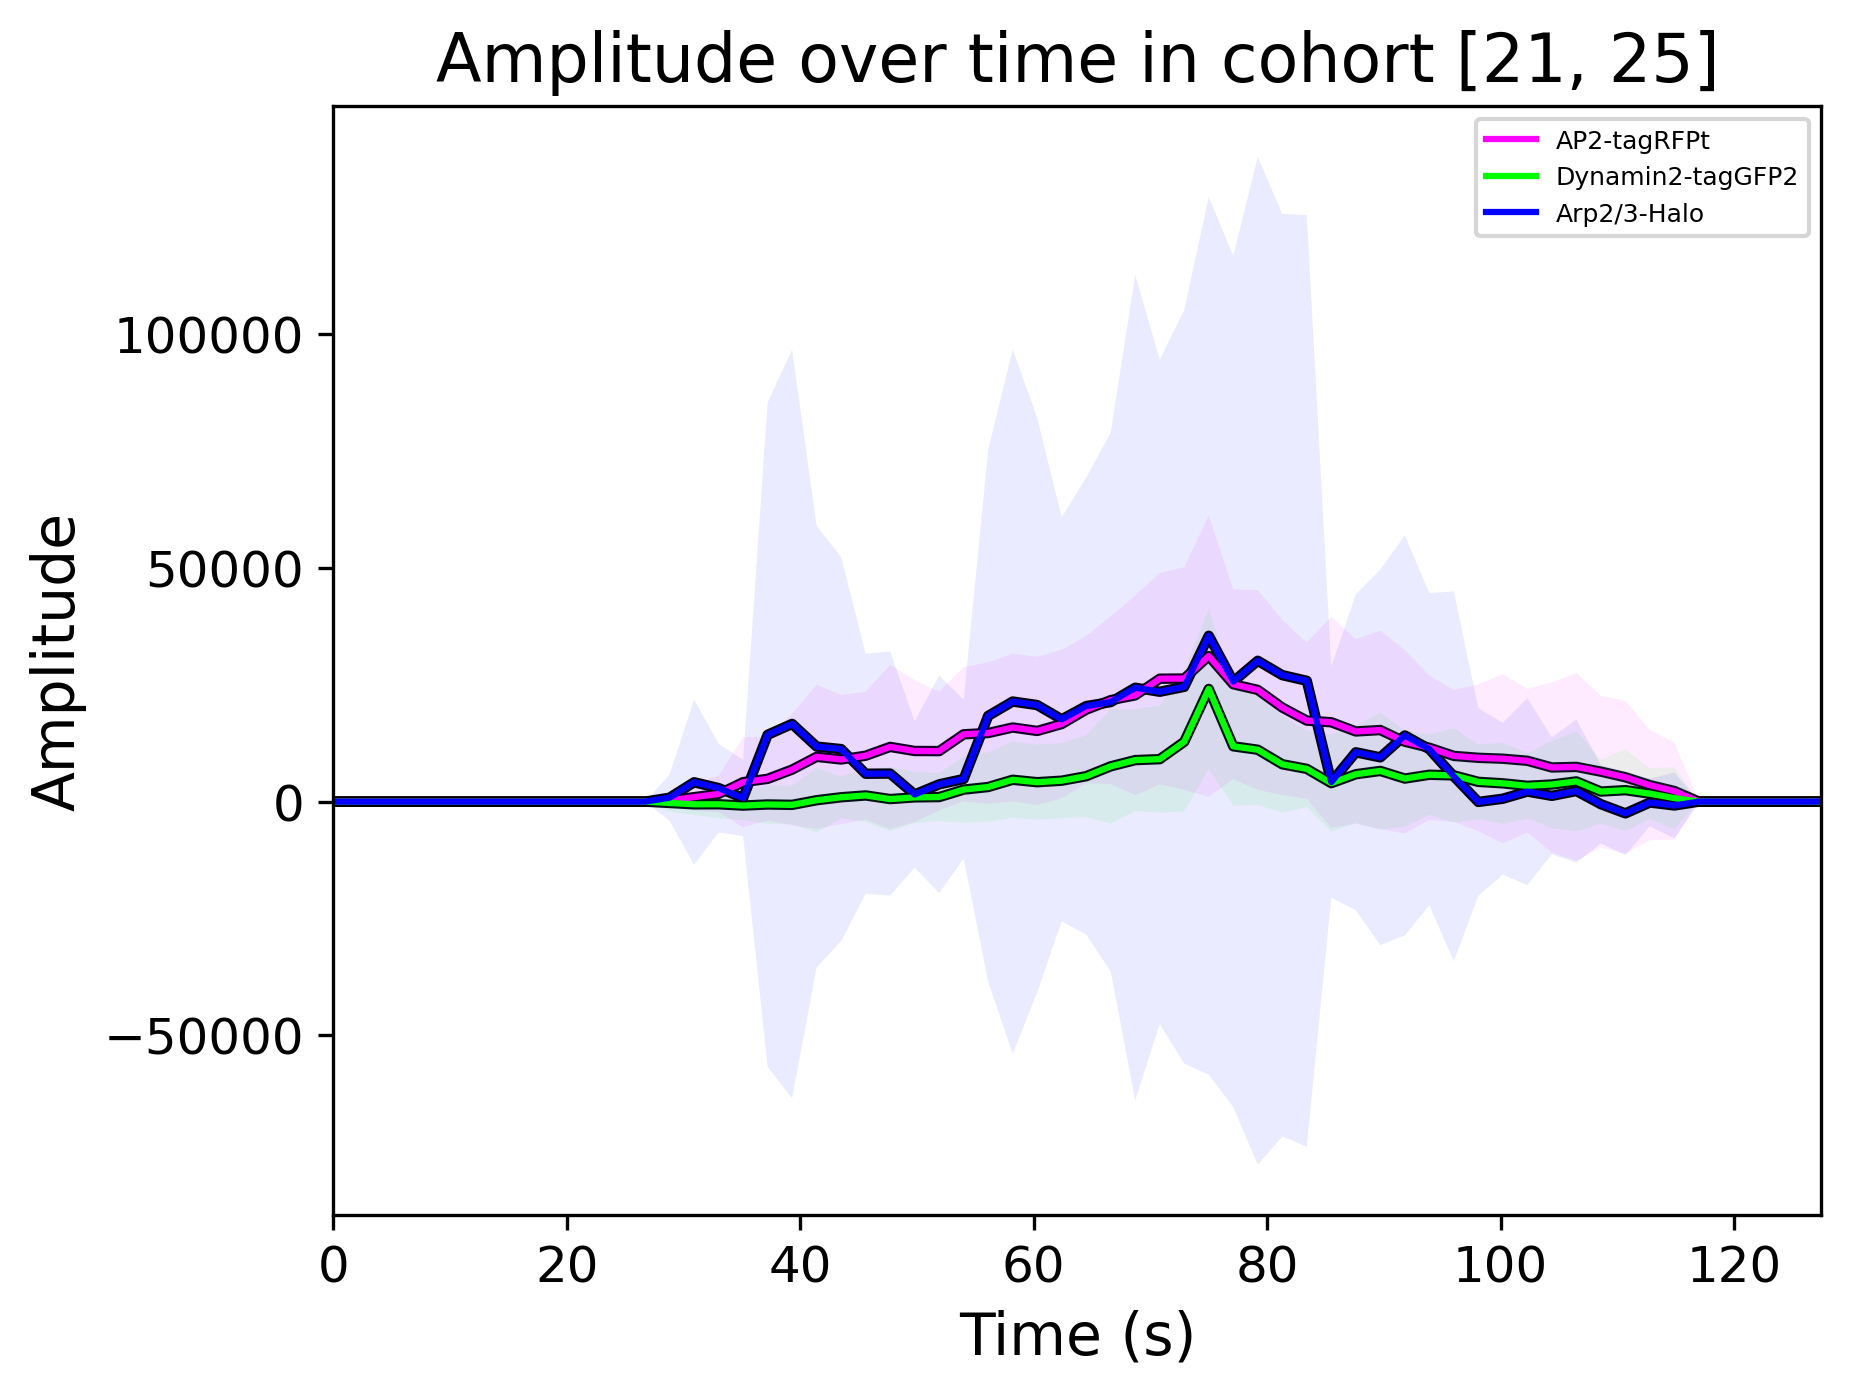

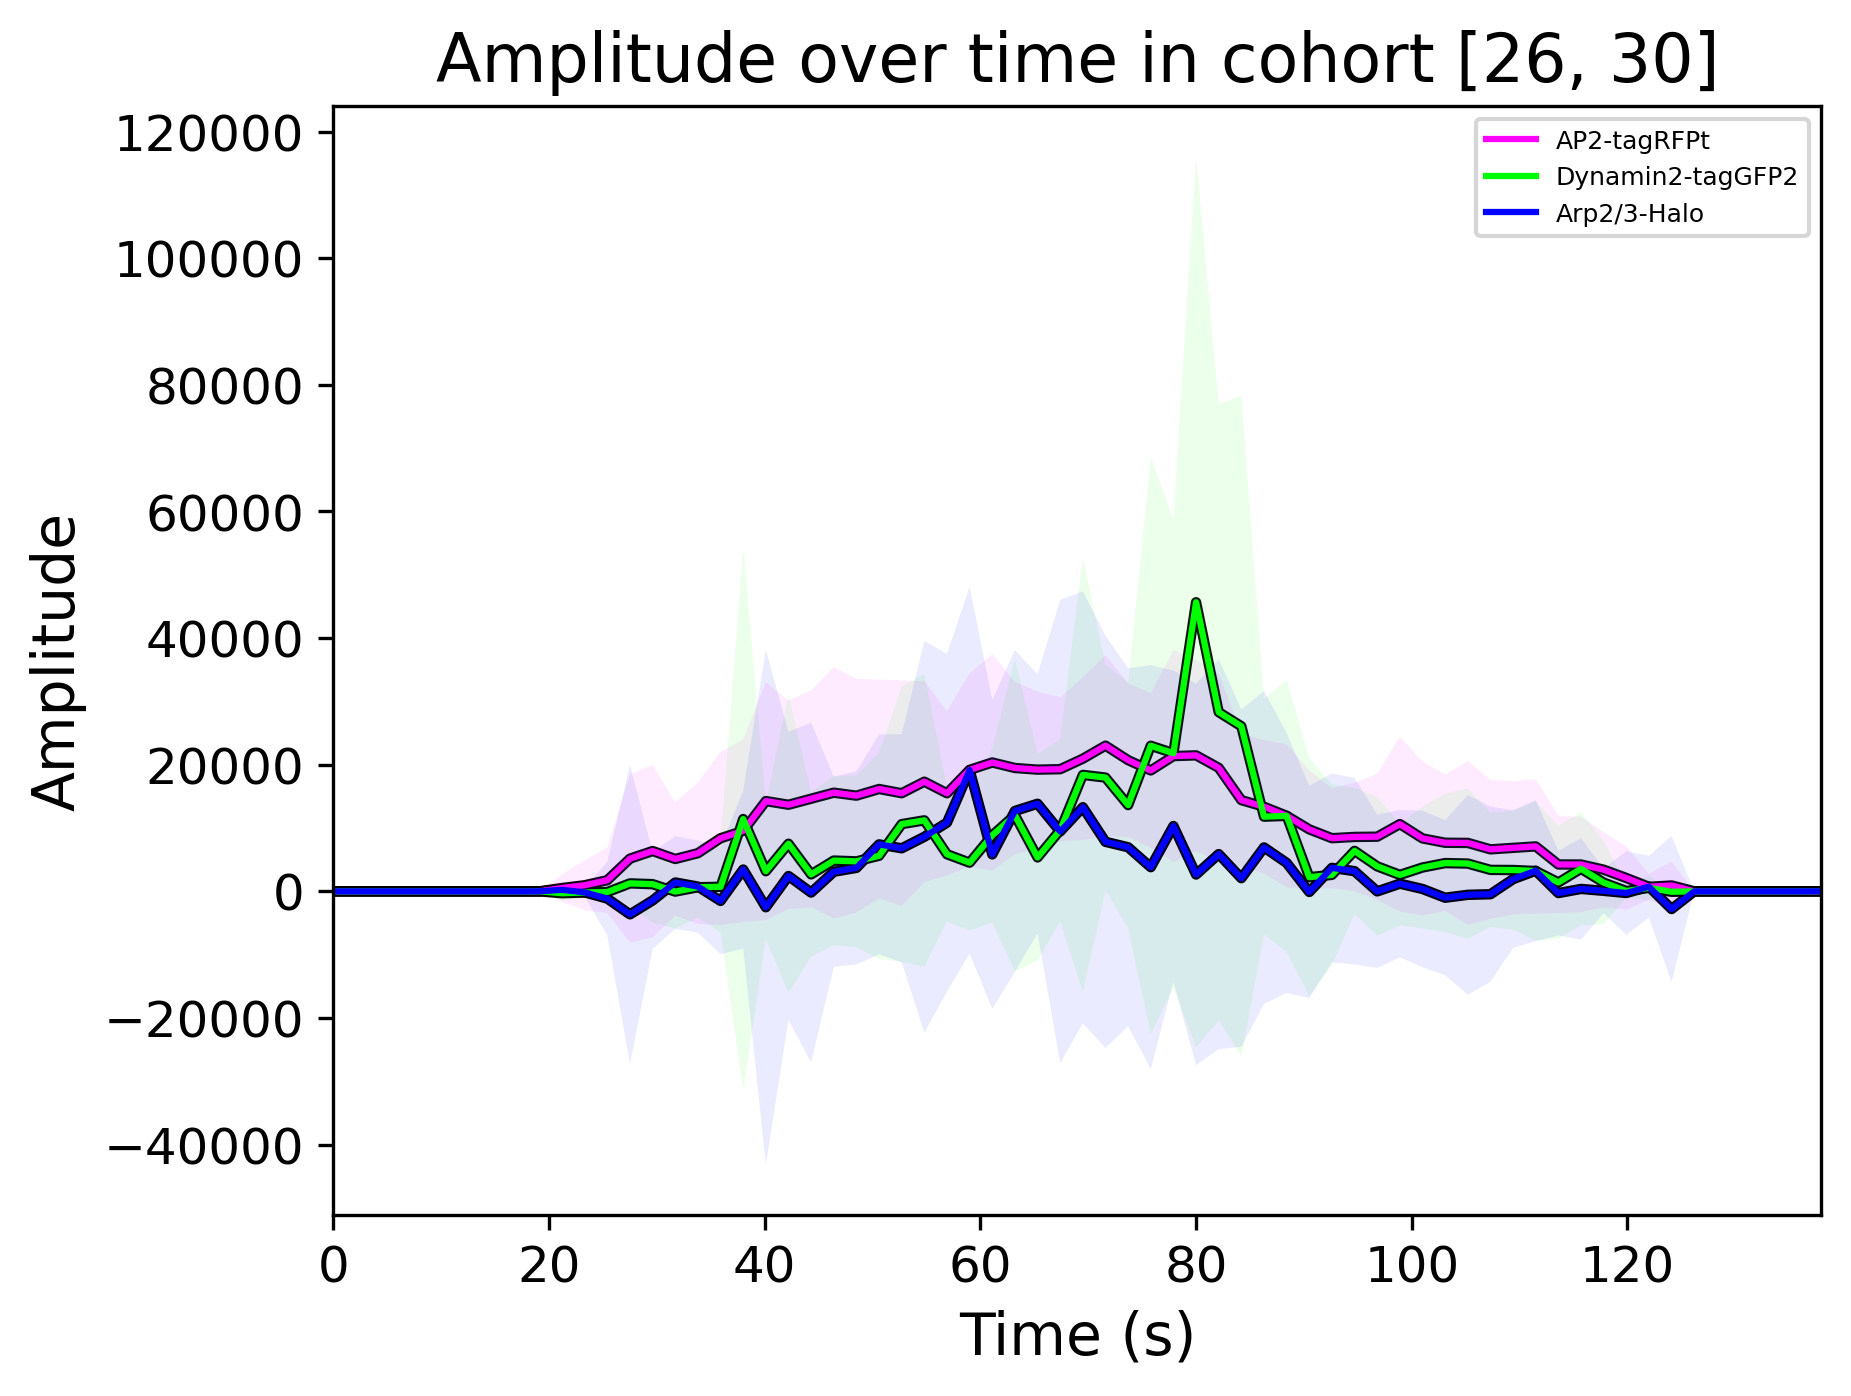

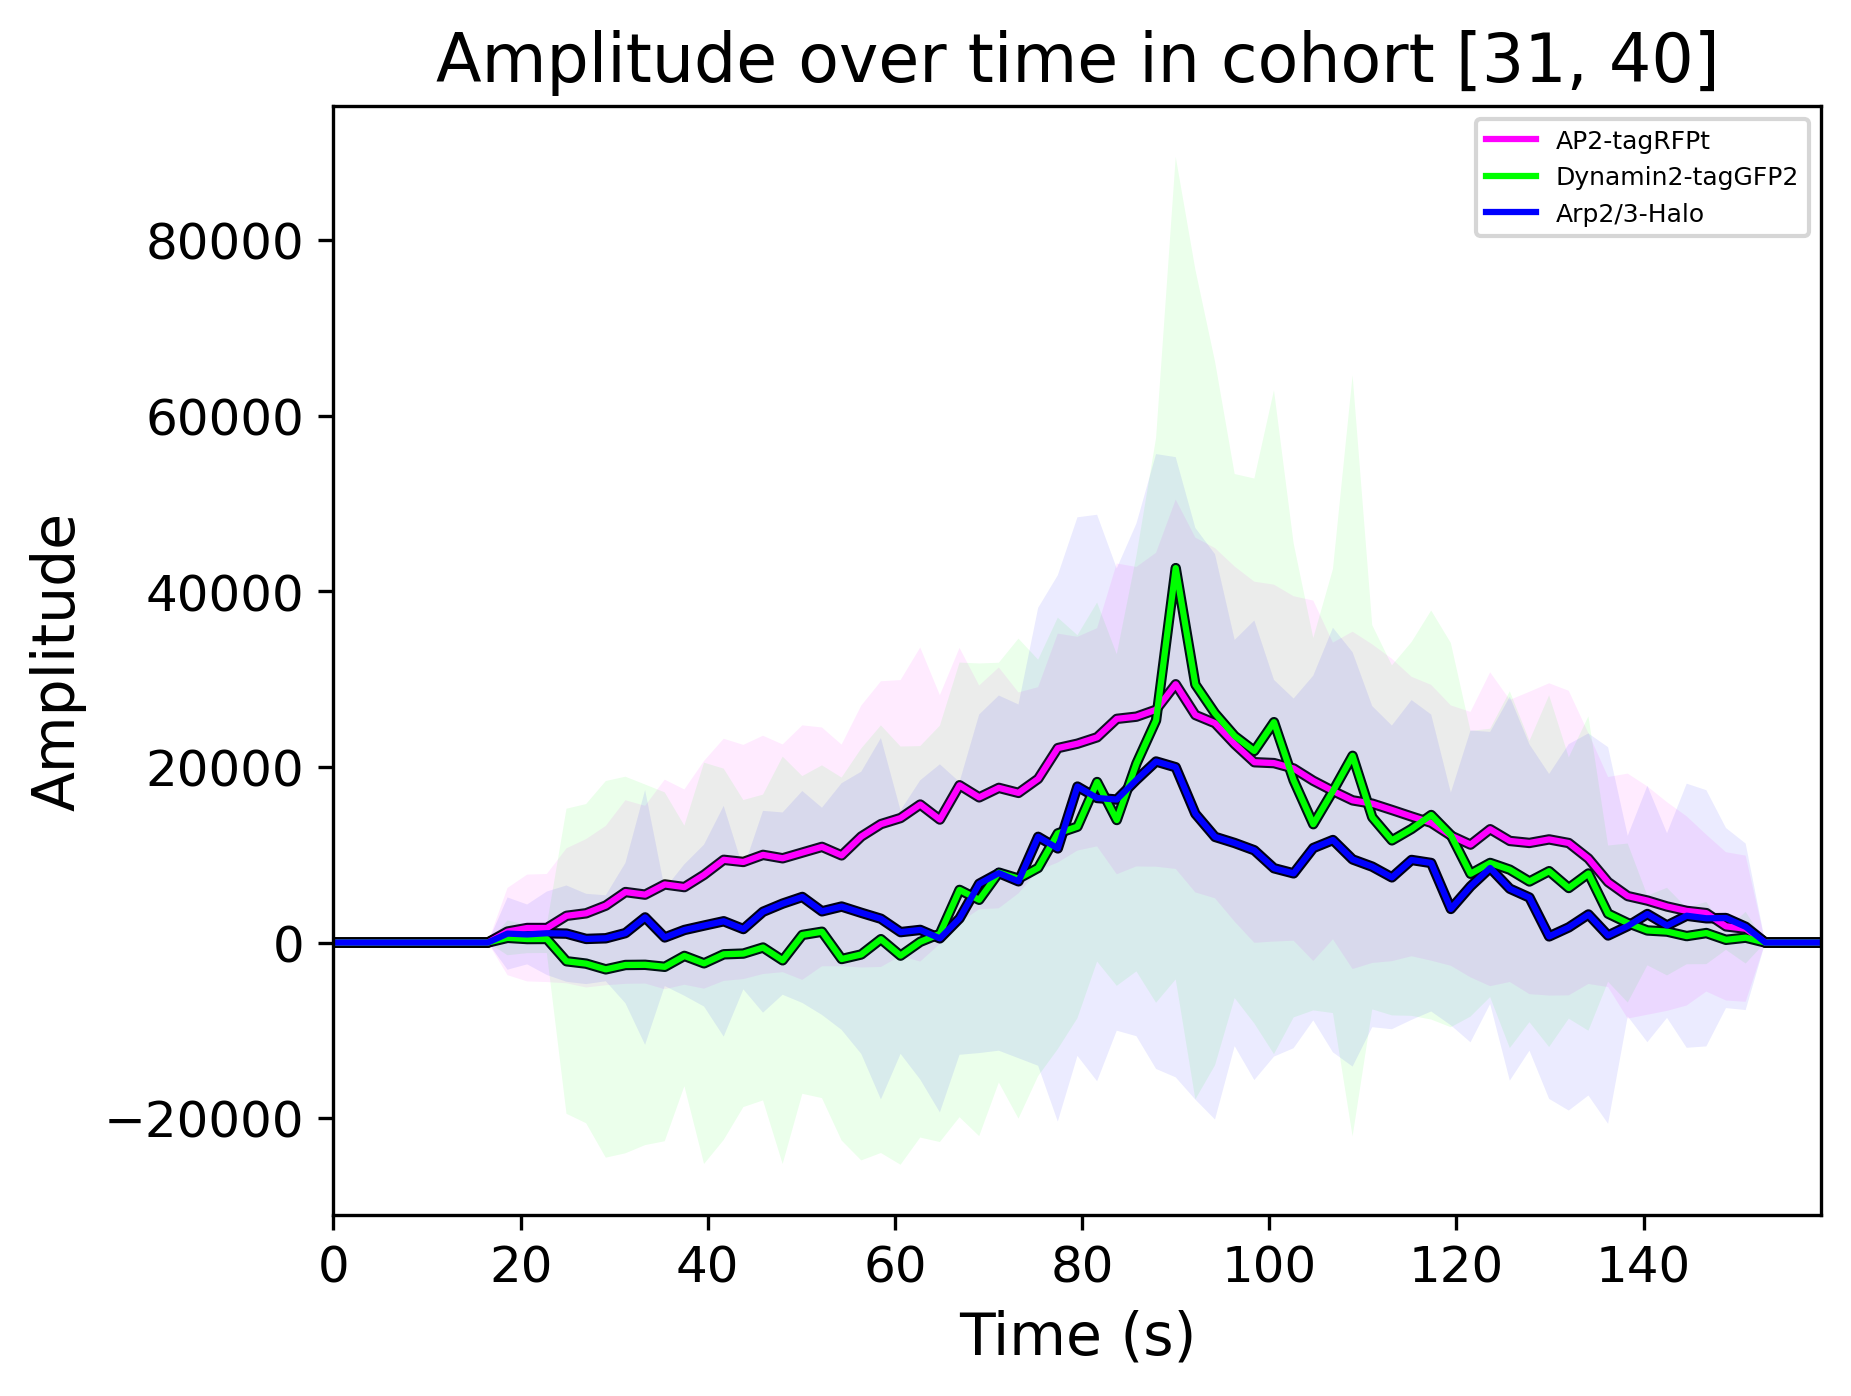

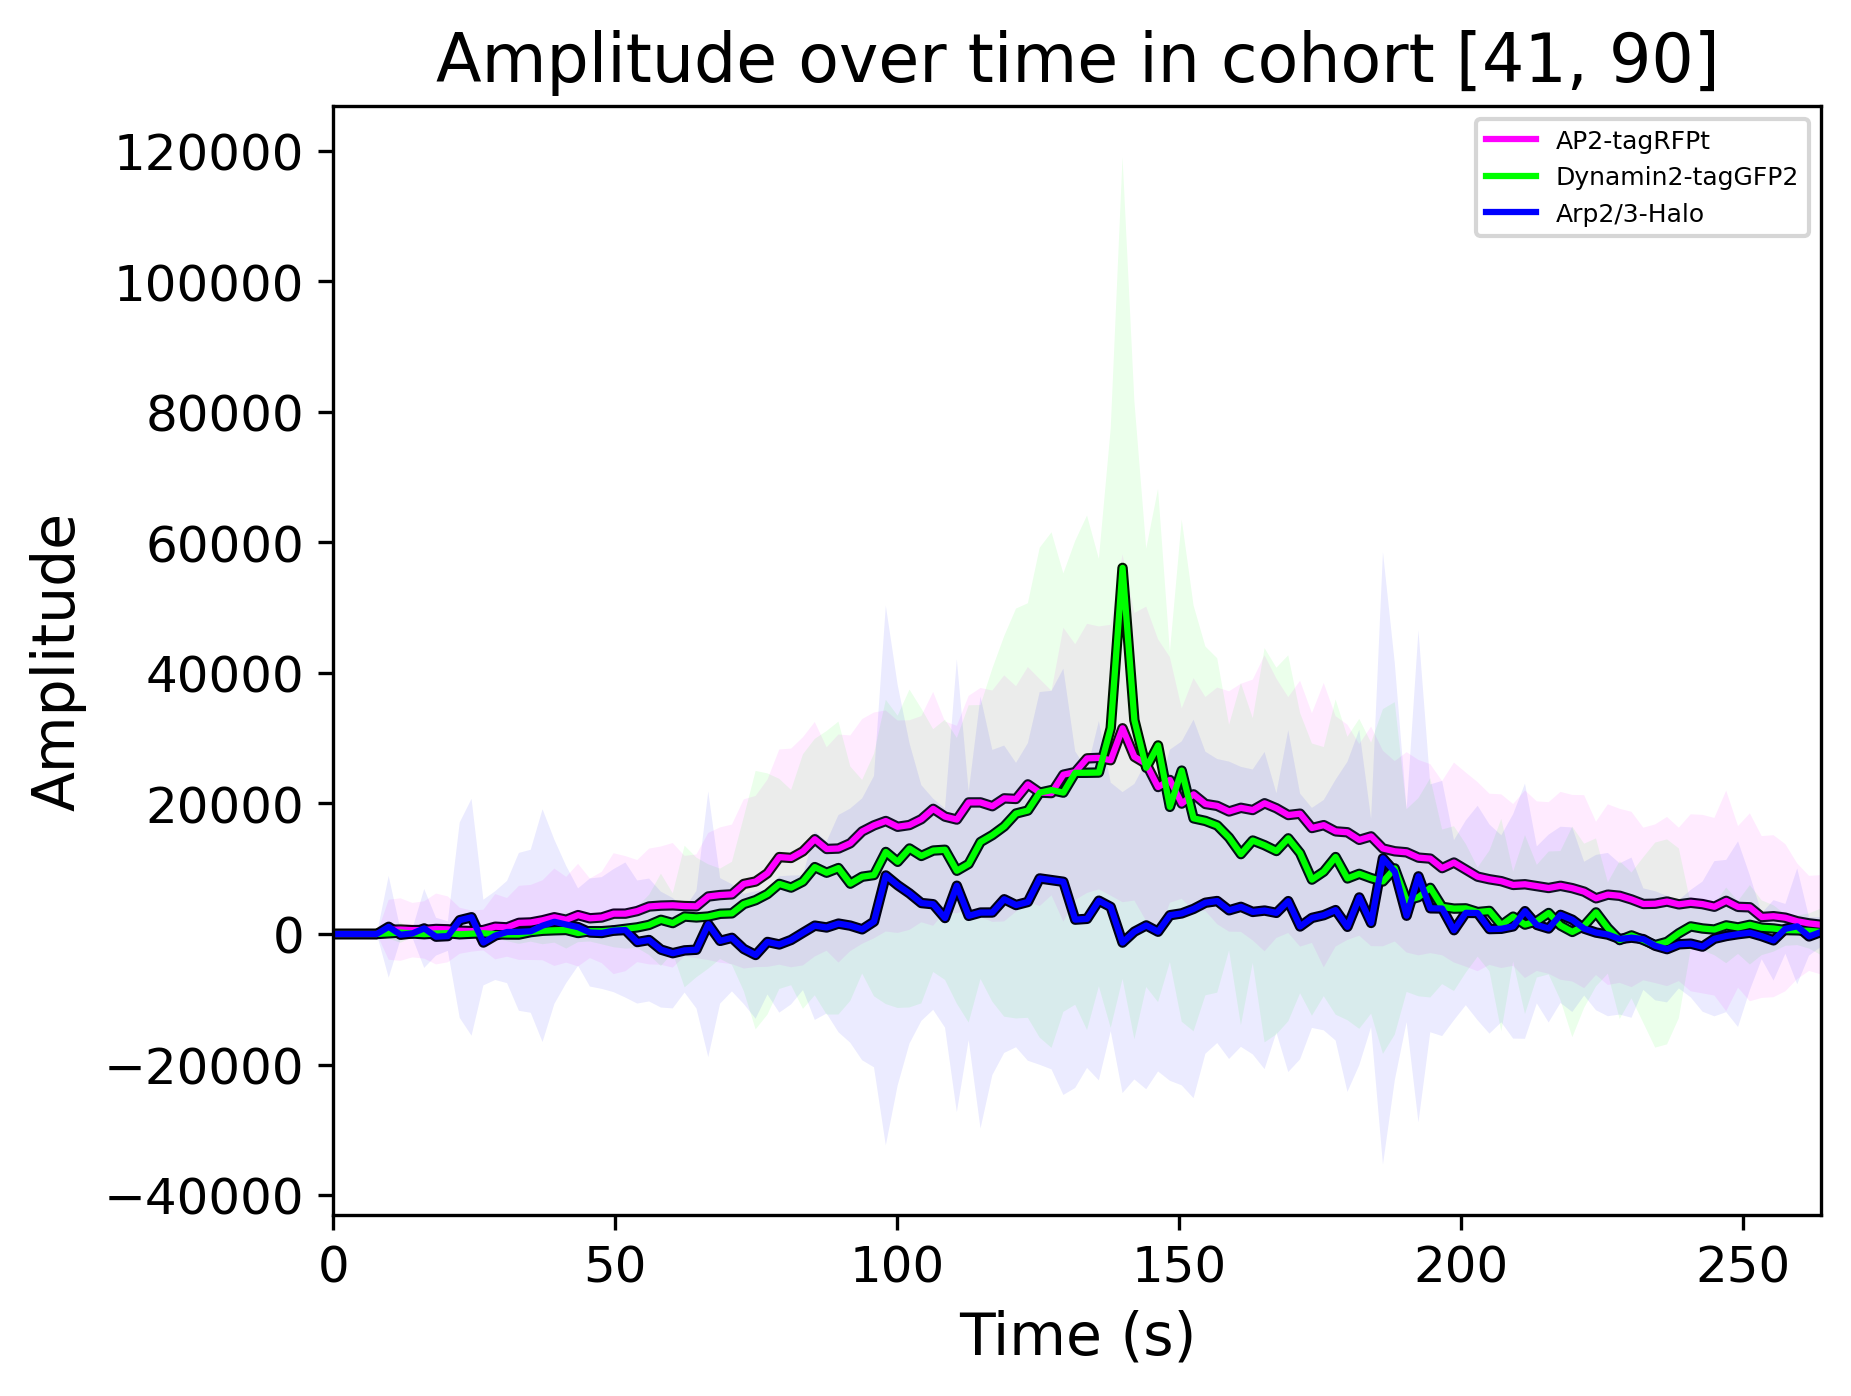

In [ ]:
apical_tracks = trackFilter('Apical', False, filtered_tracks_treatment)
track_id_arrays = filter_track_ids_by_length_ranges(dataframe = apical_tracks, track_length_buckets = custom_length_ranges, 
                                 track_id_col_name = 'track_id', track_length_col_name = 'track_length')

print(f'number of tracks between [5,10] frames long are {len(track_id_arrays[0])}')
print(f'number of tracks between [11,15] frames long are {len(track_id_arrays[1])}')
print(f'number of tracks between [16,20] frames long are {len(track_id_arrays[2])}')
print(f'number of tracks between [21,25] frames long are {len(track_id_arrays[3])}')
print(f'number of tracks between [26,30] frames long are {len(track_id_arrays[4])}')
print(f'number of tracks between [31,40] frames long are {len(track_id_arrays[5])}')
print(f'number of tracks between [41,90] frames long are {len(track_id_arrays[6])}')
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0
cohort_intensity(intensity_track,track_id_arrays, lumenoid2_frame_ms, [background_channel_3, background_channel_2, background_channel_1], value_to_plot=value_to_plot)



#### Lateral Intensity

number of tracks between [5,10] frames long are 280
number of tracks between [11,15] frames long are 338
number of tracks between [16,20] frames long are 292
number of tracks between [21,25] frames long are 228
number of tracks between [26,30] frames long are 177
number of tracks between [31,40] frames long are 216
number of tracks between [41,90] frames long are 335


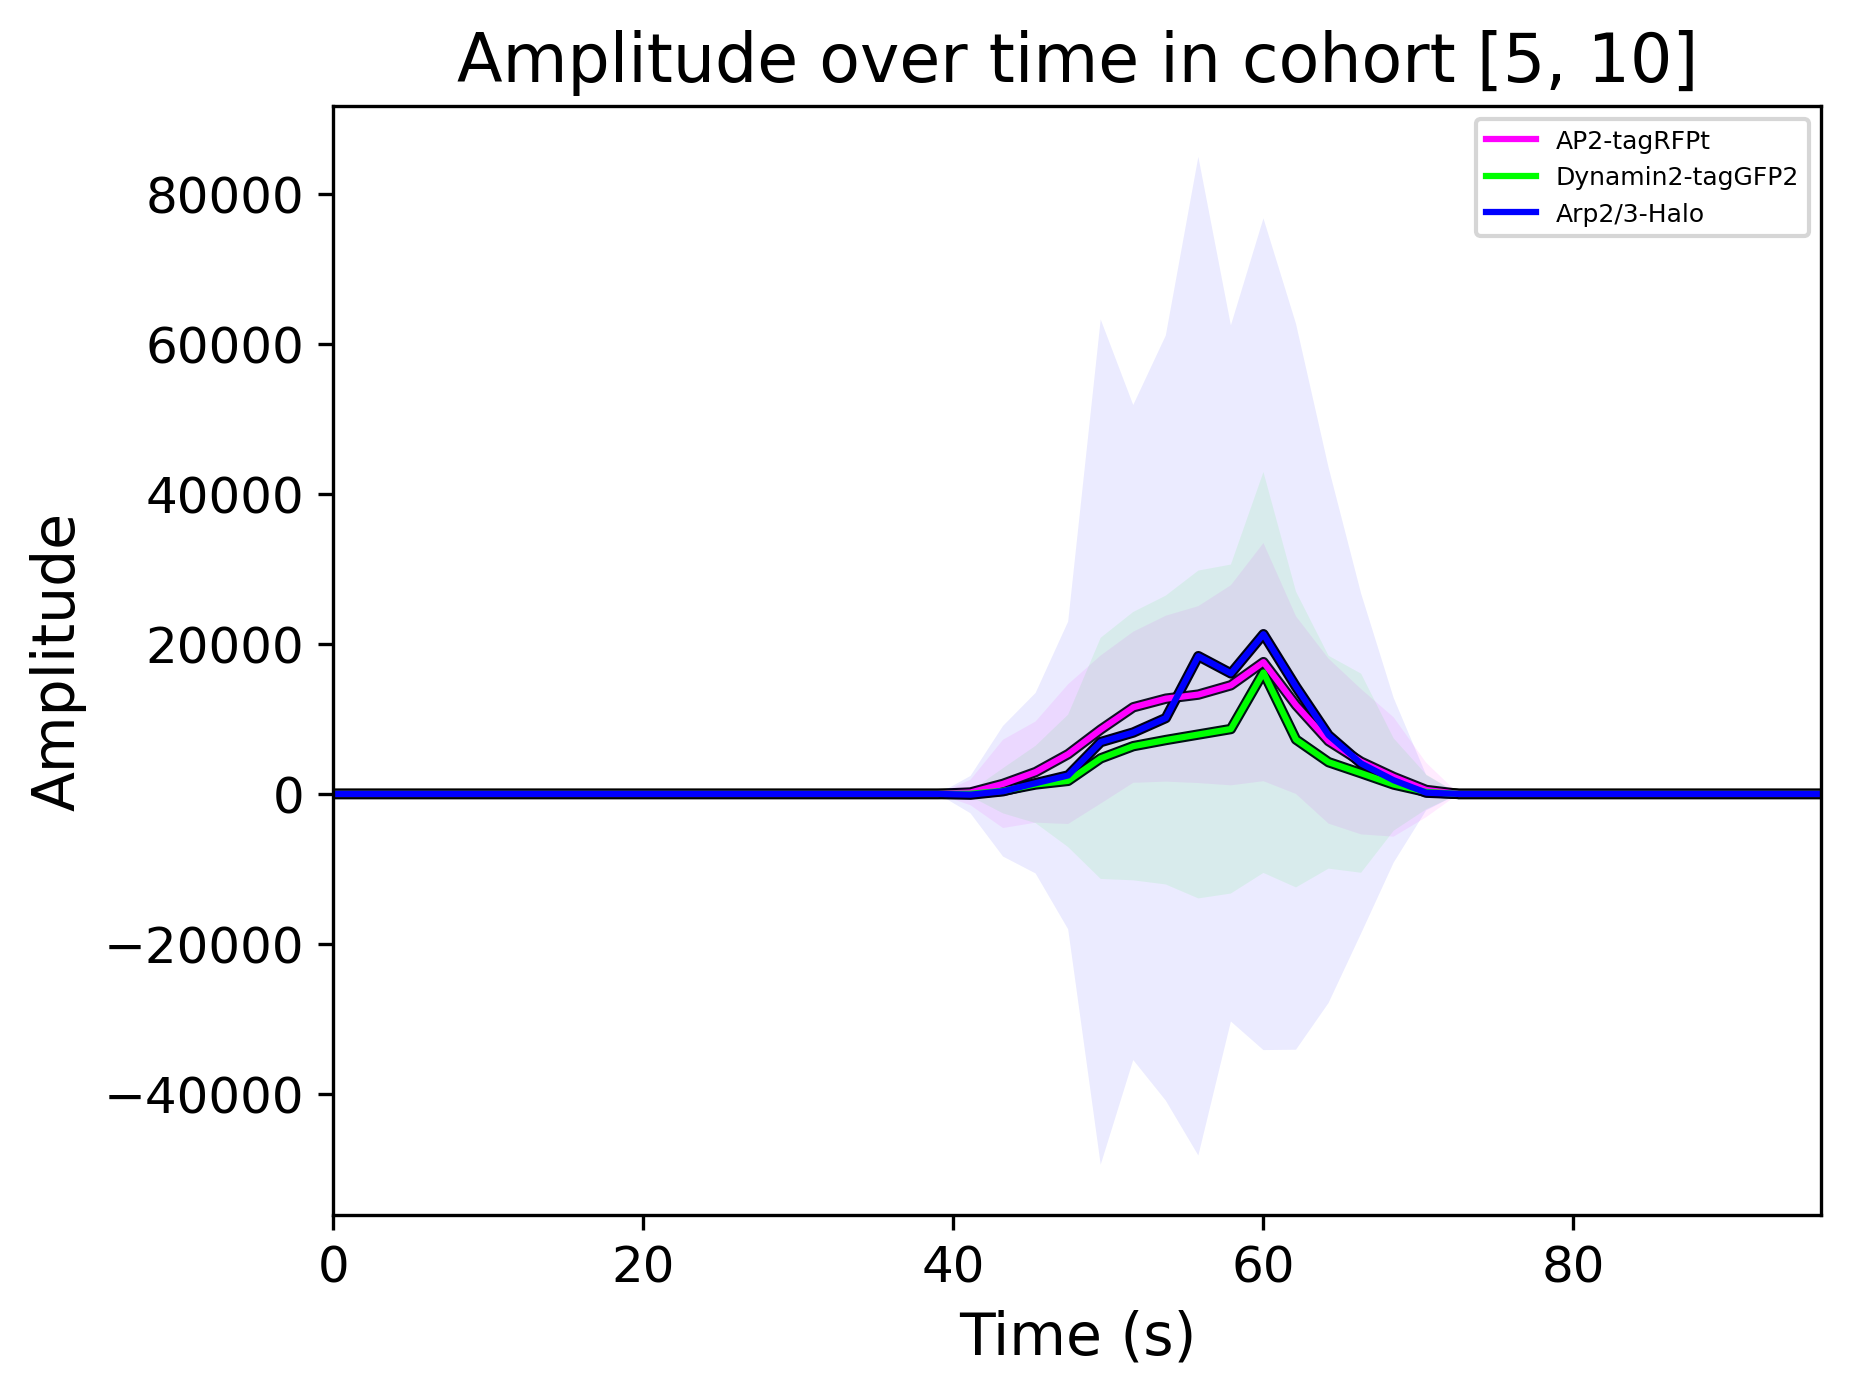

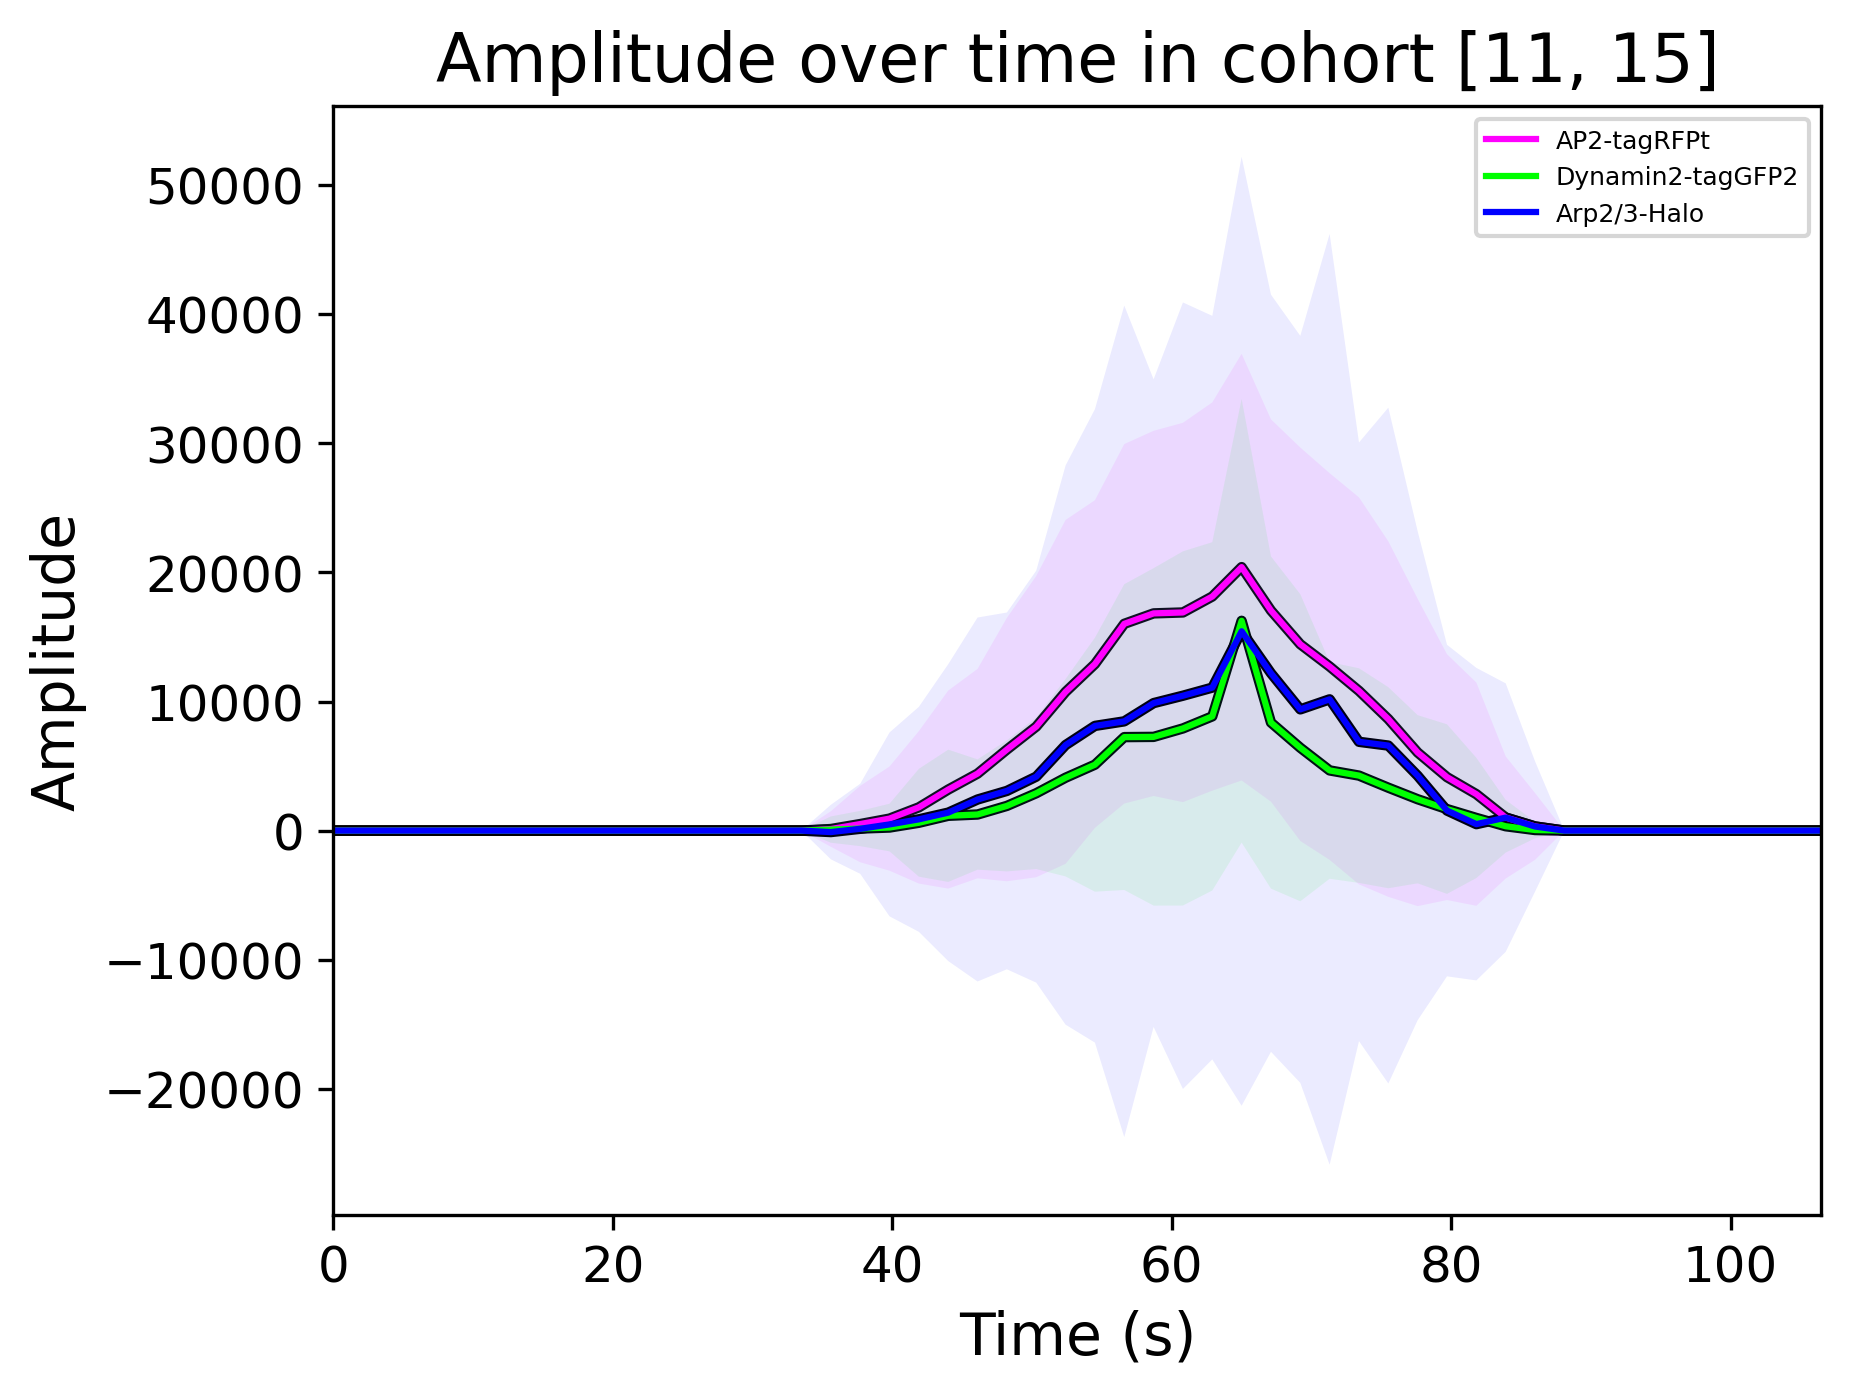

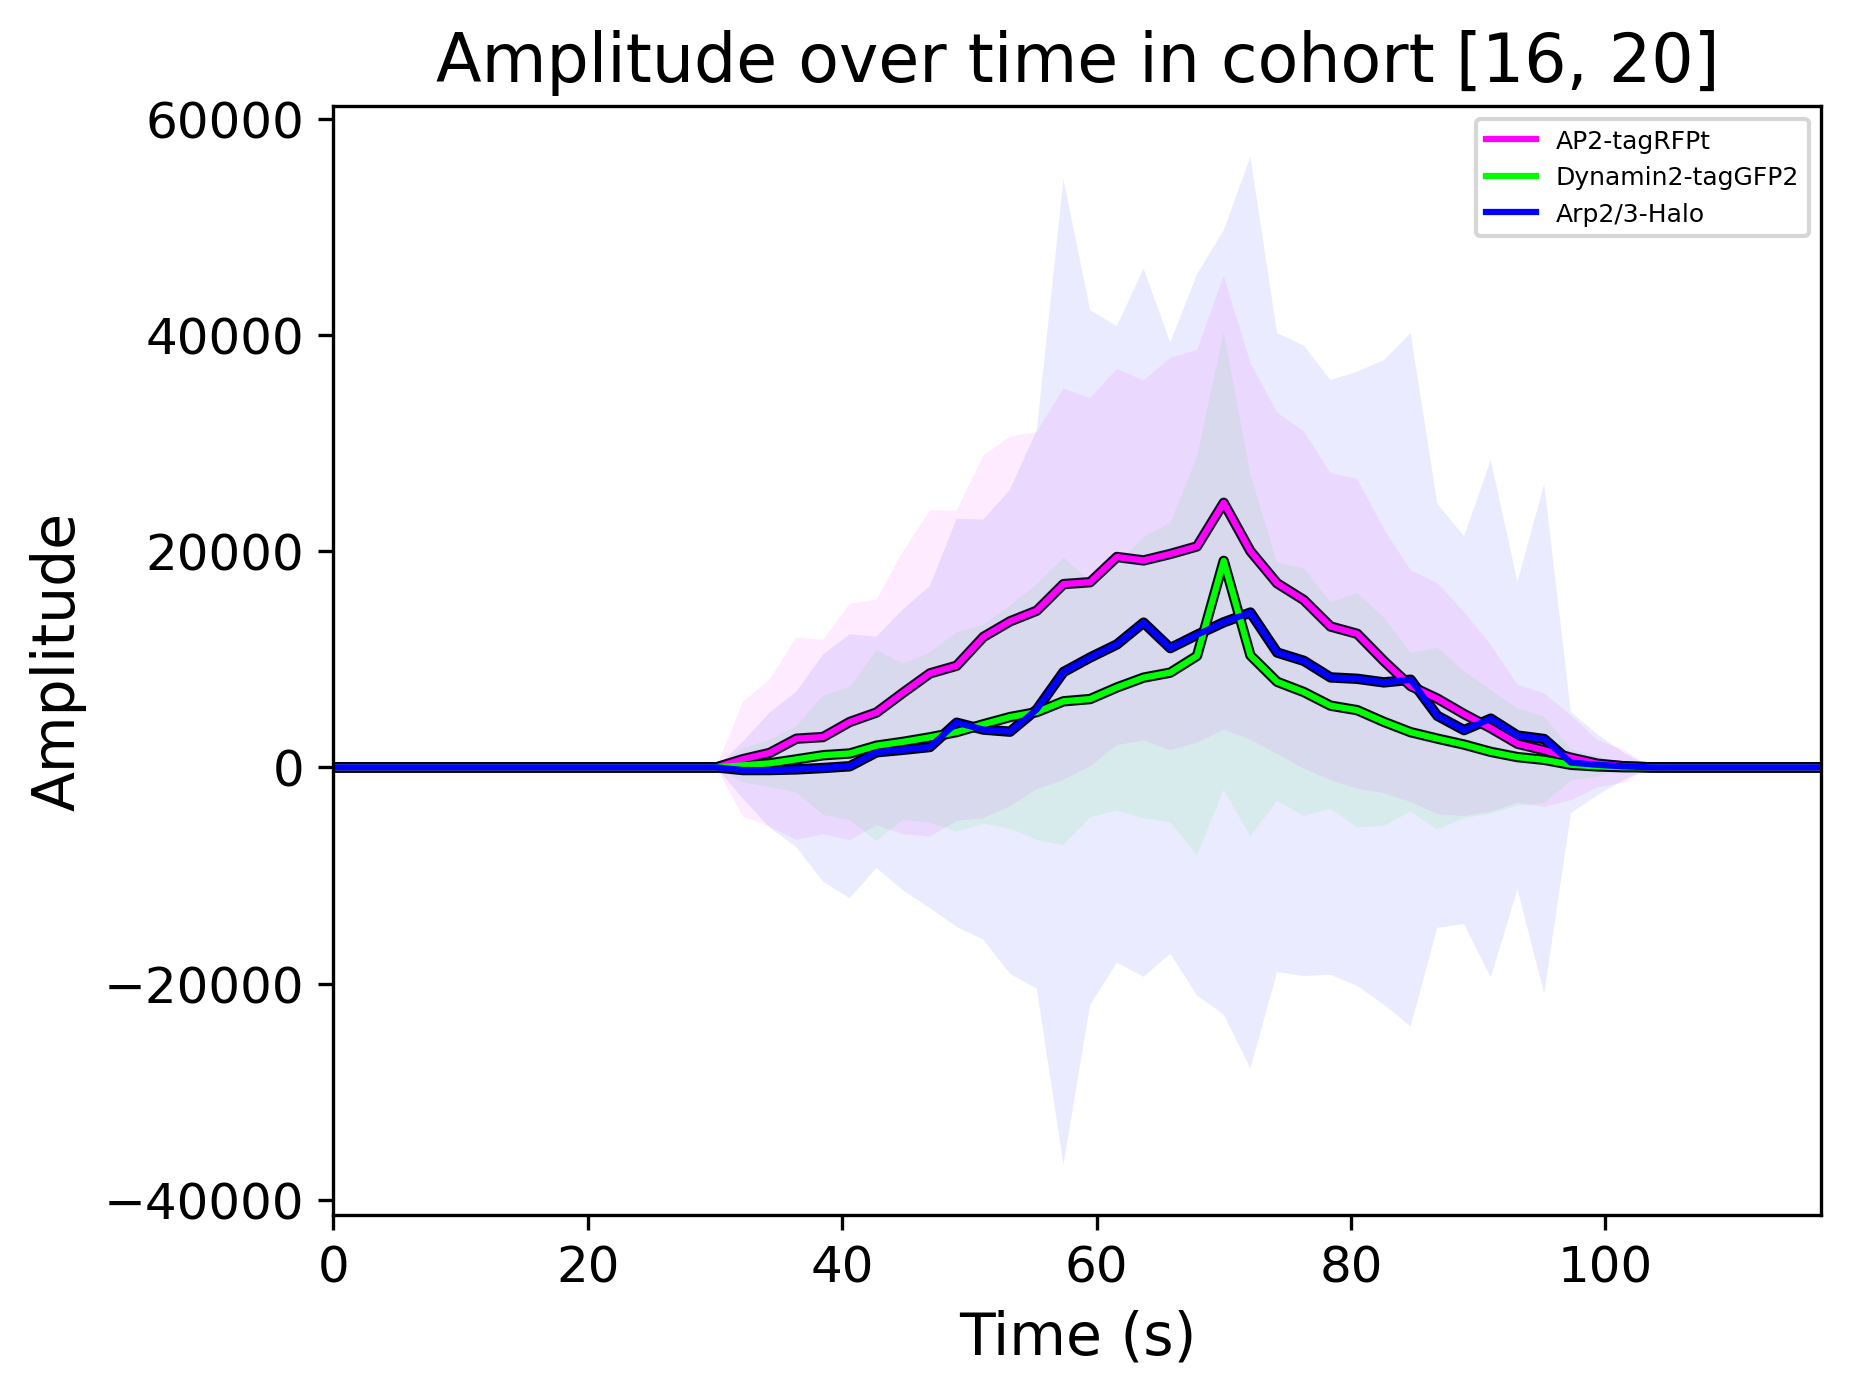

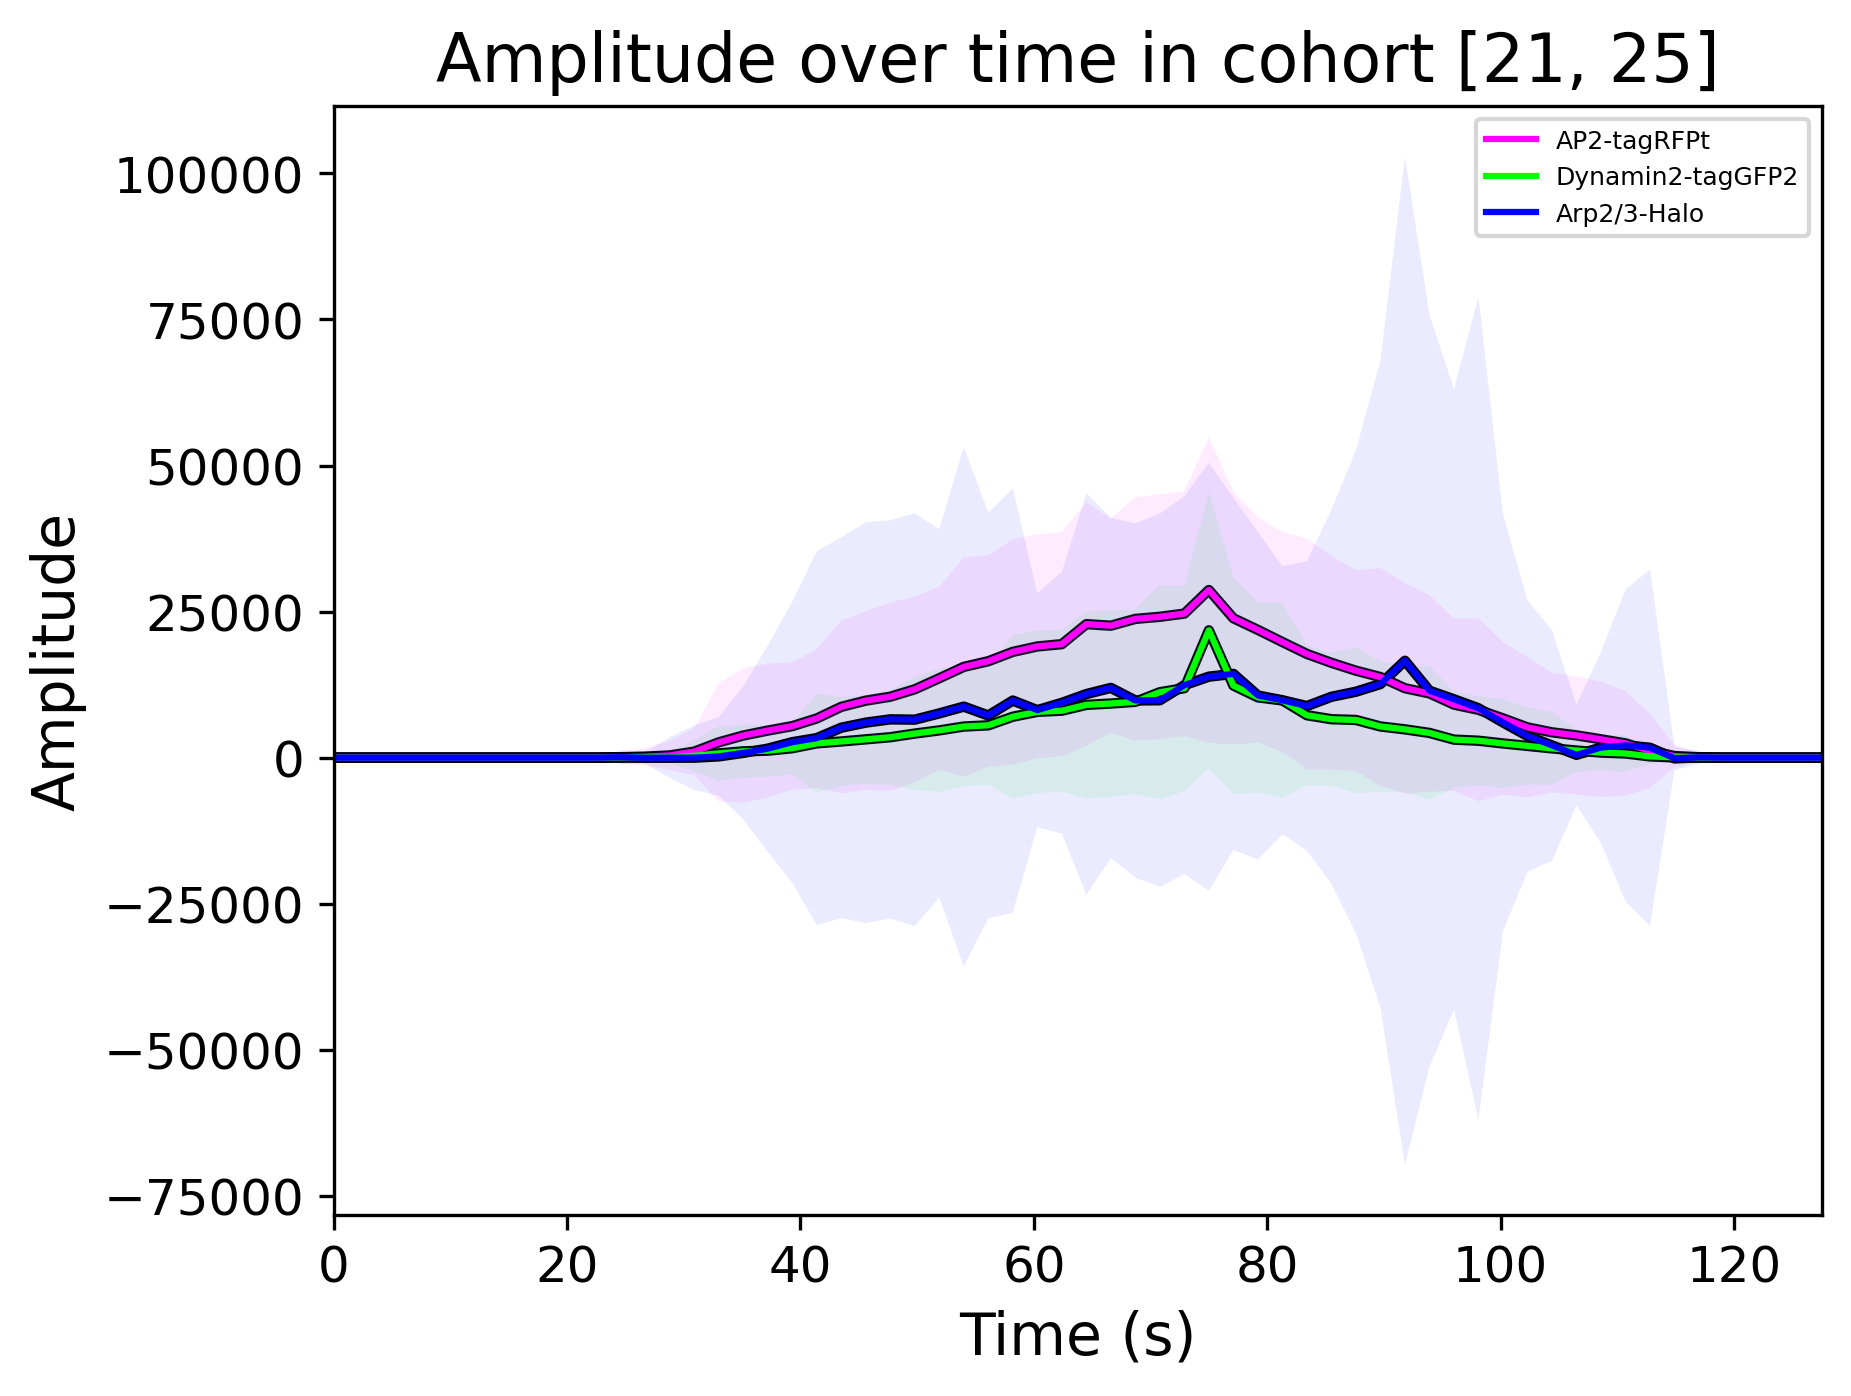

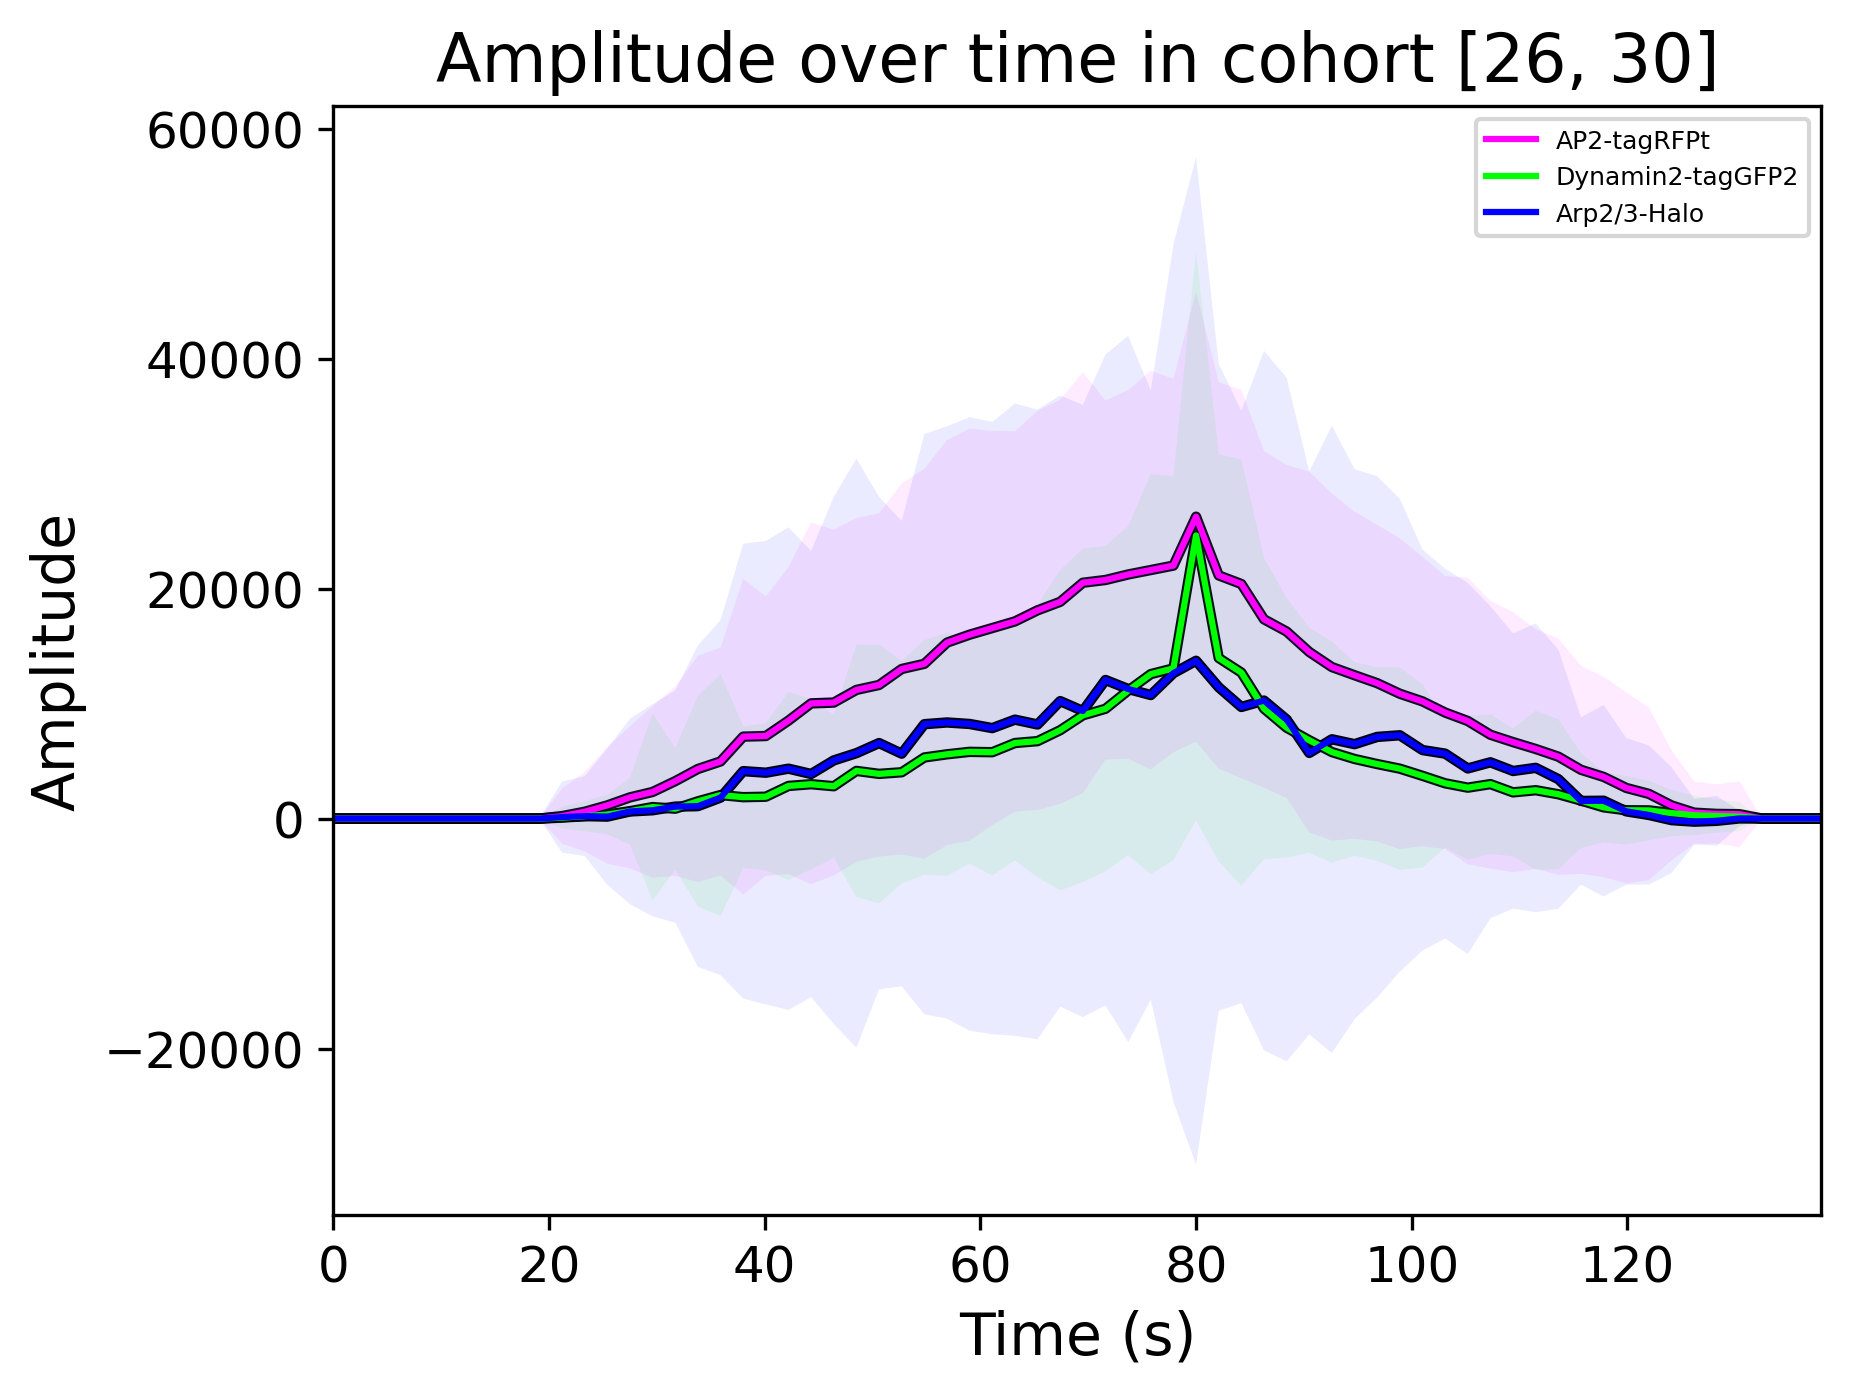

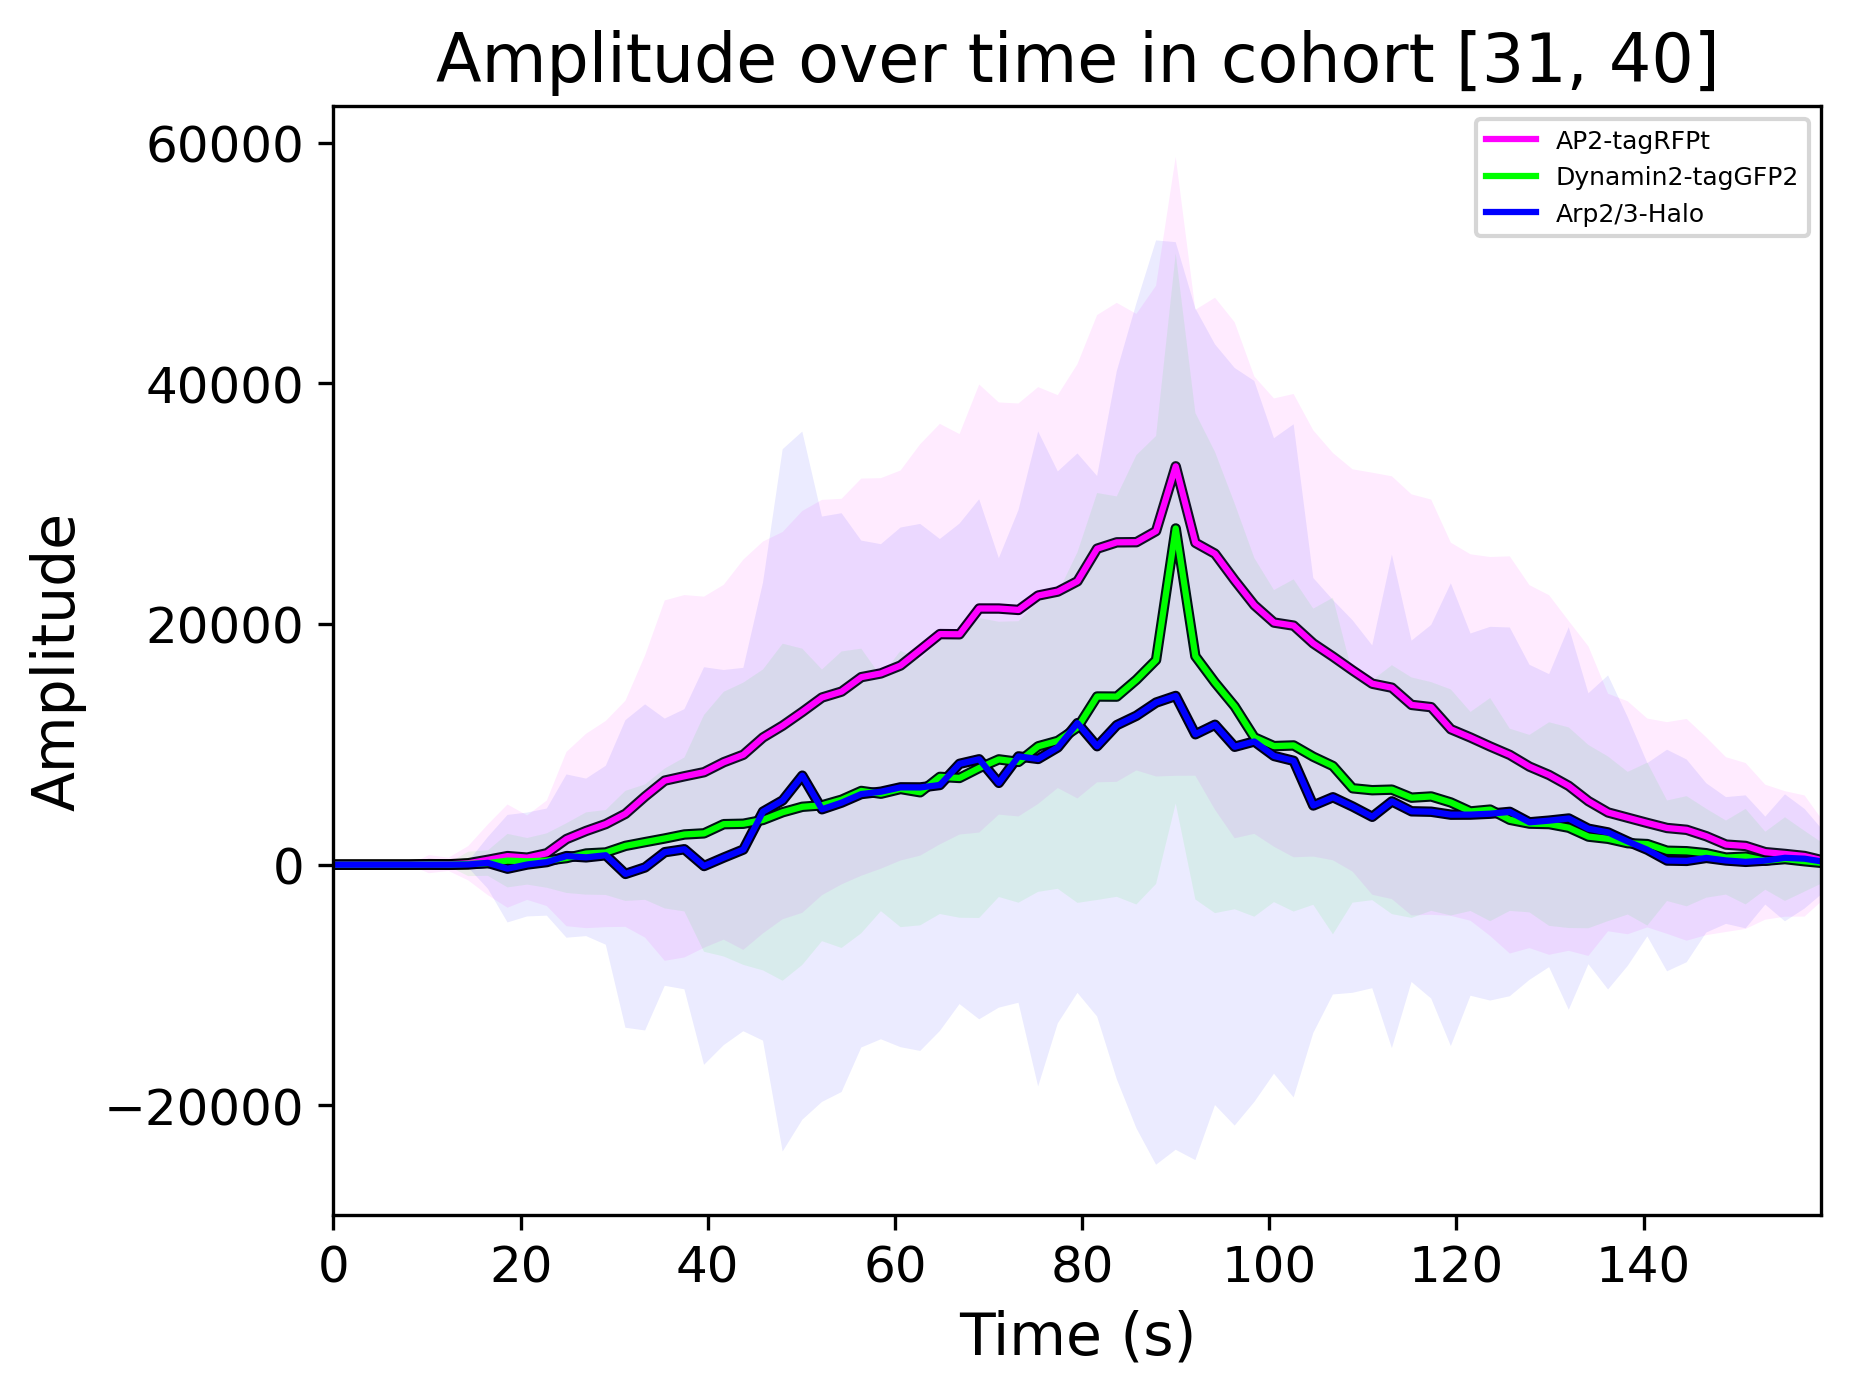

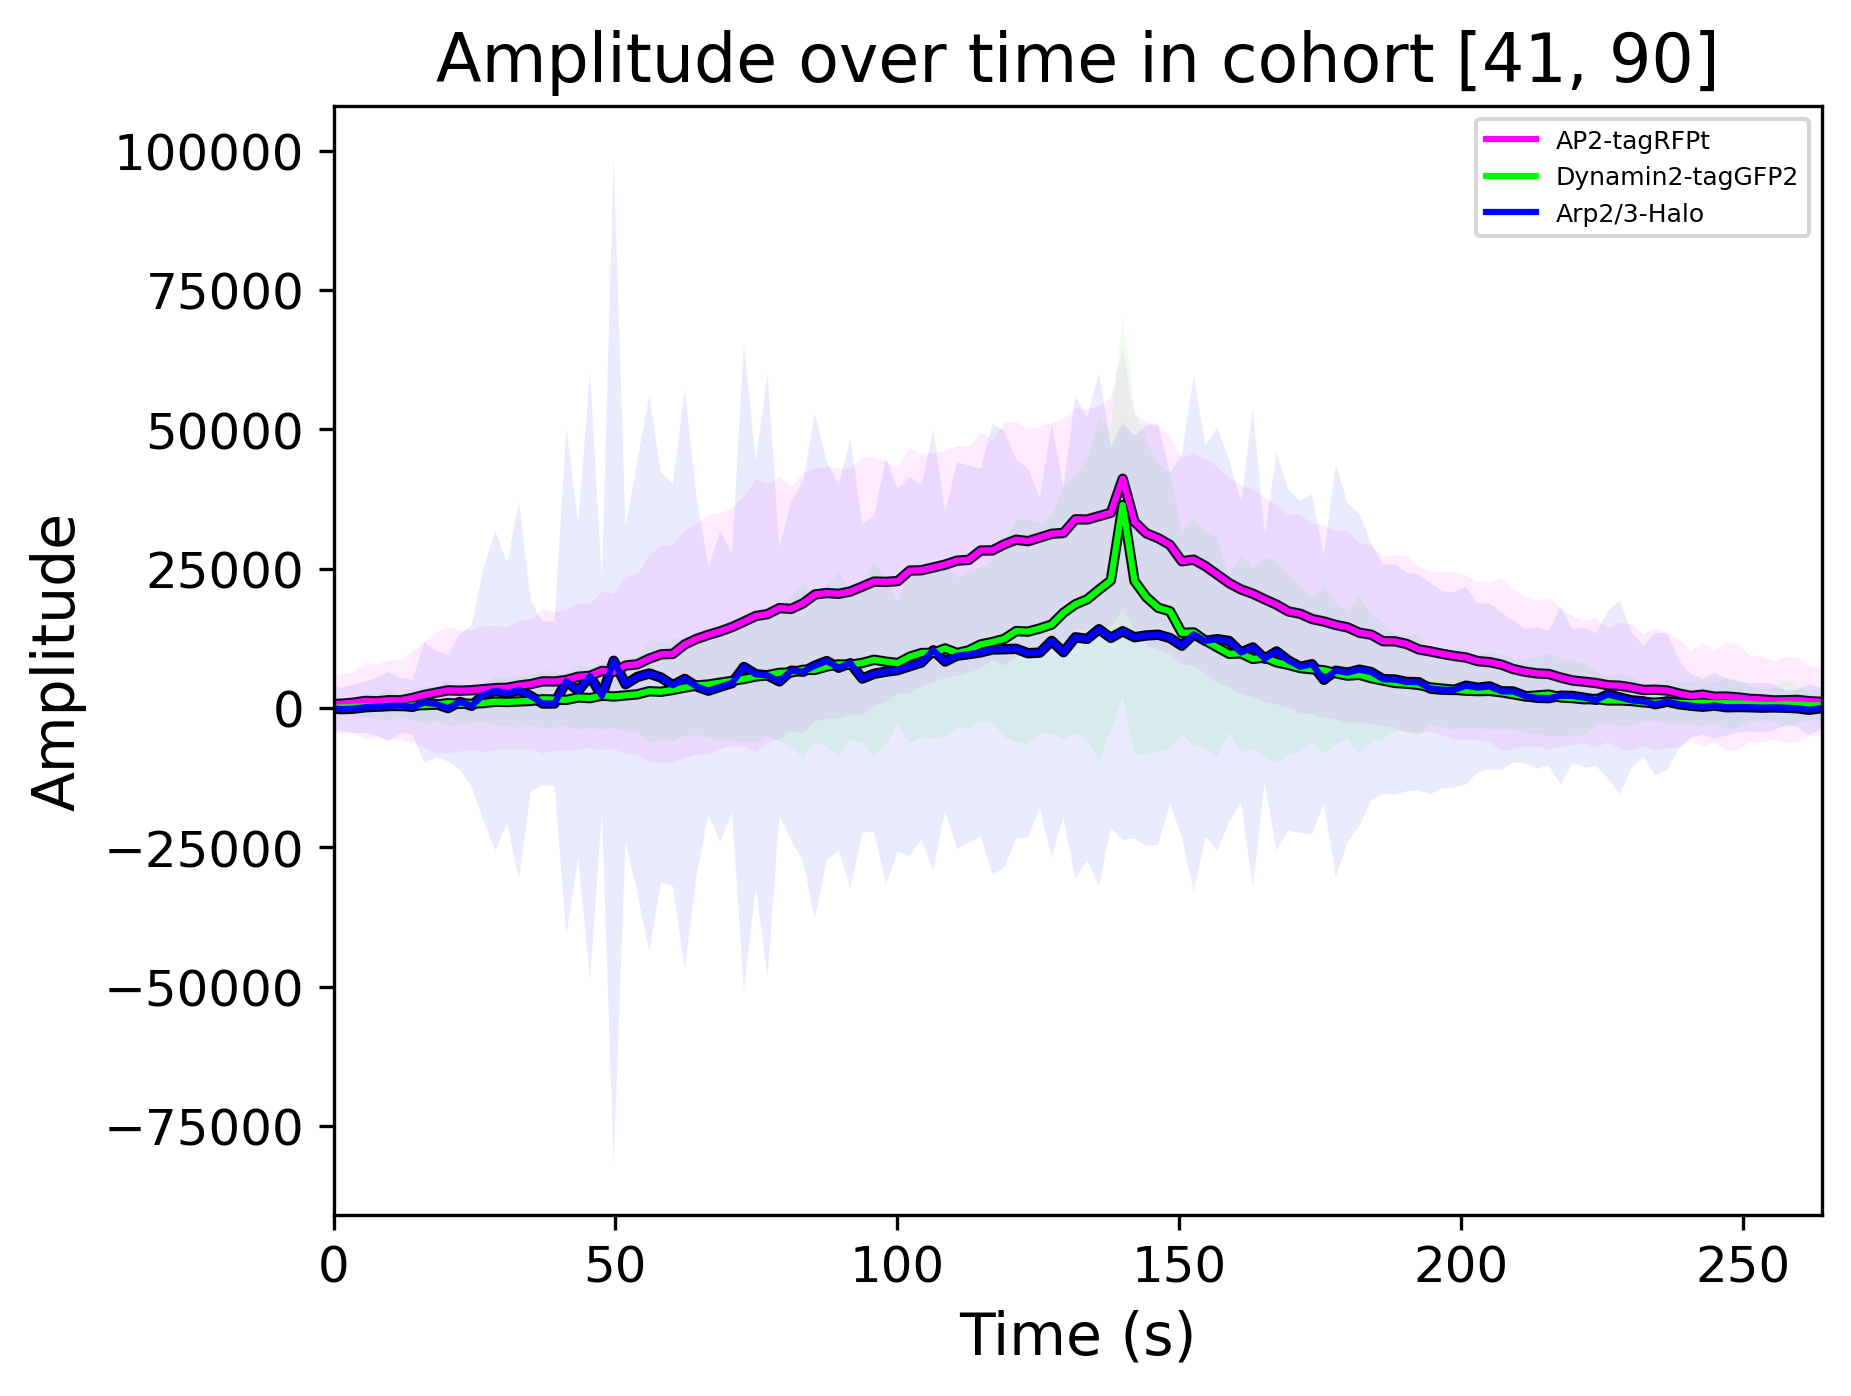

In [ ]:
lateral_tracks = trackFilter('Lateral', False, filtered_tracks_treatment)
track_id_arrays = filter_track_ids_by_length_ranges(dataframe = lateral_tracks, track_length_buckets = custom_length_ranges, 
                                 track_id_col_name = 'track_id', track_length_col_name = 'track_length')

print(f'number of tracks between [5,10] frames long are {len(track_id_arrays[0])}')
print(f'number of tracks between [11,15] frames long are {len(track_id_arrays[1])}')
print(f'number of tracks between [16,20] frames long are {len(track_id_arrays[2])}')
print(f'number of tracks between [21,25] frames long are {len(track_id_arrays[3])}')
print(f'number of tracks between [26,30] frames long are {len(track_id_arrays[4])}')
print(f'number of tracks between [31,40] frames long are {len(track_id_arrays[5])}')
print(f'number of tracks between [41,90] frames long are {len(track_id_arrays[6])}')
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0
    
cohort_intensity(intensity_track,track_id_arrays, lumenoid2_frame_ms, [background_channel_3, background_channel_2, background_channel_1], value_to_plot=value_to_plot)


#### Basal Intensity

number of tracks between [5,10] frames long are 83
number of tracks between [11,15] frames long are 126
number of tracks between [16,20] frames long are 101
number of tracks between [21,25] frames long are 82
number of tracks between [26,30] frames long are 60
number of tracks between [31,40] frames long are 98
number of tracks between [41,90] frames long are 100


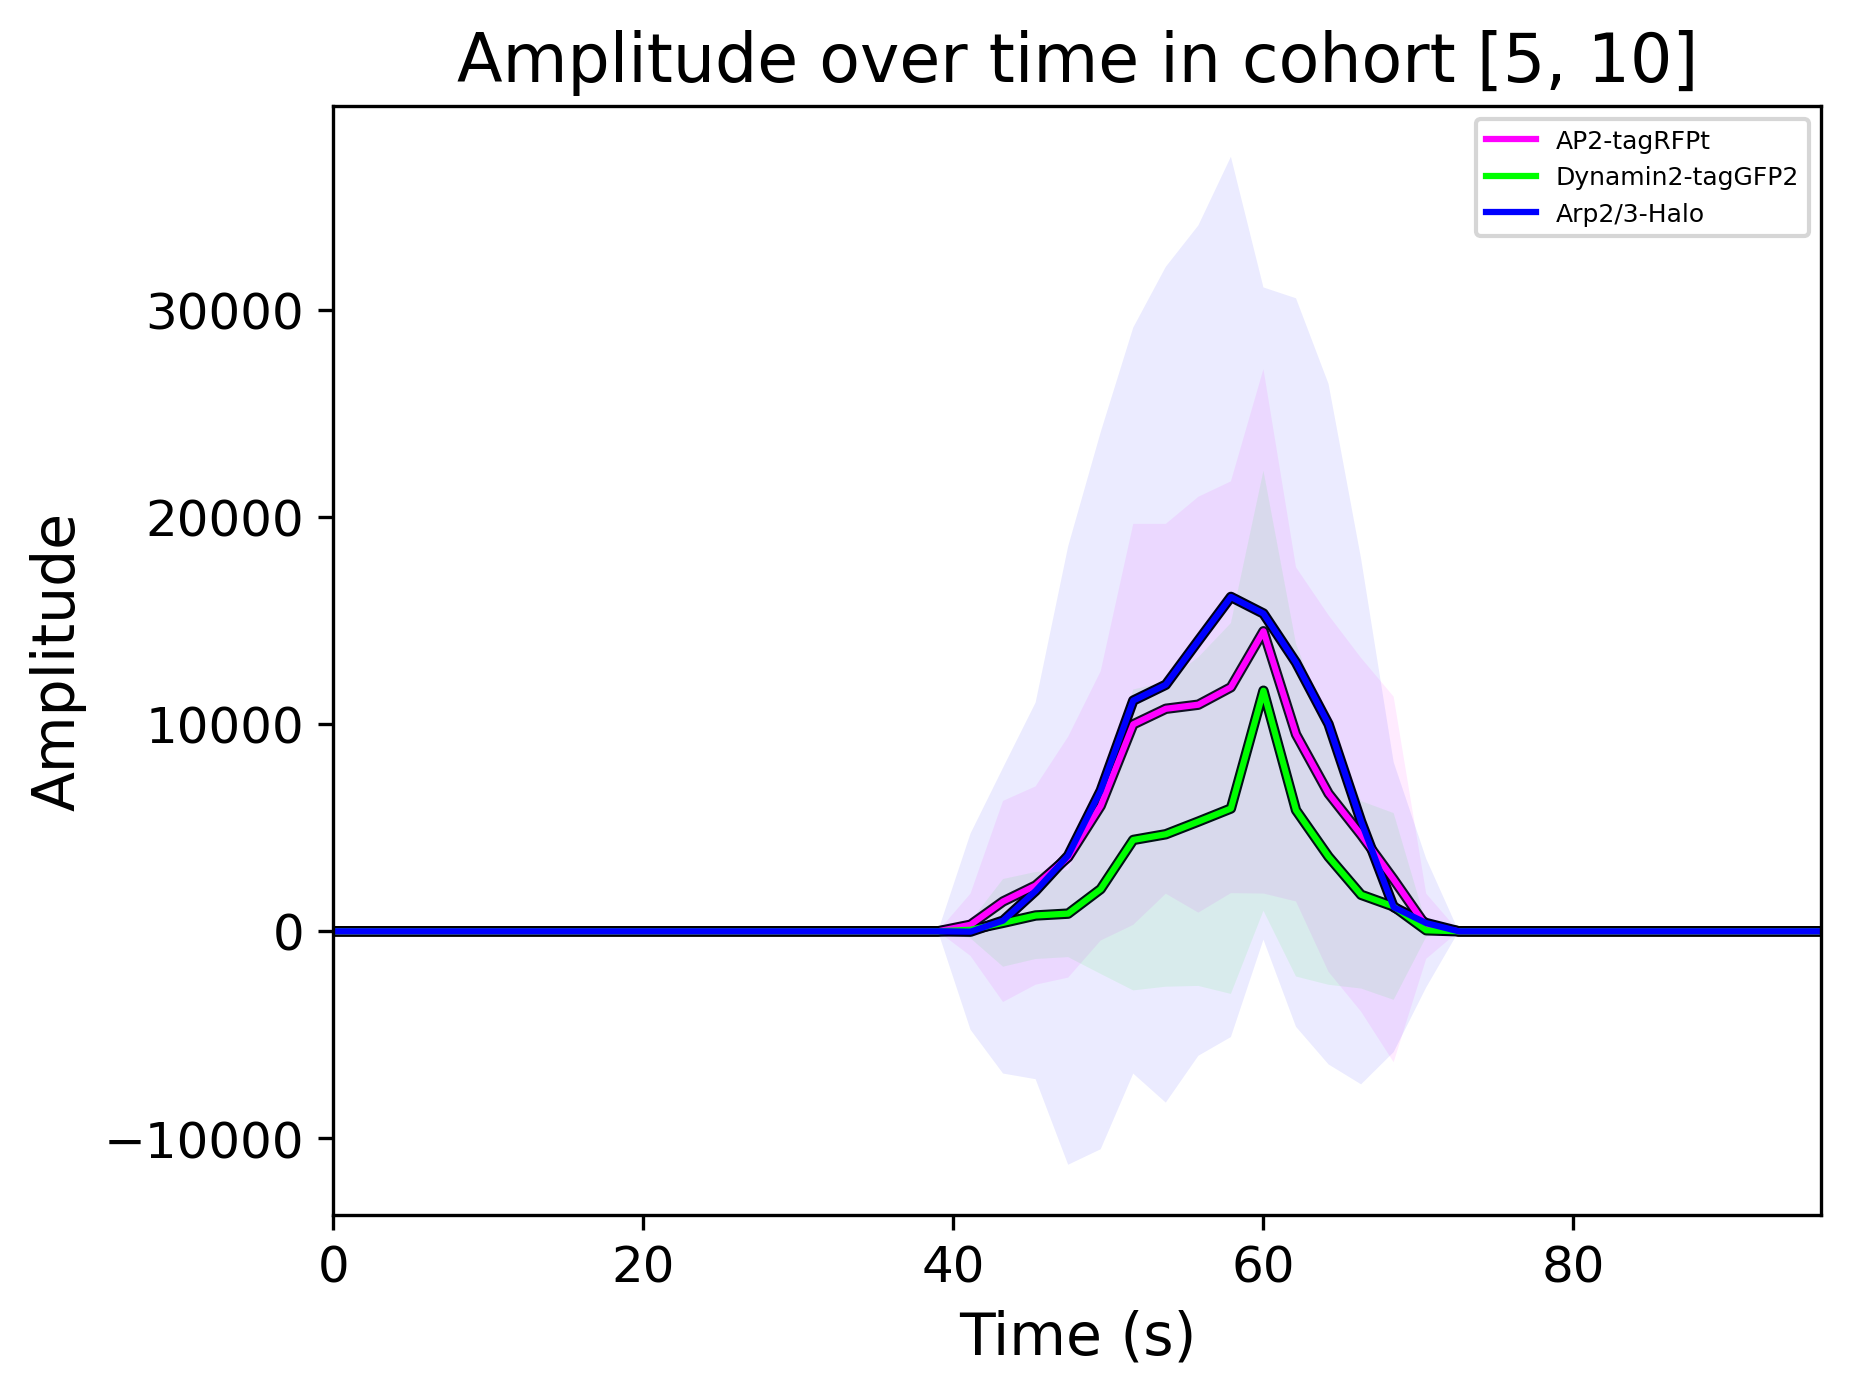

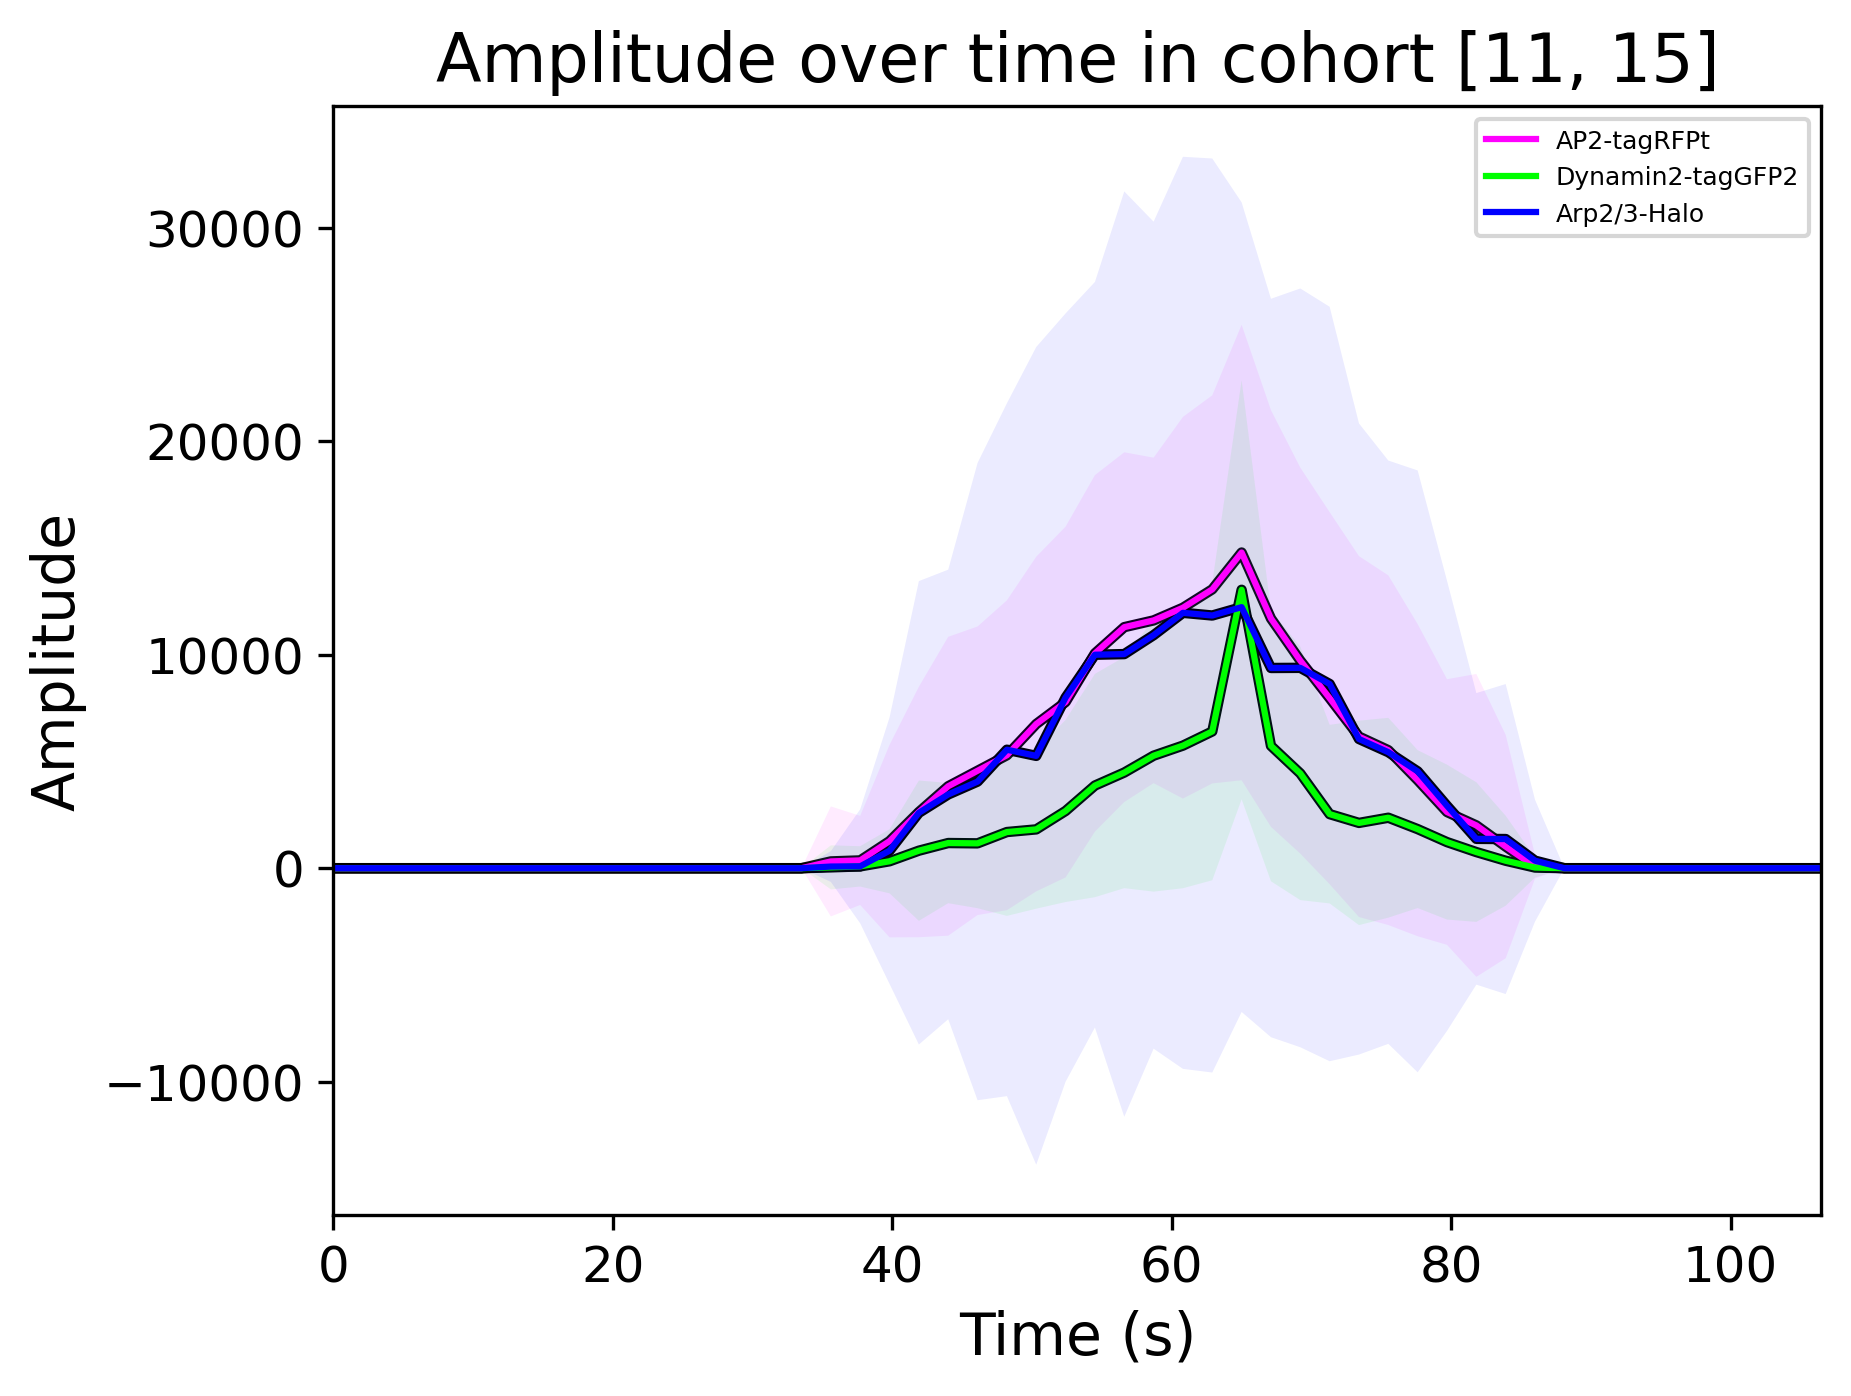

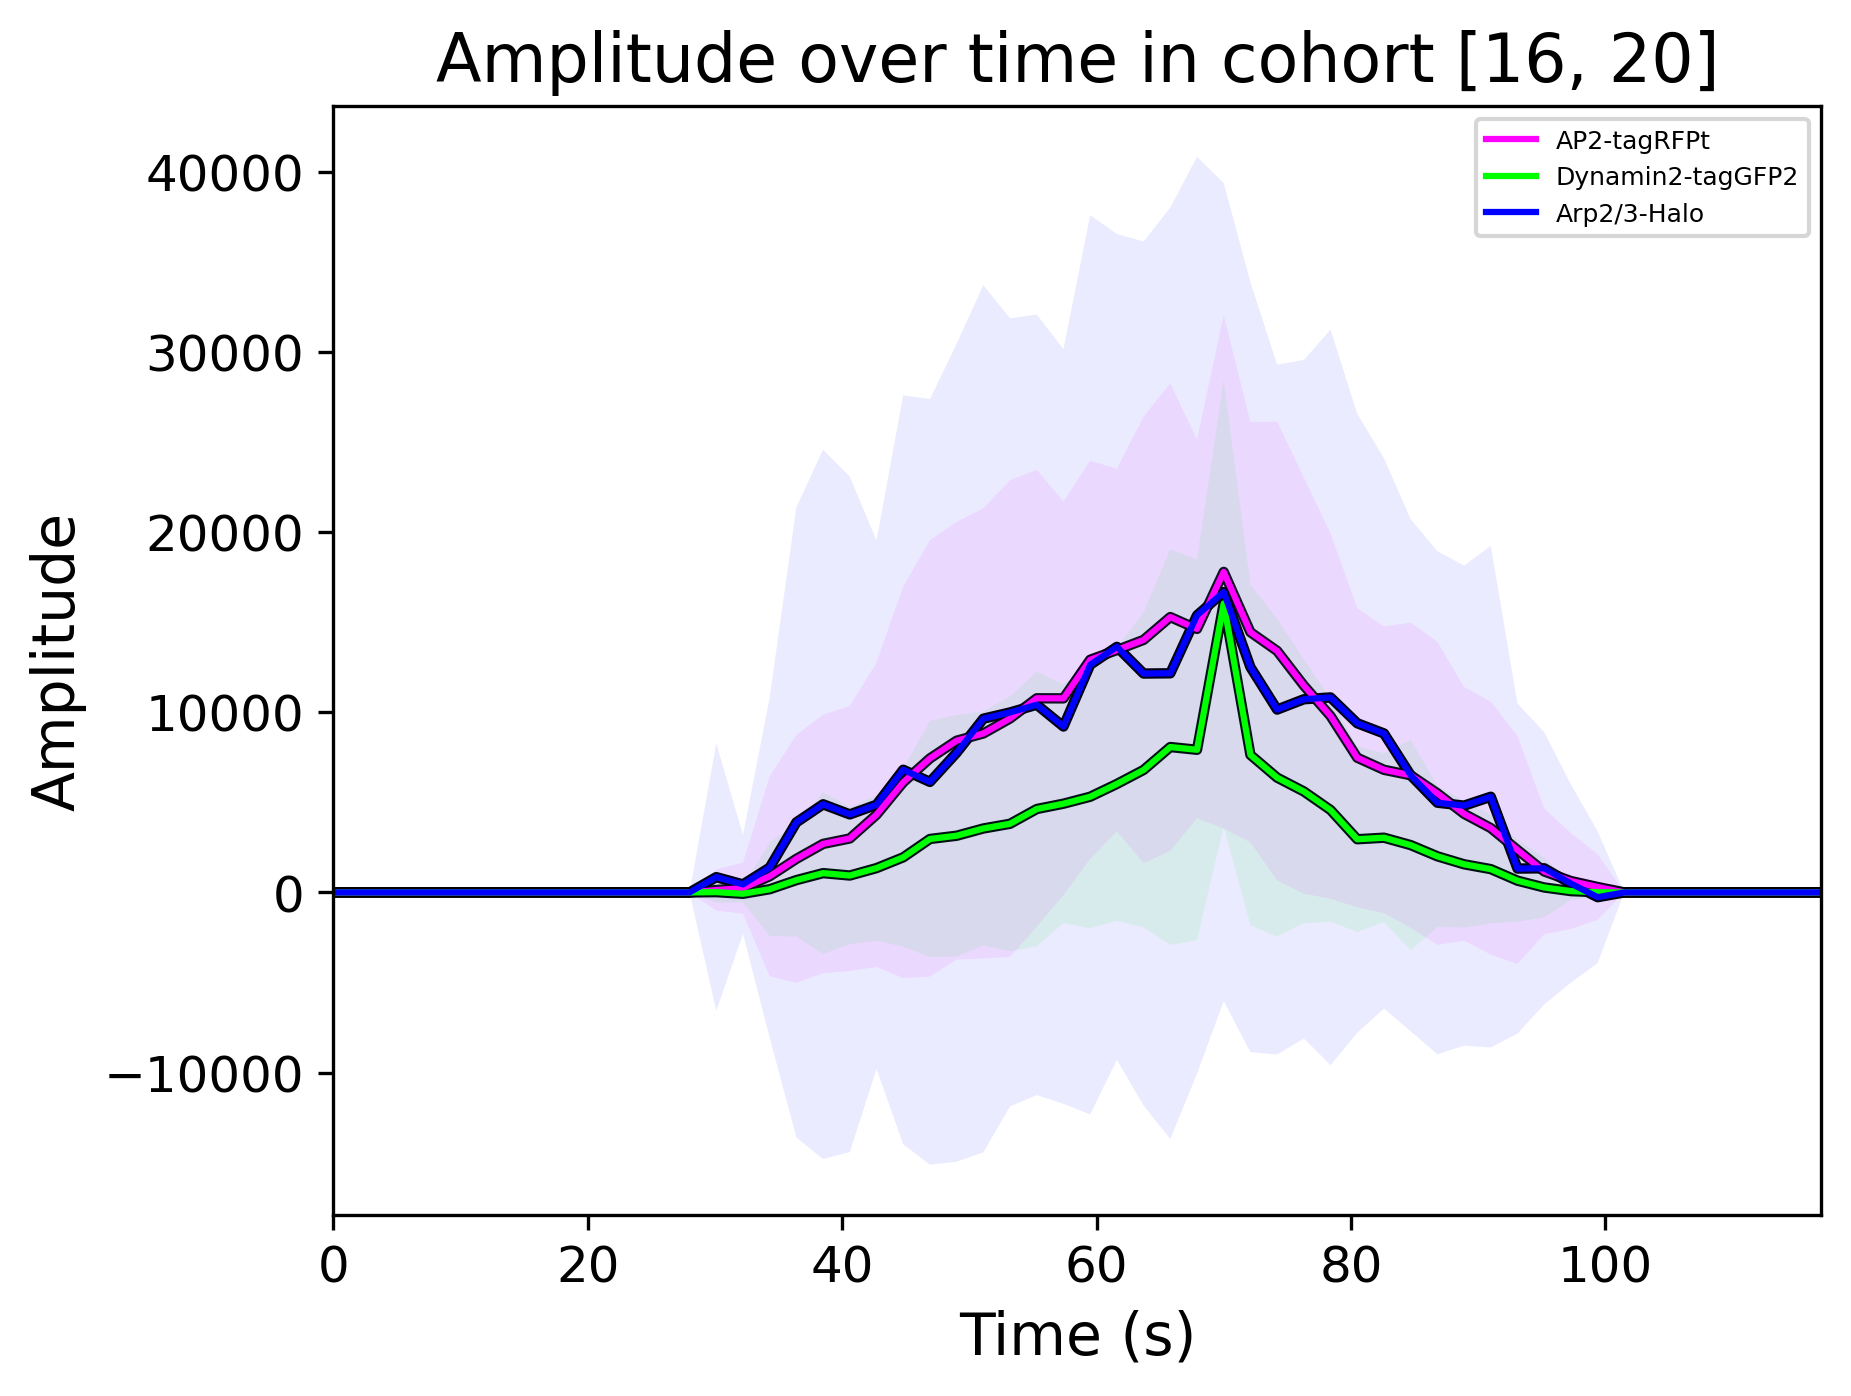

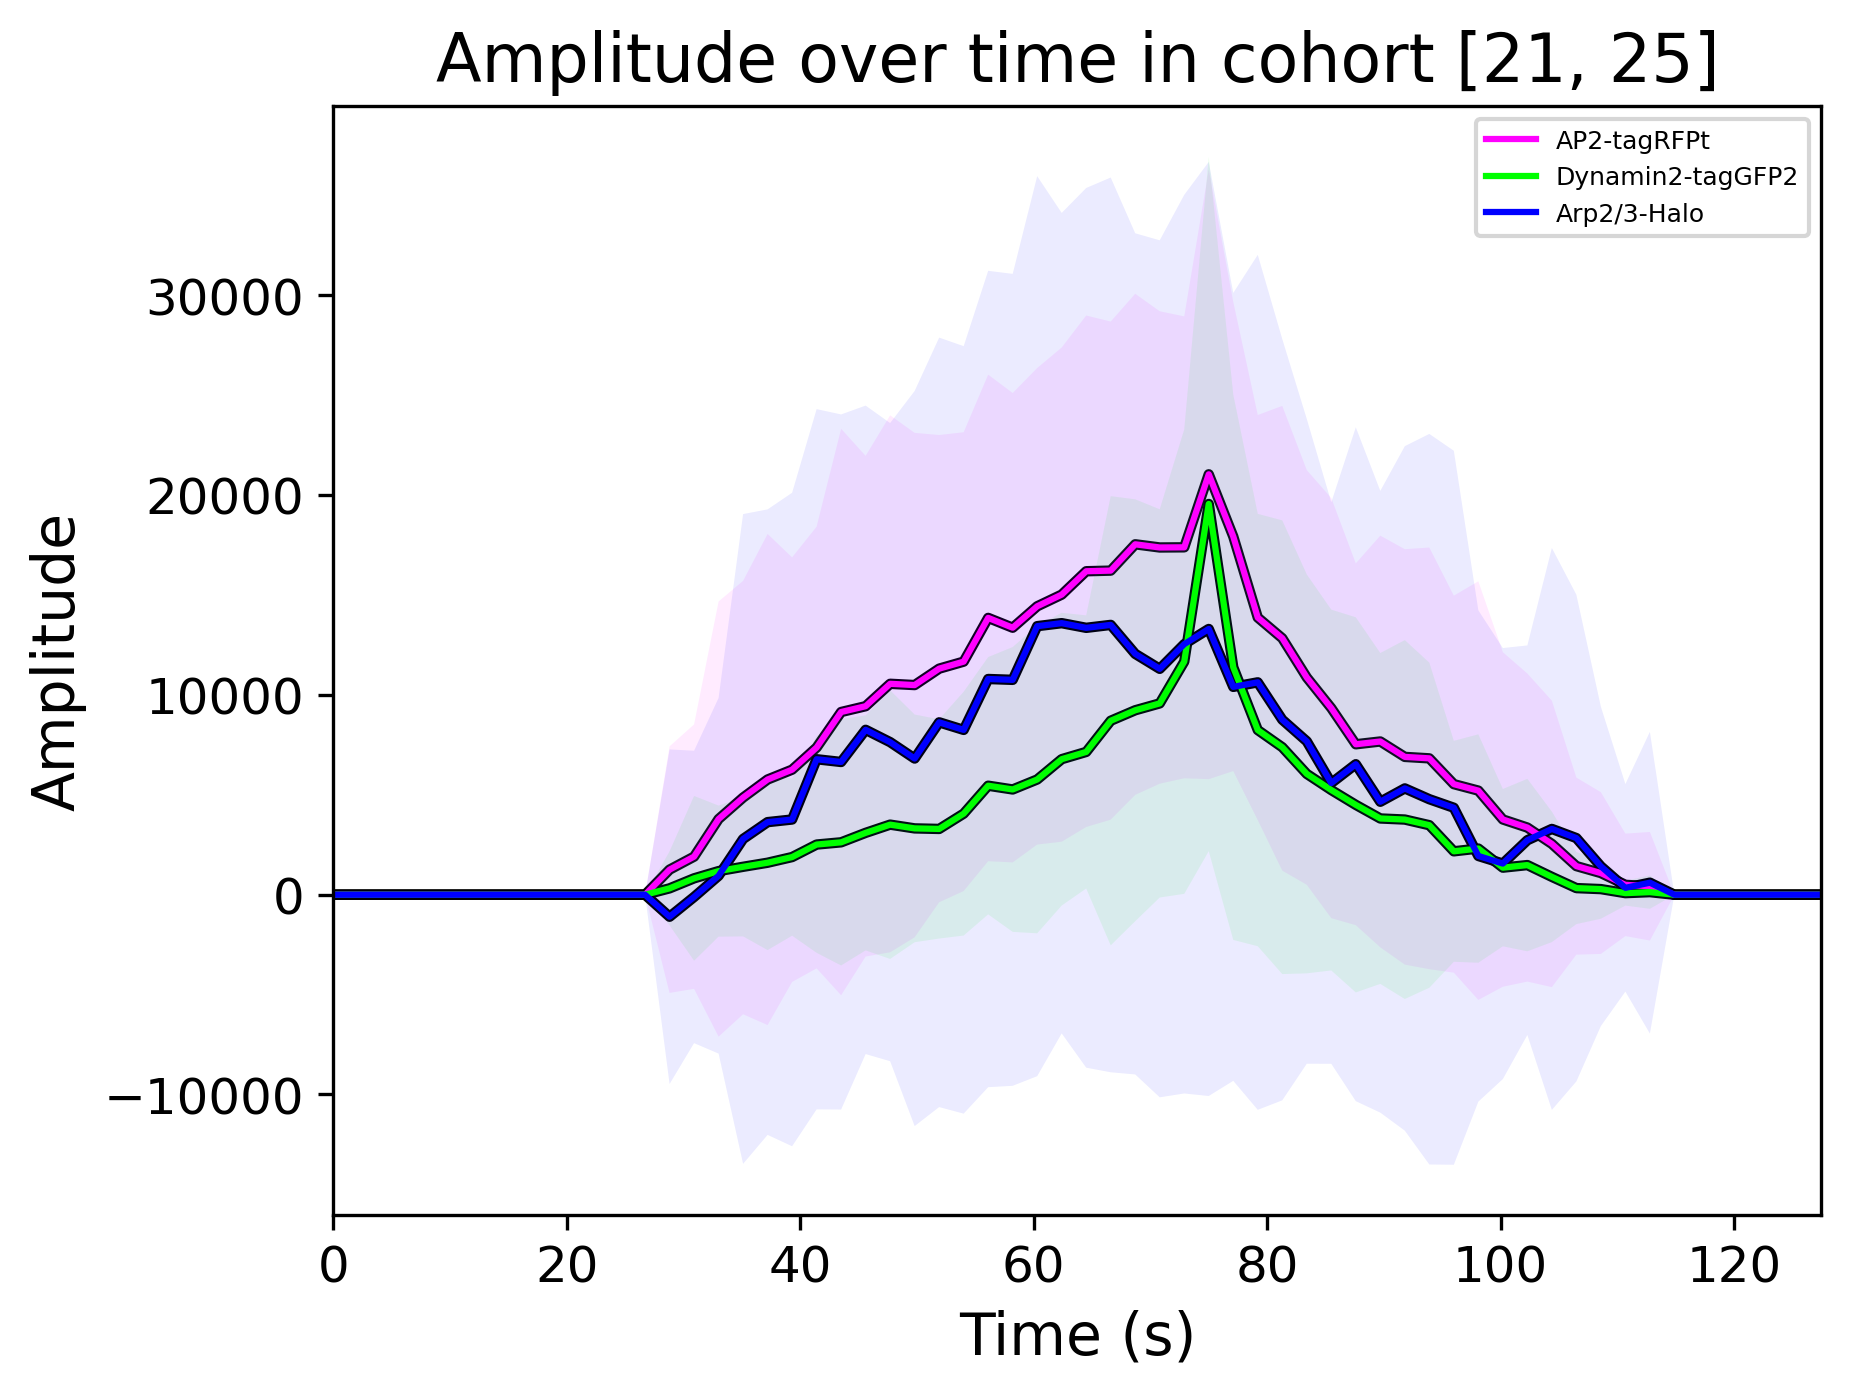

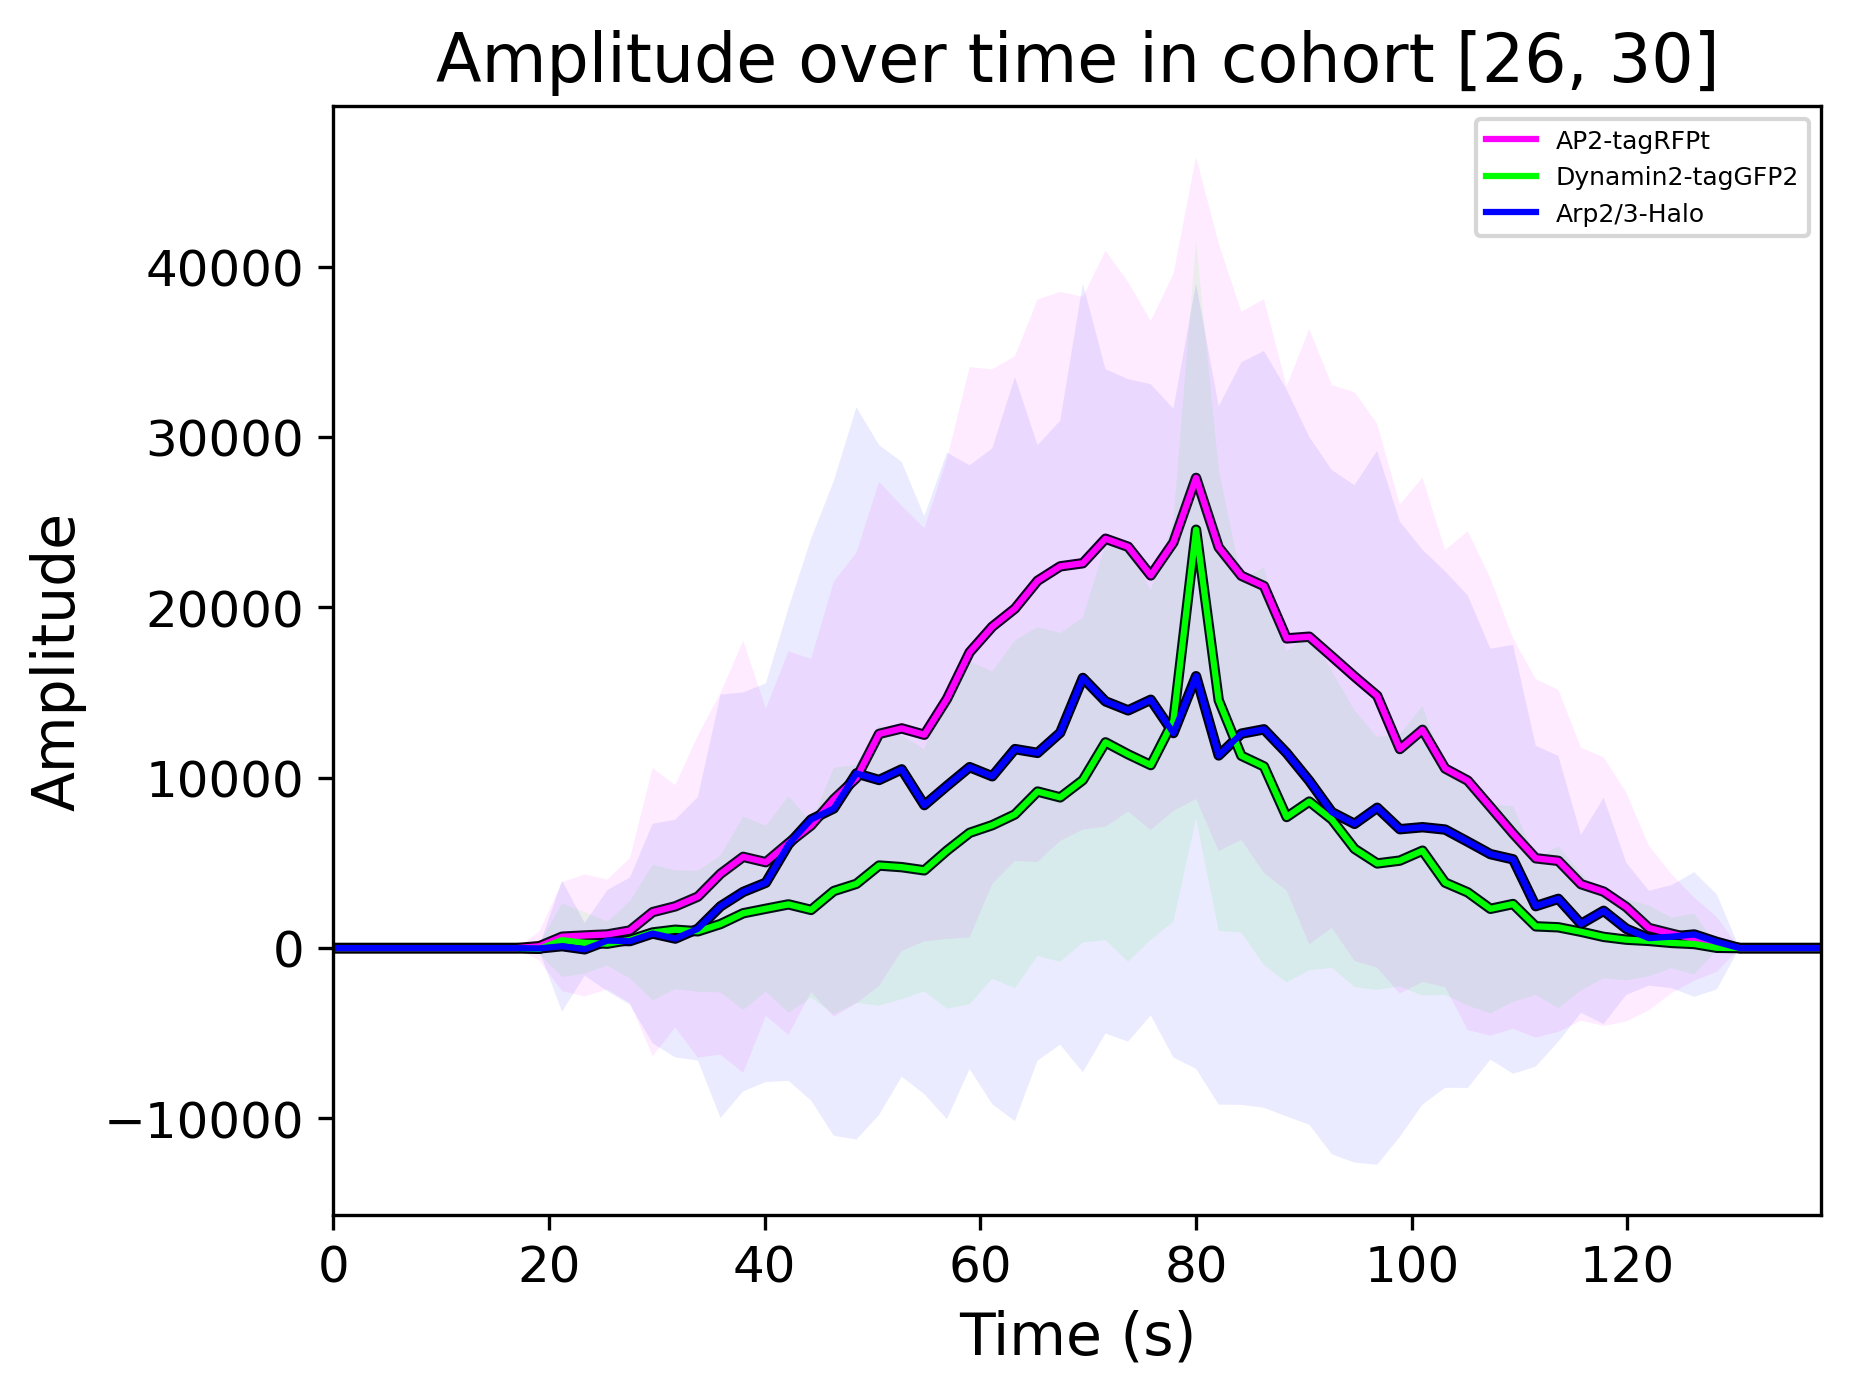

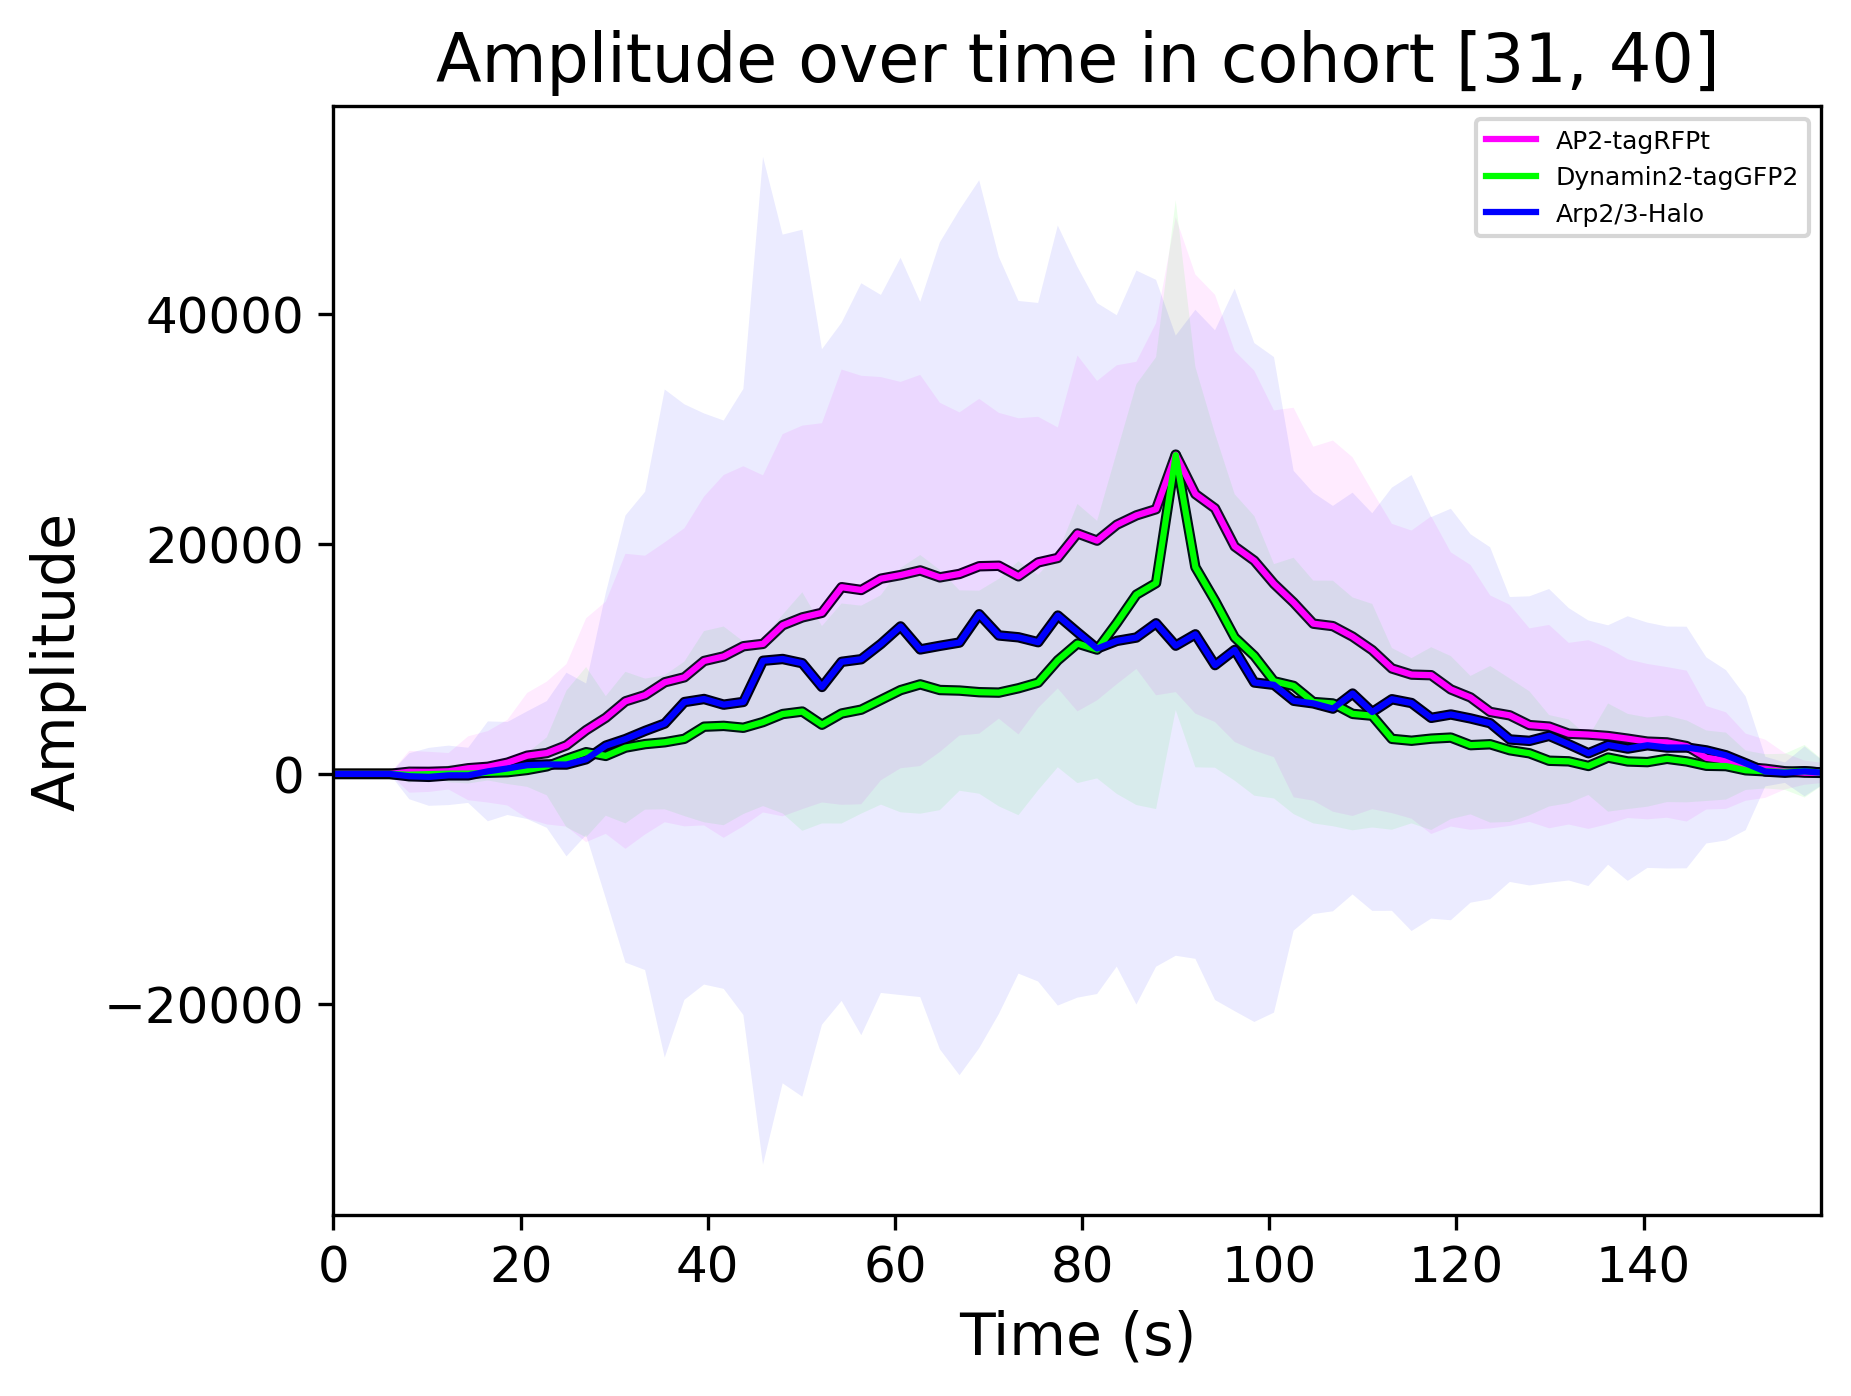

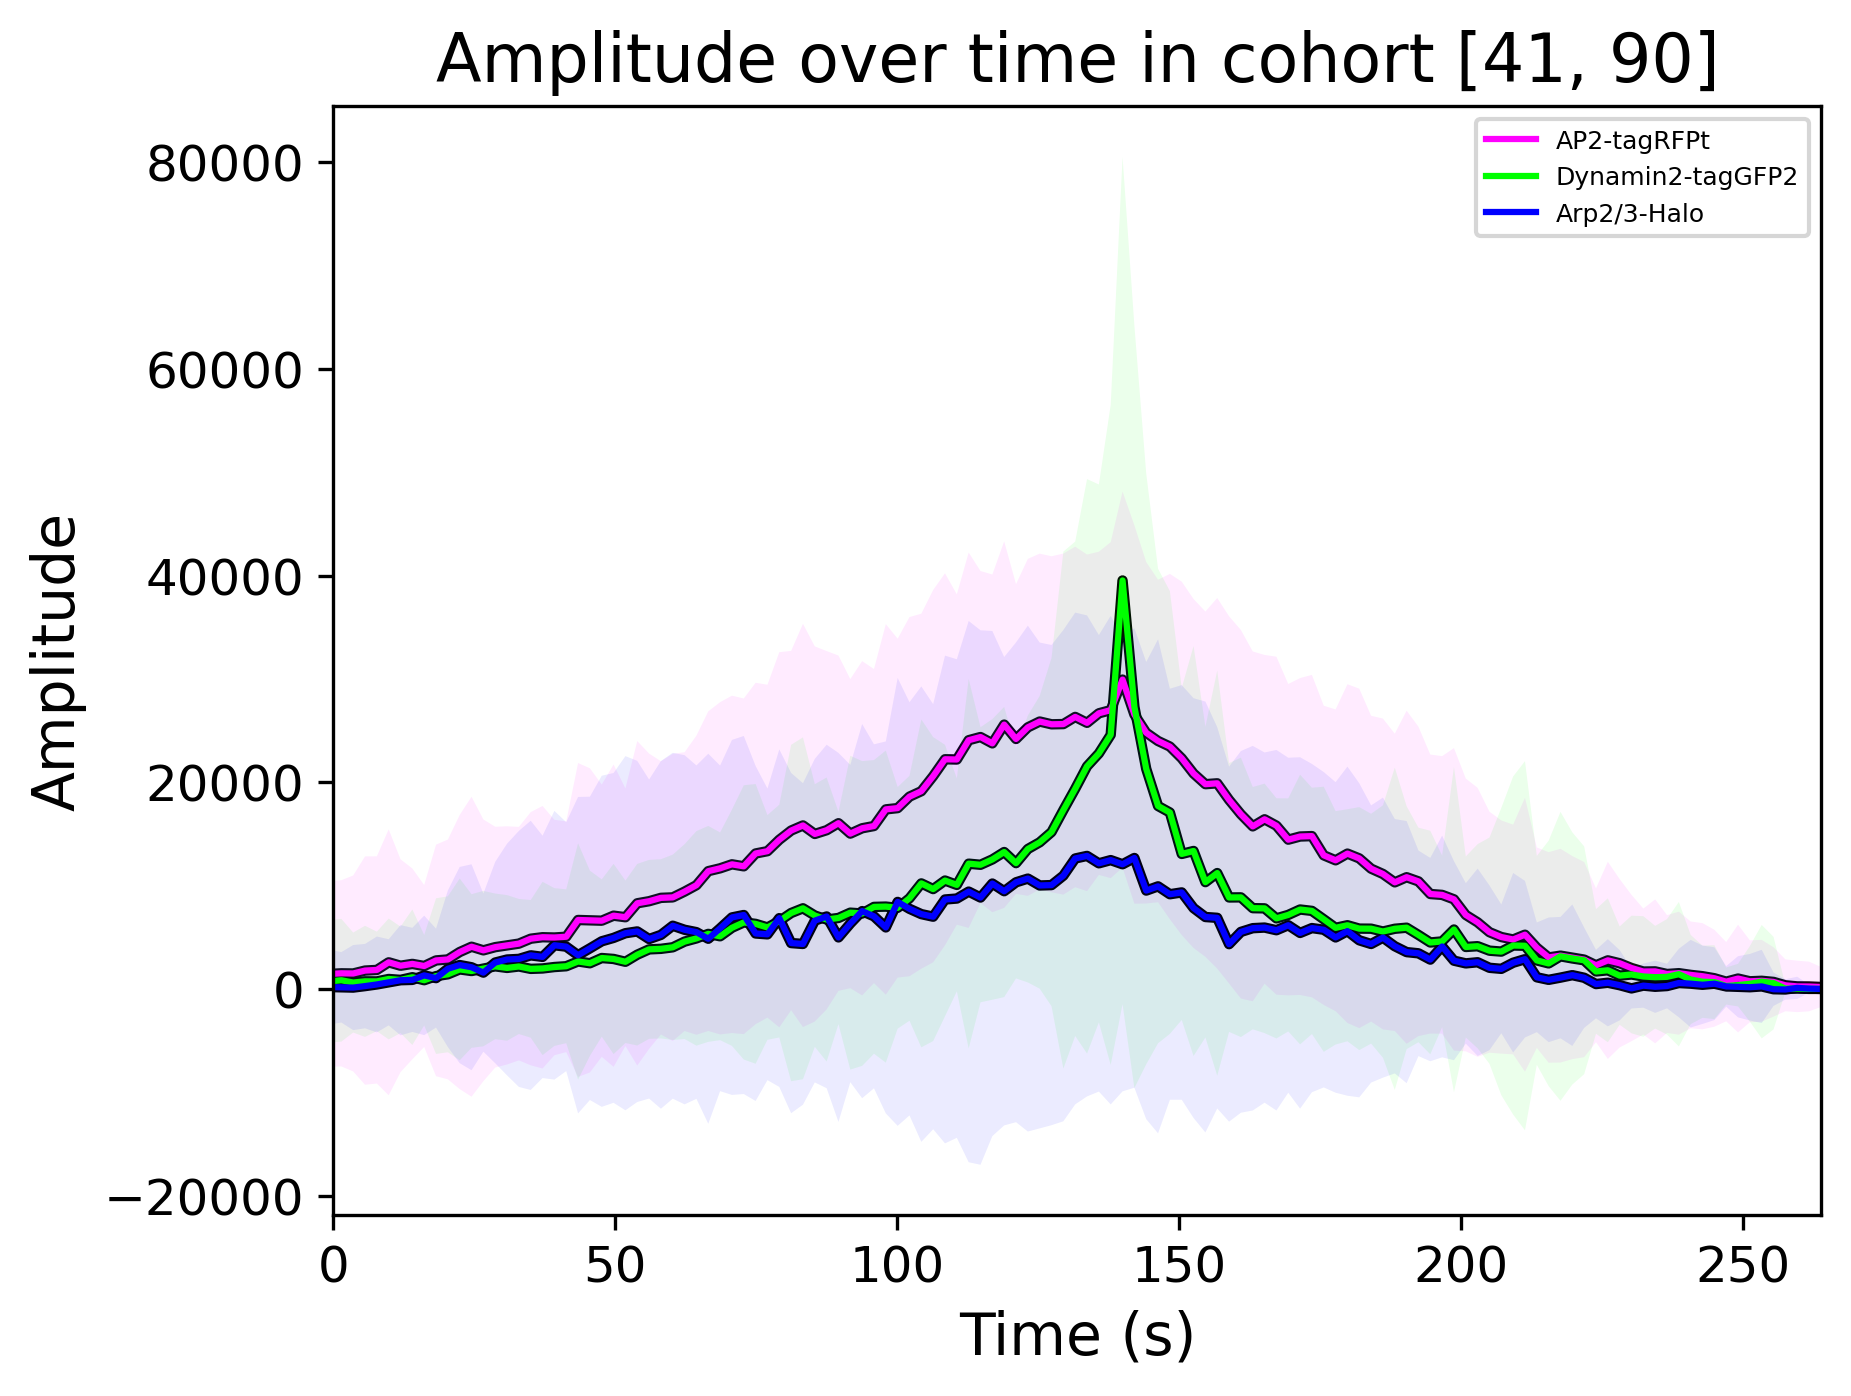

In [ ]:
basal_tracks = trackFilter('Basal', False, filtered_tracks_treatment)
track_id_arrays = filter_track_ids_by_length_ranges(dataframe = basal_tracks, track_length_buckets = custom_length_ranges, 
                                 track_id_col_name = 'track_id', track_length_col_name = 'track_length')

print(f'number of tracks between [5,10] frames long are {len(track_id_arrays[0])}')
print(f'number of tracks between [11,15] frames long are {len(track_id_arrays[1])}')
print(f'number of tracks between [16,20] frames long are {len(track_id_arrays[2])}')
print(f'number of tracks between [21,25] frames long are {len(track_id_arrays[3])}')
print(f'number of tracks between [26,30] frames long are {len(track_id_arrays[4])}')
print(f'number of tracks between [31,40] frames long are {len(track_id_arrays[5])}')
print(f'number of tracks between [41,90] frames long are {len(track_id_arrays[6])}')
value_to_plot = 'voxel_sum_adjusted'
# value_to_plot = 'voxel_sum'
# value_to_plot = 'peak_mean'
# value_to_plot = 'peak_max'

if value_to_plot == 'voxel_sum_adjusted':
    background_channel_1 = 0
    background_channel_2 = 0
    background_channel_3 = 0
    
cohort_intensity(intensity_track,track_id_arrays, lumenoid2_frame_ms, [background_channel_3, background_channel_2, background_channel_1], value_to_plot=value_to_plot)


## CCS Growth Distribution Lumenoid 2 Testing

In [43]:
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
ccs_track_df = pd.read_pickle(input_directory_all_tracks_full)
ccs_track_df.head()

,frame,mu_x,mu_y,mu_z,amplitude,track_id,segment_id,sigma_z,sigma_y,sigma_x,...,c2_vol_bg,c3_peak_mean,c3_peak_max,c3_voxel_sum,c3_voxel_sum_adjusted,c3_peak_x,c3_peak_y,c3_peak_z,c3_vol_sig,c3_vol_bg
0,0,126.0,523.0,34.0,533.0,2213,NaN,3,2,2,...,441,262.274286,556,45898,20724.315789,125,523,32,175,441
1,0,159.0,422.0,37.0,17.0,2212,NaN,3,2,2,...,441,6.511494,22,1133,268.909434,157,422,35,174,439
2,0,98.0,483.0,38.0,372.0,2222,NaN,3,2,2,...,441,168.908571,530,29559,2851.105263,99,485,41,175,441
3,0,90.0,533.0,38.0,36.0,2221,NaN,3,2,2,...,437,4.891566,36,812,288.160377,89,532,37,166,378
4,0,85.0,352.0,37.0,1199.0,2220,NaN,3,2,2,...,441,407.440000,1199,71302,32061.210526,85,351,36,175,441


tracks_to_plot 0


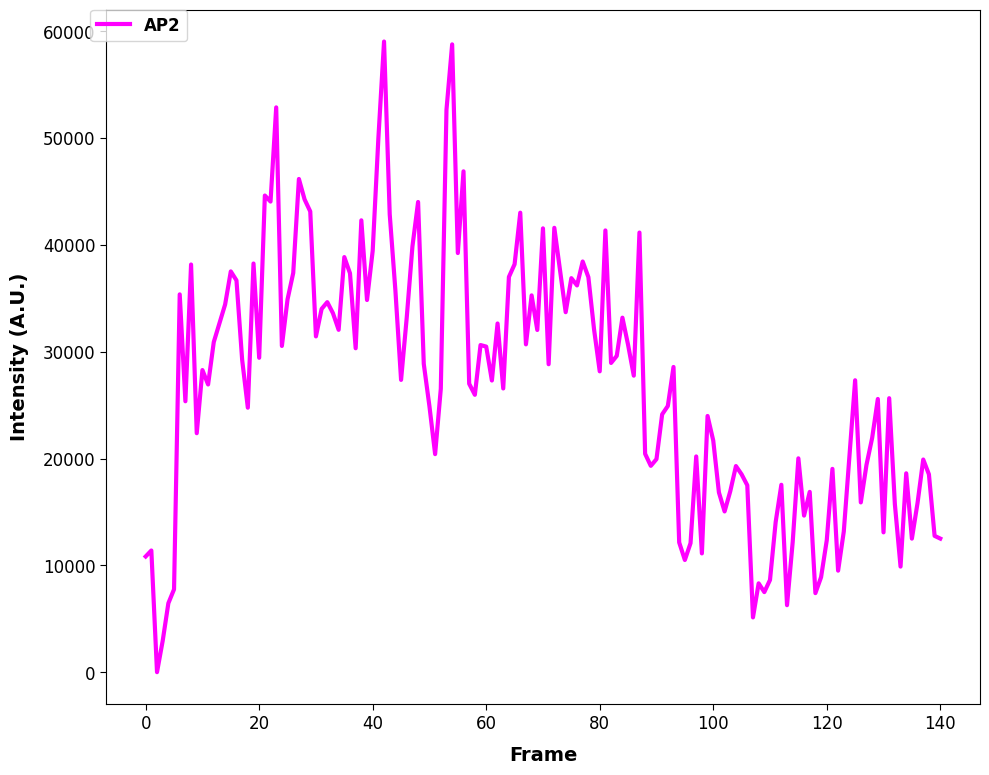

In [48]:
value_to_plot = 'voxel_sum_adjusted'
channel3_name = 'AP2'
channel2_name = 'Dynamin2'
channel1_name = 'ArpC3'

# set 'normalized = False' to plot raw intensities
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
track_df = pd.read_pickle(input_directory_all_tracks_full)
intensity_time_plot_onetrack(dataframe = track_df, tracks_to_plot = 0, 
intensity_to_plot = [f'c3_{value_to_plot}'], track_id_col_name = 'track_id', 
frame_col_name = 'frame', channels_to_plot = 1, legend_values = [channel3_name],
line_colors = ['magenta'], graph_title = f'{value_to_plot}', normalized=False, save_plot = False)

Processing tracks:   0%|          | 0/67768 [00:00<?, ?it/s]

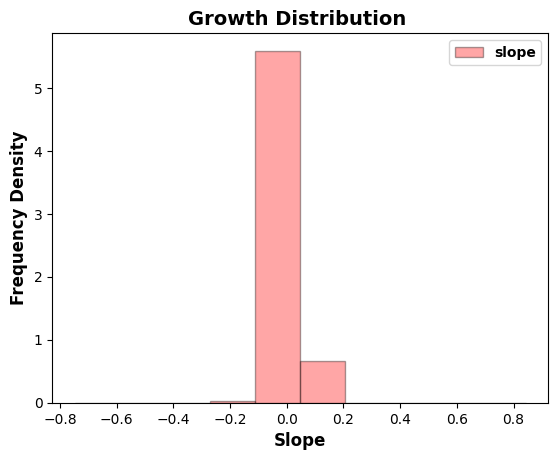

In [45]:
all_slopes = growth_distribution(track_df, lumenoid2_frame_ms, time_interval=10, forwardp=0)
#print(all_slopes)
#len(all_slopes)



plt.hist(all_slopes, color = 'red', edgecolor='black', alpha=0.35, density=True, label='slope')
plt.xlabel('Slope', fontsize = 12, weight = 'bold')  # X-axis label
plt.ylabel('Frequency Density', fontsize = 12, weight = 'bold')  # Y-axis label
plt.title(f'Growth Distribution ', fontsize = 14, weight = 'bold')  # Title of the histogram
plt.legend(prop = {'weight':'bold'})
plt.show()

In [46]:
print(all_slopes[1])

-0.08525638885321878


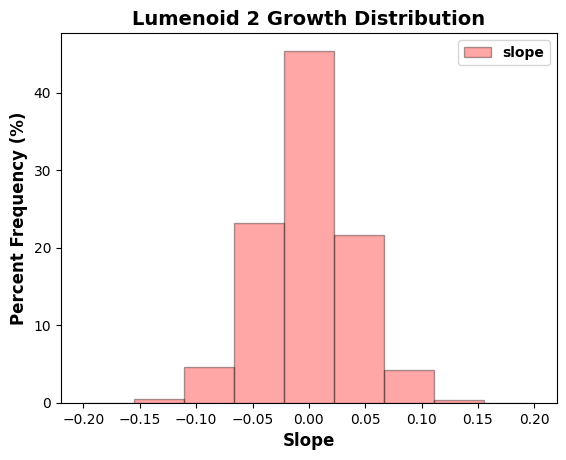

In [47]:
# plt.hist(all_slopes, bins = np.linspace(-0.09, 0.09, 6), color = 'red', edgecolor='black', alpha=0.35, density=True, label='slope')
# plt.xlabel('Slope', fontsize = 12, weight = 'bold')  # X-axis label
# plt.ylabel('Frequency Density', fontsize = 12, weight = 'bold')  # Y-axis label
# plt.title(f'Growth Distribution ', fontsize = 14, weight = 'bold')  # Title of the histogram
# plt.legend(prop = {'weight':'bold'})
# plt.show()
create_growth_dist_histogram(all_slopes, title="Lumenoid 2 Growth Distribution", bins=np.linspace(-0.2,0.2,10))

#### Apical CCS Growth Distribution

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

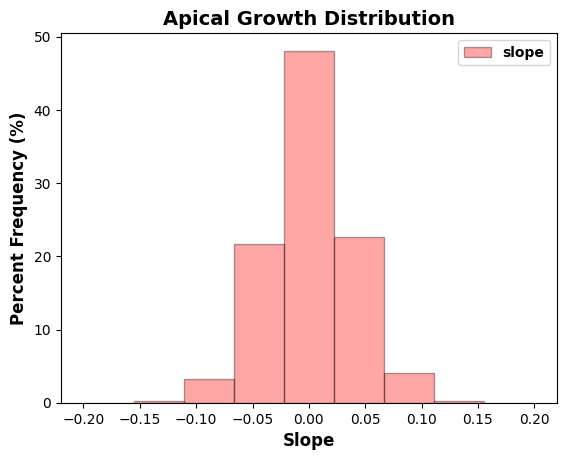

In [50]:
apical_tracks = trackFilter("Apical","False", filtered_tracks_treatment)
ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks['track_id'])]

apical_slopes = growth_distribution(ccs_apical_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
create_growth_dist_histogram(apical_slopes,title="Apical Growth Distribution", bins=np.linspace(-0.2,0.2,10))

#### Lateral CCS Growth Distribution

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

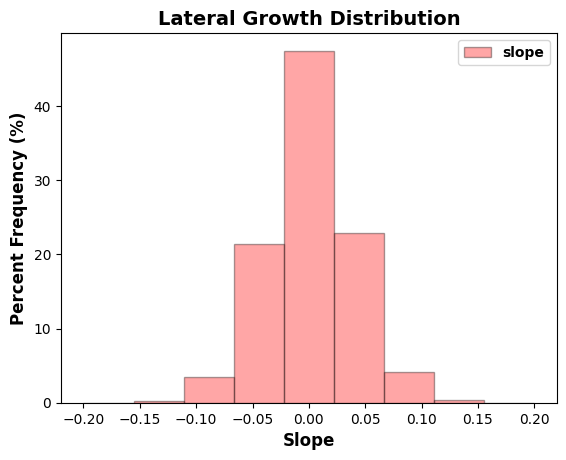

In [49]:
lateral_tracks = trackFilter("Lateral","False", filtered_tracks_treatment)
ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks['track_id'])]

lateral_slopes = growth_distribution(ccs_lateral_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
create_growth_dist_histogram(lateral_slopes,title="Lateral Growth Distribution", bins=np.linspace(-0.2,0.2,10))

#### Basal CCs Growth Distribution

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

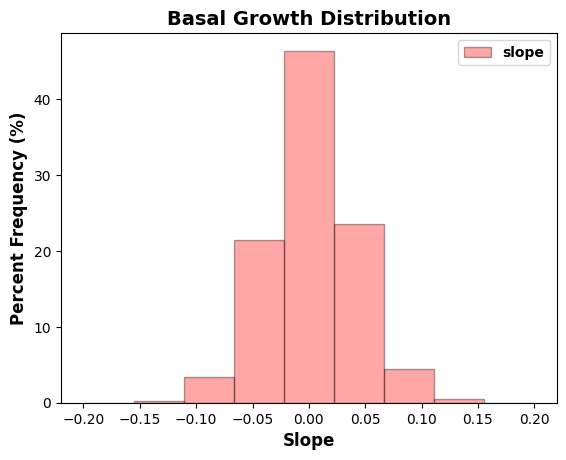

In [50]:
basal_tracks = trackFilter("Basal","False", filtered_tracks_treatment)
ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks['track_id'])]

basal_slopes = growth_distribution(ccs_basal_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
create_growth_dist_histogram(basal_slopes,title="Basal Growth Distribution", bins=np.linspace(-0.2,0.2,10))

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

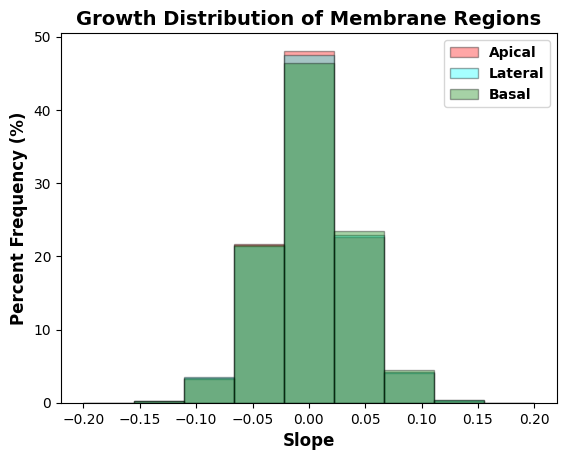

In [51]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
full_ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks_full['track_id'])]
full_apical_slopes = growth_distribution(full_ccs_apical_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

lateral_tracks_full = trackFilter("Lateral","False", filtered_tracks_treatment)
full_ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks_full['track_id'])]
full_lateral_slopes = growth_distribution(full_ccs_lateral_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

basal_tracks_full = trackFilter("Basal","False", filtered_tracks_treatment)
full_ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks_full['track_id'])]
full_basal_slopes = growth_distribution(full_ccs_basal_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([full_apical_slopes, full_lateral_slopes, full_basal_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
apical_weights = np.ones_like(full_apical_slopes) / len(full_apical_slopes) * 100
lateral_weights = np.ones_like(full_lateral_slopes) / len(full_lateral_slopes) * 100
basal_weights = np.ones_like(full_basal_slopes) / len(full_basal_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(full_apical_slopes, bins=bins, weights=apical_weights, color='red', edgecolor='black', alpha=0.35, label='Apical')
plt.hist(full_lateral_slopes, bins=bins, weights=lateral_weights, color='cyan', edgecolor='black', alpha=0.35, label='Lateral')
plt.hist(full_basal_slopes, bins=bins, weights=basal_weights, color='green', edgecolor='black', alpha=0.35, label='Basal')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

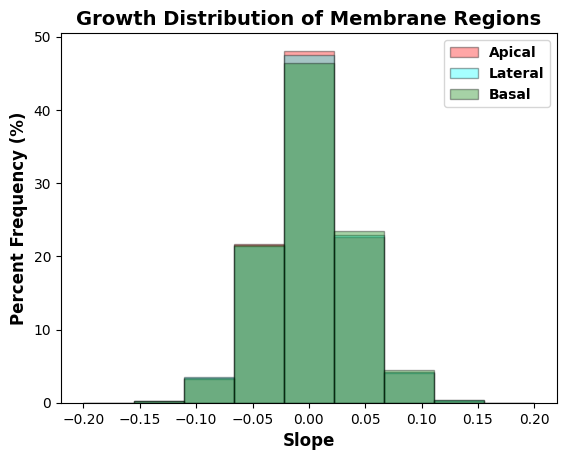

In [52]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
full_ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks_full['track_id'])]
full_apical_slopes = growth_distribution(full_ccs_apical_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

lateral_tracks_full = trackFilter("Lateral","False", filtered_tracks_treatment)
full_ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks_full['track_id'])]
full_lateral_slopes = growth_distribution(full_ccs_lateral_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

basal_tracks_full = trackFilter("Basal","False", filtered_tracks_treatment)
full_ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks_full['track_id'])]
full_basal_slopes = growth_distribution(full_ccs_basal_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([full_apical_slopes, full_lateral_slopes, full_basal_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
apical_weights = np.ones_like(full_apical_slopes) / len(full_apical_slopes) * 100
lateral_weights = np.ones_like(full_lateral_slopes) / len(full_lateral_slopes) * 100
basal_weights = np.ones_like(full_basal_slopes) / len(full_basal_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(full_apical_slopes, bins=bins, weights=apical_weights, color='red', edgecolor='black', alpha=0.35, label='Apical')
plt.hist(full_lateral_slopes, bins=bins, weights=lateral_weights, color='cyan', edgecolor='black', alpha=0.35, label='Lateral')
plt.hist(full_basal_slopes, bins=bins, weights=basal_weights, color='green', edgecolor='black', alpha=0.35, label='Basal')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

#### Arp2/3+ Dynamin+ vs Arp2/3- Dynamin+ 

Processing tracks:   0%|          | 0/3539 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2904 [00:00<?, ?it/s]

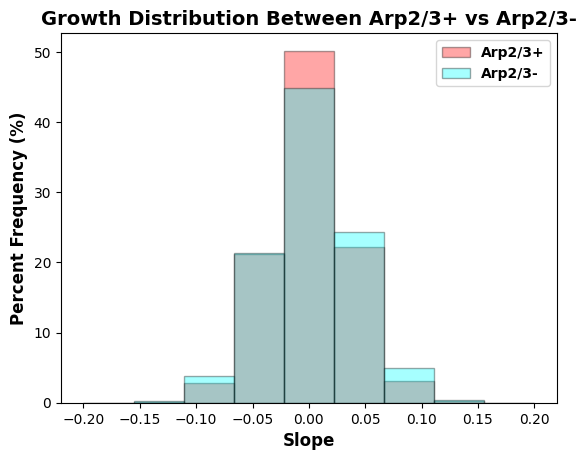

In [53]:
arp2_pos_all = trackFilter("All",False, filtered_tracks_treatment)
arp2_neg_all = trackFilter("All", False, filtered_tracks_treatment, [False,True])

arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(arp2_pos_all['track_id'])]
arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(arp2_neg_all['track_id'])]

arp2_pos_slopes = growth_distribution(arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)
arp2_neg_slopes = growth_distribution(arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([arp2_pos_slopes, arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(arp2_pos_slopes) / len(arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(arp2_neg_slopes) / len(arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

#### Apical Arp2/3+ vs Arp2/3-

Processing tracks:   0%|          | 0/259 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/230 [00:00<?, ?it/s]

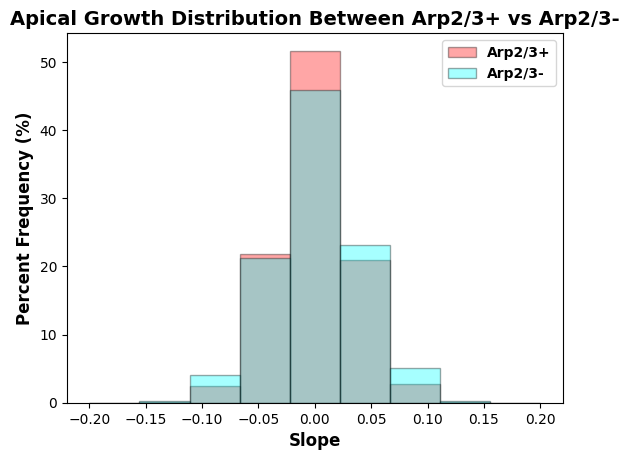

In [54]:
apical_arp2_pos_all = trackFilter("Apical",False, filtered_tracks_treatment)
apical_arp2_neg_all = trackFilter("Apical", False, filtered_tracks_treatment, [False,True])

apical_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_pos_all['track_id'])]
apical_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_neg_all['track_id'])]

apical_arp2_pos_slopes = growth_distribution(apical_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
apical_arp2_neg_slopes = growth_distribution(apical_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([apical_arp2_pos_slopes, apical_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(apical_arp2_pos_slopes) / len(apical_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(apical_arp2_neg_slopes) / len(apical_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(apical_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(apical_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Apical Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/1905 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/1352 [00:00<?, ?it/s]

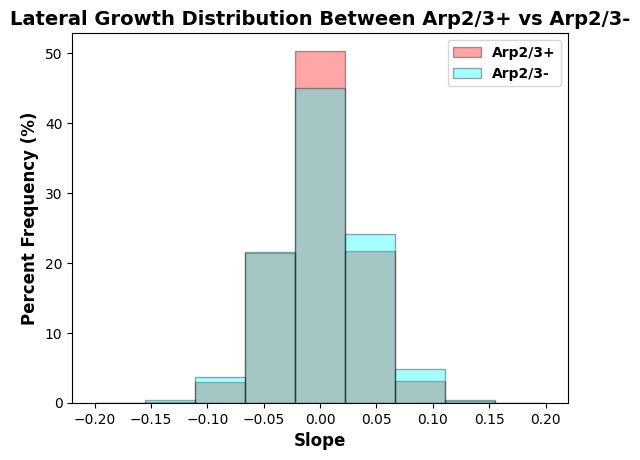

In [55]:
lateral_arp2_pos_all = trackFilter("Lateral",False, filtered_tracks_treatment)
lateral_apical_arp2_neg_all = trackFilter("Lateral", False, filtered_tracks_treatment, [False,True])

lateral_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(lateral_arp2_pos_all['track_id'])]
lateral_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(lateral_apical_arp2_neg_all['track_id'])]

lateral_arp2_pos_slopes = growth_distribution(lateral_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
lateral_arp2_neg_slopes = growth_distribution(lateral_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([lateral_arp2_pos_slopes, lateral_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(lateral_arp2_pos_slopes) / len(lateral_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(lateral_arp2_neg_slopes) / len(lateral_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(lateral_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(lateral_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Lateral Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/655 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/630 [00:00<?, ?it/s]

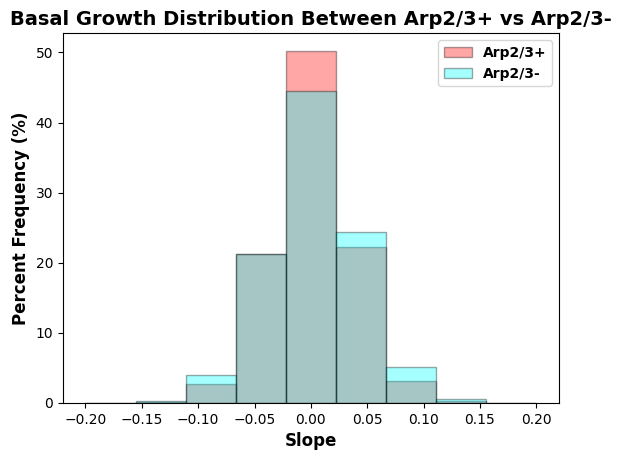

In [56]:
basal_arp2_pos_all = trackFilter("Basal",False, filtered_tracks_treatment)
basal_apical_arp2_neg_all = trackFilter("Basal", False, filtered_tracks_treatment, [False,True])

basal_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(basal_arp2_pos_all['track_id'])]
basal_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(basal_apical_arp2_neg_all['track_id'])]

basal_arp2_pos_slopes = growth_distribution(basal_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
basal_arp2_neg_slopes = growth_distribution(basal_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([basal_arp2_pos_slopes, basal_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(basal_arp2_pos_slopes) / len(basal_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(basal_arp2_neg_slopes) / len(basal_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(basal_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(basal_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Basal Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

## CCS Testing Python Packaged Least Squares

In [101]:
input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
ccs_track_df = pd.read_pickle(input_directory_all_tracks_full)


In [53]:
auto_slopes = auto_growth_distribution(ccs_track_df, lumenoid2_frame_ms, time_interval=10, forwardp=0)
#print(all_slopes)
#len(all_slopes)


Processing tracks:   0%|          | 0/67768 [00:00<?, ?it/s]

KeyboardInterrupt: 

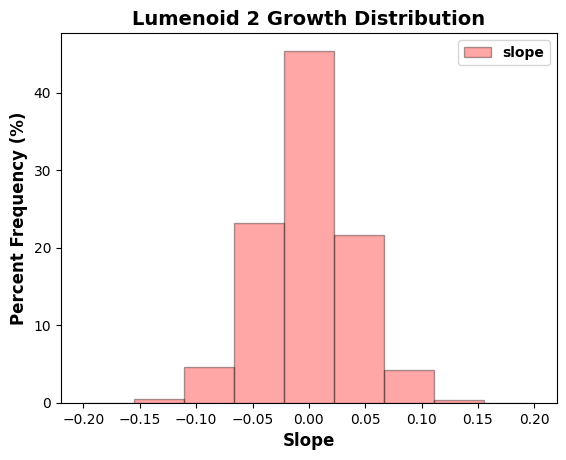

In [66]:
create_growth_dist_histogram(auto_slopes, title="Lumenoid 2 Growth Distribution", bins=np.linspace(-0.2,0.2,10))

### Comparing Membrane regions for all tracks

In [140]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
test = extract_trackid_data(apical_tracks_full,2)
group_intensities_trackid(apical_tracks_full,2)
type(test['c3_voxel_sum_adjusted'].tolist()[0])

numpy.ndarray

In [134]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
full_ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks_full['track_id'])]
test3 = extract_trackid_data(full_ccs_apical_tracks,2)
test3['c3_voxel_sum_adjusted'].tolist() == test['c3_voxel_sum_adjusted'].tolist()[0].tolist()

True

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

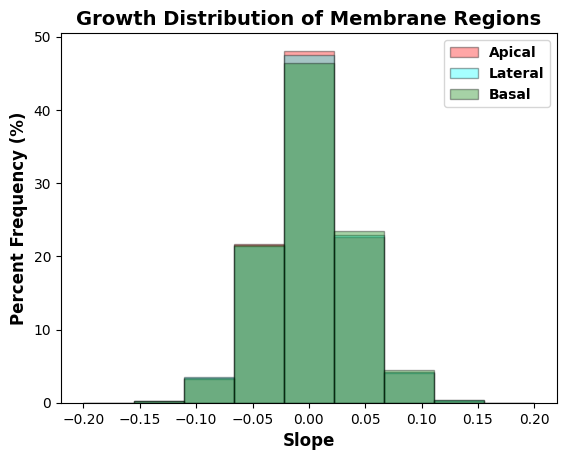

In [ ]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
#full_ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks_full['track_id'])]
full_apical_slopes = auto_growth_distribution(apical_tracks_full, lumenoid2_frame_ms, time_interval=10, forwardp=0)

lateral_tracks_full = trackFilter("Lateral","False", filtered_tracks_treatment)
#full_ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks_full['track_id'])]
full_lateral_slopes = auto_growth_distribution(lateral_tracks_full, lumenoid2_frame_ms, time_interval=10, forwardp=0)

basal_tracks_full = trackFilter("Basal","False", filtered_tracks_treatment)
#full_ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks_full['track_id'])]
full_basal_slopes = auto_growth_distribution(basal_tracks_full, lumenoid2_frame_ms, time_interval=10, forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([full_apical_slopes, full_lateral_slopes, full_basal_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
apical_weights = np.ones_like(full_apical_slopes) / len(full_apical_slopes) * 100
lateral_weights = np.ones_like(full_lateral_slopes) / len(full_lateral_slopes) * 100
basal_weights = np.ones_like(full_basal_slopes) / len(full_basal_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(full_apical_slopes, bins=bins, weights=apical_weights, color='red', edgecolor='black', alpha=0.35, label='Apical')
plt.hist(full_lateral_slopes, bins=bins, weights=lateral_weights, color='cyan', edgecolor='black', alpha=0.35, label='Lateral')
plt.hist(full_basal_slopes, bins=bins, weights=basal_weights, color='green', edgecolor='black', alpha=0.35, label='Basal')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

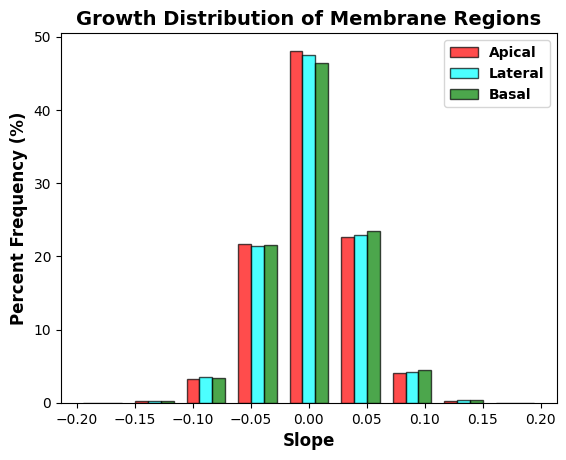

In [ ]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
#full_ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks_full['track_id'])]
full_apical_slopes = auto_growth_distribution(full_ccs_apical_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

lateral_tracks_full = trackFilter("Lateral","False", filtered_tracks_treatment)
#full_ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks_full['track_id'])]
full_lateral_slopes = auto_growth_distribution(full_ccs_lateral_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

basal_tracks_full = trackFilter("Basal","False", filtered_tracks_treatment)
#full_ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks_full['track_id'])]
full_basal_slopes = auto_growth_distribution(full_ccs_basal_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([full_apical_slopes, full_lateral_slopes, full_basal_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
apical_weights = np.ones_like(full_apical_slopes) / len(full_apical_slopes) * 100
lateral_weights = np.ones_like(full_lateral_slopes) / len(full_lateral_slopes) * 100
basal_weights = np.ones_like(full_basal_slopes) / len(full_basal_slopes) * 100

# Compute histogram data
apical_counts, bin_edges = np.histogram(full_apical_slopes, bins=bins, weights=apical_weights)
lateral_counts, lateral_edges = np.histogram(full_lateral_slopes, bins=bins, weights=lateral_weights)
basal_counts, apical_edges = np.histogram(full_basal_slopes, bins=bins, weights=basal_weights)

# Width for each bar group
bar_width = (bin_edges[1] - bin_edges[0]) / 4  # divide bin width for spacing

# Bar positions (centers shifted)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers - bar_width, apical_counts, width=bar_width, color='red', edgecolor='black', alpha=0.7, label='Apical')
plt.bar(bin_centers, lateral_counts, width=bar_width, color='cyan', edgecolor='black', alpha=0.7, label='Lateral')
plt.bar(bin_centers + bar_width, basal_counts, width=bar_width, color='green', edgecolor='black', alpha=0.7, label='Basal')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

#### Arp2/3+ Dynamin+ vs Arp2/3- Dynamin+ 

Processing tracks:   0%|          | 0/3539 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2904 [00:00<?, ?it/s]

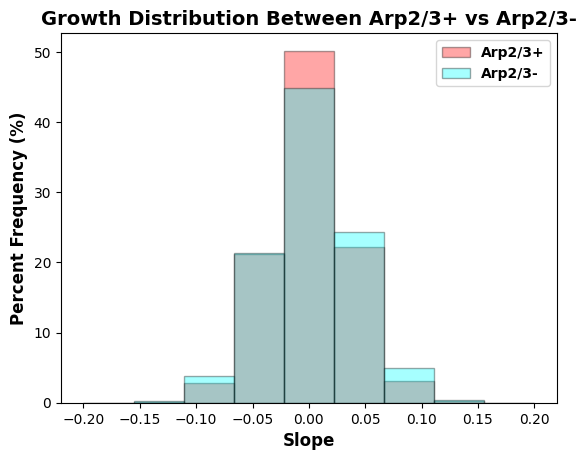

In [ ]:
arp2_pos_all = trackFilter("All",False, filtered_tracks_treatment)
arp2_neg_all = trackFilter("All", False, filtered_tracks_treatment, [False,True])

arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(arp2_pos_all['track_id'])]
arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(arp2_neg_all['track_id'])]

arp2_pos_slopes = growth_distribution(arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)
arp2_neg_slopes = growth_distribution(arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([arp2_pos_slopes, arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(arp2_pos_slopes) / len(arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(arp2_neg_slopes) / len(arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

### Comparing membrane regions Arp2/3+ vs Arp2/3-

Processing tracks:   0%|          | 0/259 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/230 [00:00<?, ?it/s]

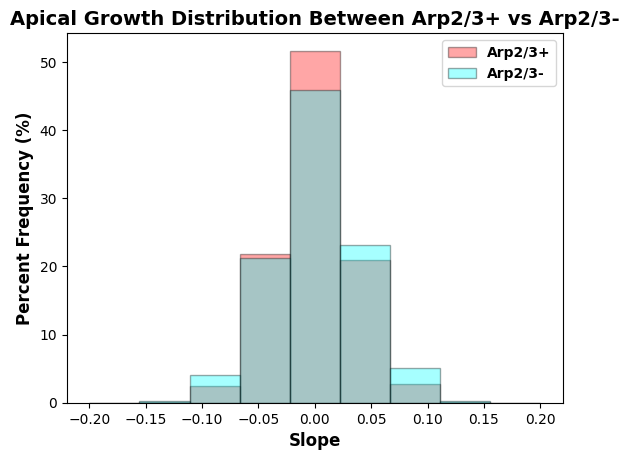

In [ ]:
apical_arp2_pos_all = trackFilter("Apical",False, filtered_tracks_treatment)
apical_arp2_neg_all = trackFilter("Apical", False, filtered_tracks_treatment, [False,True])

apical_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_pos_all['track_id'])]
apical_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_neg_all['track_id'])]

apical_arp2_pos_slopes = auto_growth_distribution(apical_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
apical_arp2_neg_slopes = auto_growth_distribution(apical_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([apical_arp2_pos_slopes, apical_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(apical_arp2_pos_slopes) / len(apical_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(apical_arp2_neg_slopes) / len(apical_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(apical_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(apical_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Apical Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/1905 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/1352 [00:00<?, ?it/s]

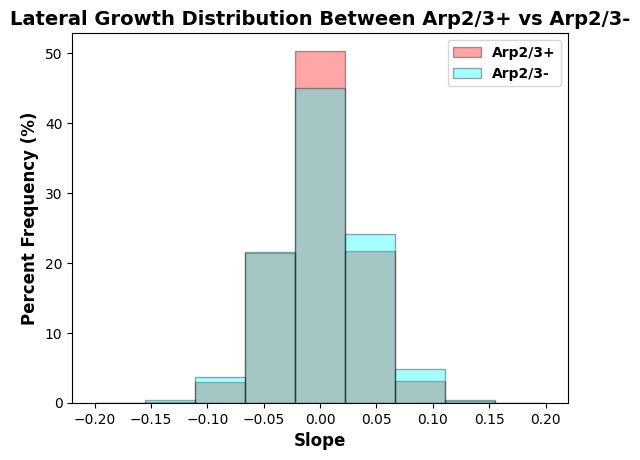

In [ ]:
lateral_arp2_pos_all = trackFilter("Lateral",False, filtered_tracks_treatment)
lateral_apical_arp2_neg_all = trackFilter("Lateral", False, filtered_tracks_treatment, [False,True])

lateral_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(lateral_arp2_pos_all['track_id'])]
lateral_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(lateral_apical_arp2_neg_all['track_id'])]

lateral_arp2_pos_slopes = auto_growth_distribution(lateral_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
lateral_arp2_neg_slopes = auto_growth_distribution(lateral_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([lateral_arp2_pos_slopes, lateral_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(lateral_arp2_pos_slopes) / len(lateral_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(lateral_arp2_neg_slopes) / len(lateral_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(lateral_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(lateral_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Lateral Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

Processing tracks:   0%|          | 0/655 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/630 [00:00<?, ?it/s]

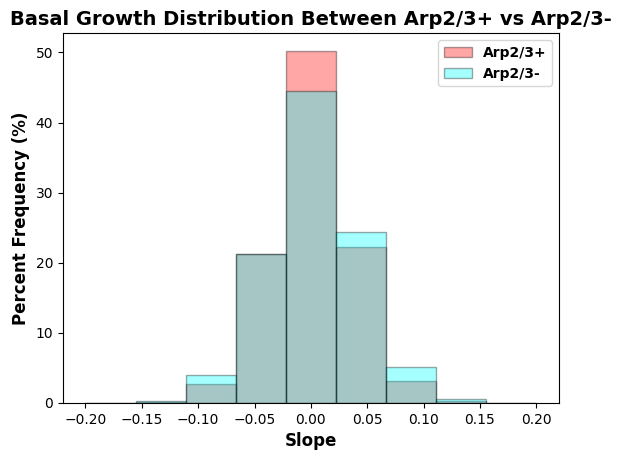

In [ ]:
basal_arp2_pos_all = trackFilter("Basal",False, filtered_tracks_treatment)
basal_apical_arp2_neg_all = trackFilter("Basal", False, filtered_tracks_treatment, [False,True])

basal_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(basal_arp2_pos_all['track_id'])]
basal_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(basal_apical_arp2_neg_all['track_id'])]

basal_arp2_pos_slopes = auto_growth_distribution(basal_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
basal_arp2_neg_slopes = auto_growth_distribution(basal_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([basal_arp2_pos_slopes, basal_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(basal_arp2_pos_slopes) / len(basal_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(basal_arp2_neg_slopes) / len(basal_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
plt.hist(basal_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights, color='red', edgecolor='black', alpha=0.35, label='Arp2/3+')
plt.hist(basal_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights, color='cyan', edgecolor='black', alpha=0.35, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Basal Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

### Smooth Growth Distribution of Lumenoid 2

In [ ]:
auto_slopes = smoothed_auto_growth_distribution(track_df, lumenoid2_frame_ms,base_frac=0.2, time_interval=10.5, forwardp=0)

Processing tracks:   0%|          | 0/67768 [00:00<?, ?it/s]

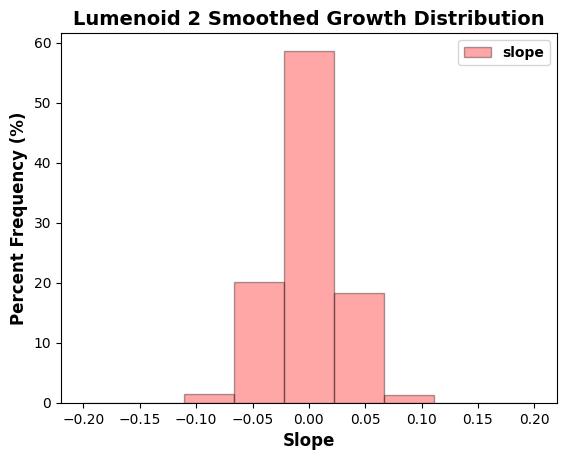

In [ ]:
create_growth_dist_histogram(auto_slopes, title="Lumenoid 2 Smoothed Growth Distribution", bins=np.linspace(-0.2,0.2,10))

### Smoothed Growth Distrubtion of Membrane Regions

Processing tracks:   0%|          | 0/880 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/4883 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/2011 [00:00<?, ?it/s]

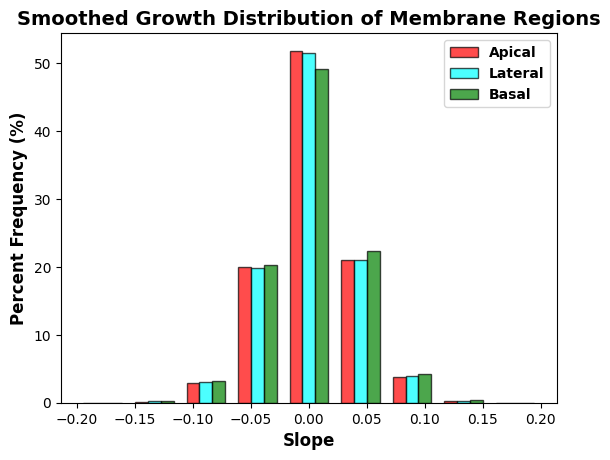

In [ ]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
full_ccs_apical_tracks = track_df[track_df['track_id'].isin(apical_tracks_full['track_id'])]
full_apical_slopes = smoothed_auto_growth_distribution(full_ccs_apical_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

lateral_tracks_full = trackFilter("Lateral","False", filtered_tracks_treatment)
full_ccs_lateral_tracks = track_df[track_df['track_id'].isin(lateral_tracks_full['track_id'])]
full_lateral_slopes = smoothed_auto_growth_distribution(full_ccs_lateral_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)

basal_tracks_full = trackFilter("Basal","False", filtered_tracks_treatment)
full_ccs_basal_tracks = track_df[track_df['track_id'].isin(basal_tracks_full['track_id'])]
full_basal_slopes = smoothed_auto_growth_distribution(full_ccs_basal_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([full_apical_slopes, full_lateral_slopes, full_basal_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
apical_weights = np.ones_like(full_apical_slopes) / len(full_apical_slopes) * 100
lateral_weights = np.ones_like(full_lateral_slopes) / len(full_lateral_slopes) * 100
basal_weights = np.ones_like(full_basal_slopes) / len(full_basal_slopes) * 100

# Compute histogram data
apical_counts, bin_edges = np.histogram(full_apical_slopes, bins=bins, weights=apical_weights)
lateral_counts, _ = np.histogram(full_lateral_slopes, bins=bins, weights=lateral_weights)
basal_counts, _ = np.histogram(full_basal_slopes, bins=bins, weights=basal_weights)

# Width for each bar group
bar_width = (bin_edges[1] - bin_edges[0]) / 4  # divide bin width for spacing

# Bar positions (centers shifted)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers - bar_width, apical_counts, width=bar_width, color='red', edgecolor='black', alpha=0.7, label='Apical')
plt.bar(bin_centers, lateral_counts, width=bar_width, color='cyan', edgecolor='black', alpha=0.7, label='Lateral')
plt.bar(bin_centers + bar_width, basal_counts, width=bar_width, color='green', edgecolor='black', alpha=0.7, label='Basal')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Smoothed Growth Distribution of Membrane Regions', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

### Arp2/3+ vs Ar2/3- Smoothed Distribution

#### Apical

Processing tracks:   0%|          | 0/259 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/230 [00:00<?, ?it/s]

[0.01960120603957302, -0.024471900779361018, -0.04965041431523273, -0.059885525129463324, -0.05877153347861266, -0.04954584931437912, -0.035088992283600025, -0.017924591728251085, -0.00021938668544724775, 0.016216774112559108, 0.029930932238375455, 0.03982701956954345, 0.04281455030683111, 0.04168871236899055, 0.03512806442836748, 0.023845496455182576, 0.006813349450888716, -0.007500257842444373, -0.01795772357408675, -0.0246494500831783, -0.028615888857534924, -0.029426629391548203, -0.028576535350754922, -0.026759977264573624, -0.02379134115640846, -0.02391816225220403, -0.02142350615795812, -0.015223495735511152, -0.007188328532714585, 0.0008741953554265227, 0.0075361451400647525, 0.014507930696714343, 0.01588596872365265, 0.01693000838359587, 0.01586761385676418, 0.015227507223375847, 0.013592802046326433, 0.010795259232607206, 0.012389635433009274, 0.0144061703735127, 0.014611588813465446, 0.012728386018856296, 0.011141329982689241, 0.013093445096613594, 0.013013140819260523, 0.01

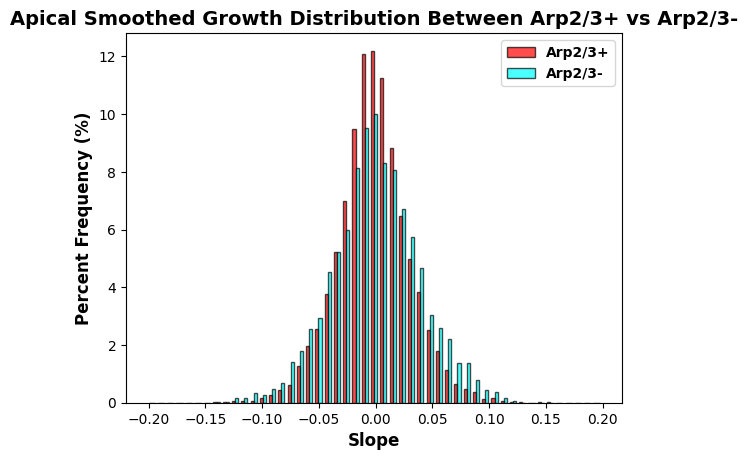

In [ ]:
apical_arp2_pos_all = trackFilter("Apical",False, filtered_tracks_treatment)
apical_arp2_neg_all = trackFilter("Apical", False, filtered_tracks_treatment, [False,True])

apical_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_pos_all['track_id'])]
apical_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(apical_arp2_neg_all['track_id'])]

apical_arp2_pos_slopes = smoothed_auto_growth_distribution(apical_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
apical_arp2_neg_slopes = smoothed_auto_growth_distribution(apical_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([apical_arp2_pos_slopes, apical_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,50))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(apical_arp2_pos_slopes) / len(apical_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(apical_arp2_neg_slopes) / len(apical_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
arp2_pos_counts, bin_edges = np.histogram(apical_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights)
arp2_neg_counts, _ = np.histogram(apical_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights)

# Width for each bar group
bar_width = (bin_edges[1] - bin_edges[0]) / 3  # divide bin width for spacing


# Bar positions (centers shifted)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers - bar_width, arp2_pos_counts, width=bar_width, color='red', edgecolor='black', alpha=0.7, label='Arp2/3+')
plt.bar(bin_centers, arp2_neg_counts, width=bar_width, color='cyan', edgecolor='black', alpha=0.7, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Apical Smoothed Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

#### Lateral

In [47]:
lateral_arp2_pos_all = trackFilter("Lateral",False, filtered_tracks_treatment)
lateral_apical_arp2_neg_all = trackFilter("Lateral", False, filtered_tracks_treatment, [False,True])

lateral_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(lateral_arp2_pos_all['track_id'])]
lateral_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(lateral_apical_arp2_neg_all['track_id'])]

lateral_arp2_pos_slopes = smoothed_auto_growth_distribution(lateral_arp2_pos_all, lumenoid2_frame_ms, time_interval=10, forwardp=0)
lateral_arp2_neg_slopes = smoothed_auto_growth_distribution(lateral_apical_arp2_neg_all, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([lateral_arp2_pos_slopes, lateral_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(lateral_arp2_pos_slopes) / len(lateral_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(lateral_arp2_neg_slopes) / len(lateral_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
arp2_pos_counts, bin_edges = np.histogram(lateral_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights)
arp2_neg_counts, _ = np.histogram(lateral_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights)

# Width for each bar group
bar_width = (bin_edges[1] - bin_edges[0]) / 3  # divide bin width for spacing


# Bar positions (centers shifted)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers - bar_width, arp2_pos_counts, width=bar_width, color='red', edgecolor='black', alpha=0.7, label='Arp2/3+')
plt.bar(bin_centers, arp2_neg_counts, width=bar_width, color='cyan', edgecolor='black', alpha=0.7, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Lateral Smoothed Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

NameError: name 'track_df' is not defined

#### Basal

Processing tracks:   0%|          | 0/655 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/630 [00:00<?, ?it/s]

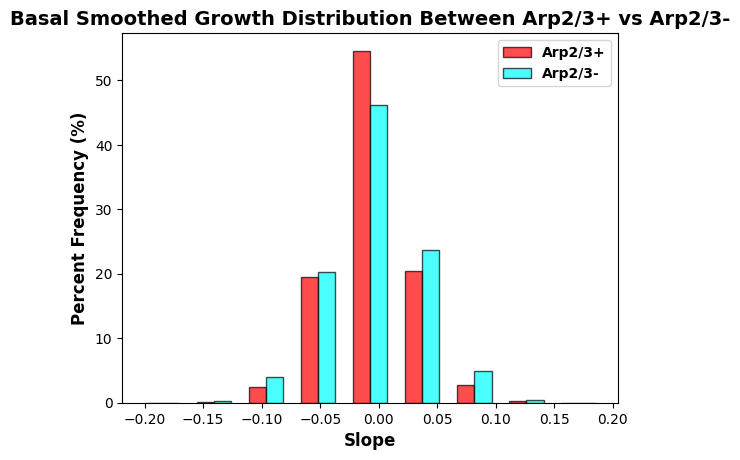

In [ ]:
basal_arp2_pos_all = trackFilter("Basal",False, filtered_tracks_treatment)
basal_apical_arp2_neg_all = trackFilter("Basal", False, filtered_tracks_treatment, [False,True])

basal_arp2_pos_all_tracks =  track_df[track_df['track_id'].isin(basal_arp2_pos_all['track_id'])]
basal_arp2_neg_all_tracks =  track_df[track_df['track_id'].isin(basal_apical_arp2_neg_all['track_id'])]

basal_arp2_pos_slopes = smoothed_auto_growth_distribution(basal_arp2_pos_all_tracks, lumenoid2_frame_ms, time_interval=10, forwardp=0)
basal_arp2_neg_slopes = smoothed_auto_growth_distribution(basal_arp2_neg_all_tracks, lumenoid2_frame_ms, time_interval=10,forwardp=0)


# Number of bins to share across all datasets
bins = np.histogram_bin_edges(np.concatenate([basal_arp2_pos_slopes, basal_arp2_neg_slopes]), bins= np.linspace(-0.2,0.2,10))

# Calculate weights for percent frequency
arp2_pos_weights = np.ones_like(basal_arp2_pos_slopes) / len(basal_arp2_pos_slopes) * 100
arp2_neg_weights = np.ones_like(basal_arp2_neg_slopes) / len(basal_arp2_neg_slopes) * 100

# Plot histograms as percent frequencies
arp2_pos_counts, bin_edges = np.histogram(basal_arp2_pos_slopes, bins=bins, weights=arp2_pos_weights)
arp2_neg_counts, _ = np.histogram(basal_arp2_neg_slopes, bins=bins, weights=arp2_neg_weights)

# Width for each bar group
bar_width = (bin_edges[1] - bin_edges[0]) / 3  # divide bin width for spacing


# Bar positions (centers shifted)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers - bar_width, arp2_pos_counts, width=bar_width, color='red', edgecolor='black', alpha=0.7, label='Arp2/3+')
plt.bar(bin_centers, arp2_neg_counts, width=bar_width, color='cyan', edgecolor='black', alpha=0.7, label='Arp2/3-')

# Axis and legend styling
plt.xlabel('Slope', fontsize=12, weight='bold')
plt.ylabel('Percent Frequency (%)', fontsize=12, weight='bold')
plt.title('Basal Smoothed Growth Distribution Between Arp2/3+ vs Arp2/3-', fontsize=14, weight='bold')
plt.legend(prop={'weight': 'bold'})

plt.show()

## Better CCS Plotting Testing

In [399]:
slope_df = slope_dateframe(ccs_track_df, lumenoid2_frame_ms, time_interval=10, forwardp=0)

Processing tracks:   0%|          | 0/67768 [00:00<?, ?it/s]

In [400]:
output_directory = 'datasets'
output_file_name = 'ccs_slope_tracks.pkl' # can change this to filtered_tracks_final.pkl. region_filtered... just for testing purposes
output_directory_full = os.path.join(base_dir, input_file_directory, output_directory, output_file_name)
slope_df.to_pickle(output_directory_full)

In [322]:
all_slopes = pd.read_pickle(os.path.join(base_dir, input_file_directory, 'datasets', 'ccs_slope_tracks.pkl'))

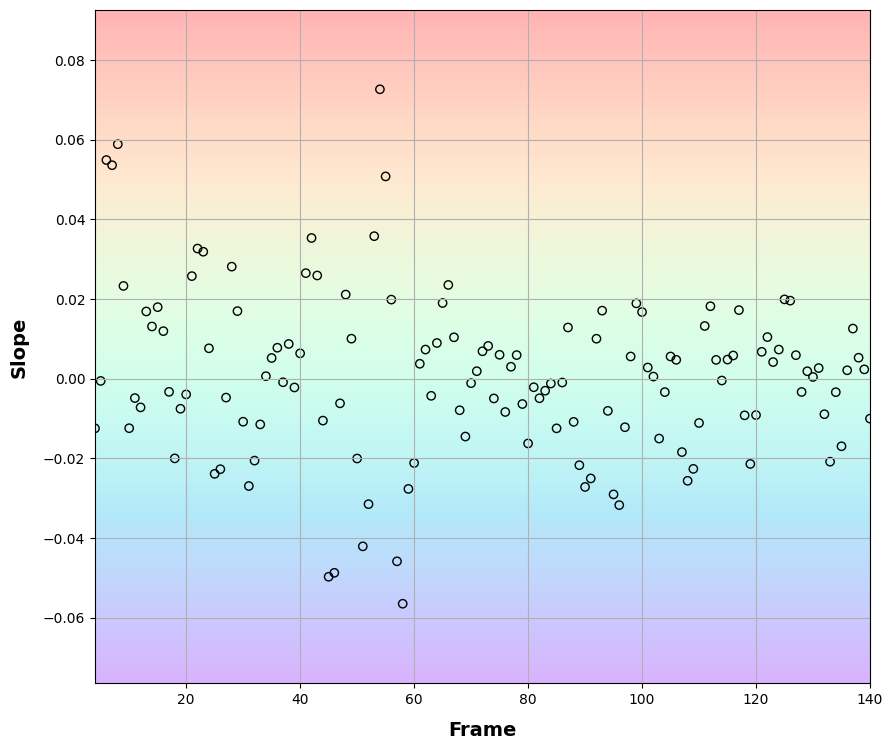

In [401]:
slope_zero, slope_to_frame = slope_plot(track_df, 0, lumenoid2_frame_ms, 10.5)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\41269647.py:71: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


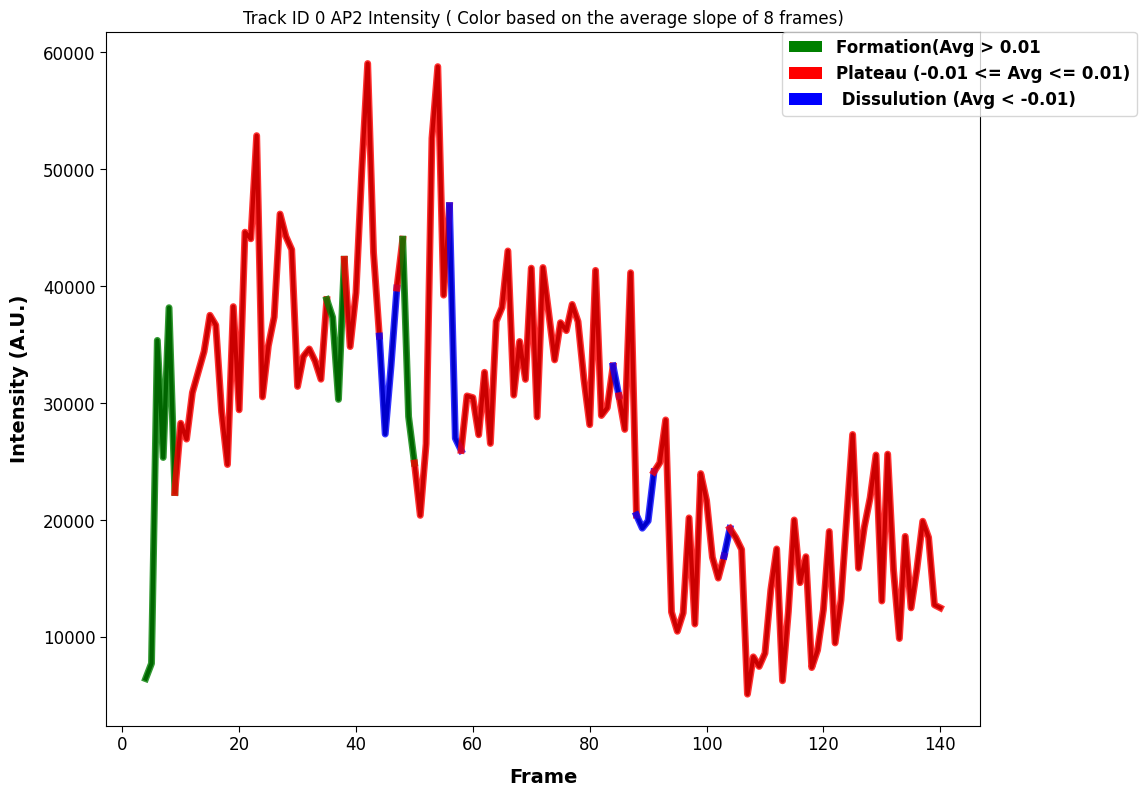

In [402]:
# set 'normalized = False' to plot raw intensities

input_directory_all_tracks_full = os.path.join(base_dir, input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
track_df = pd.read_pickle(input_directory_all_tracks_full)
slope_color_coded_intensity_time_plot(dataframe = track_df, tracks_to_plot = 0, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_zero[0], avg_size=8, frame_list=slope_to_frame, threshold = 0.01,graph_title = 'AP2 Intensity', normalized=False, save_plot = False)

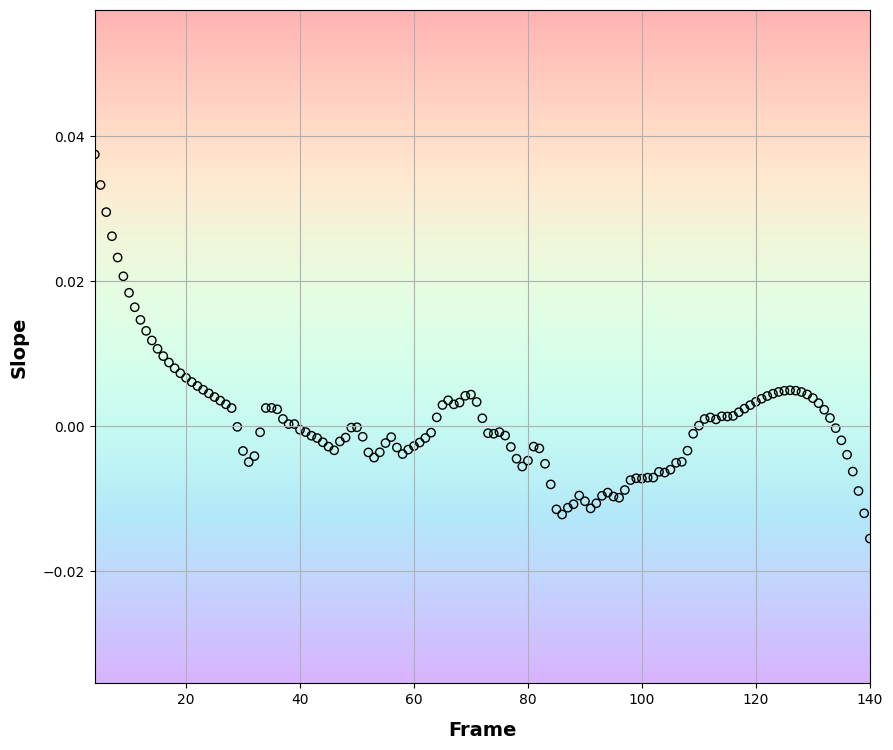

In [403]:
slope_zero, slope_to_frame = smoothed_slope_plot(track_df, 0, lumenoid2_frame_ms, 10.5)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\1554819204.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


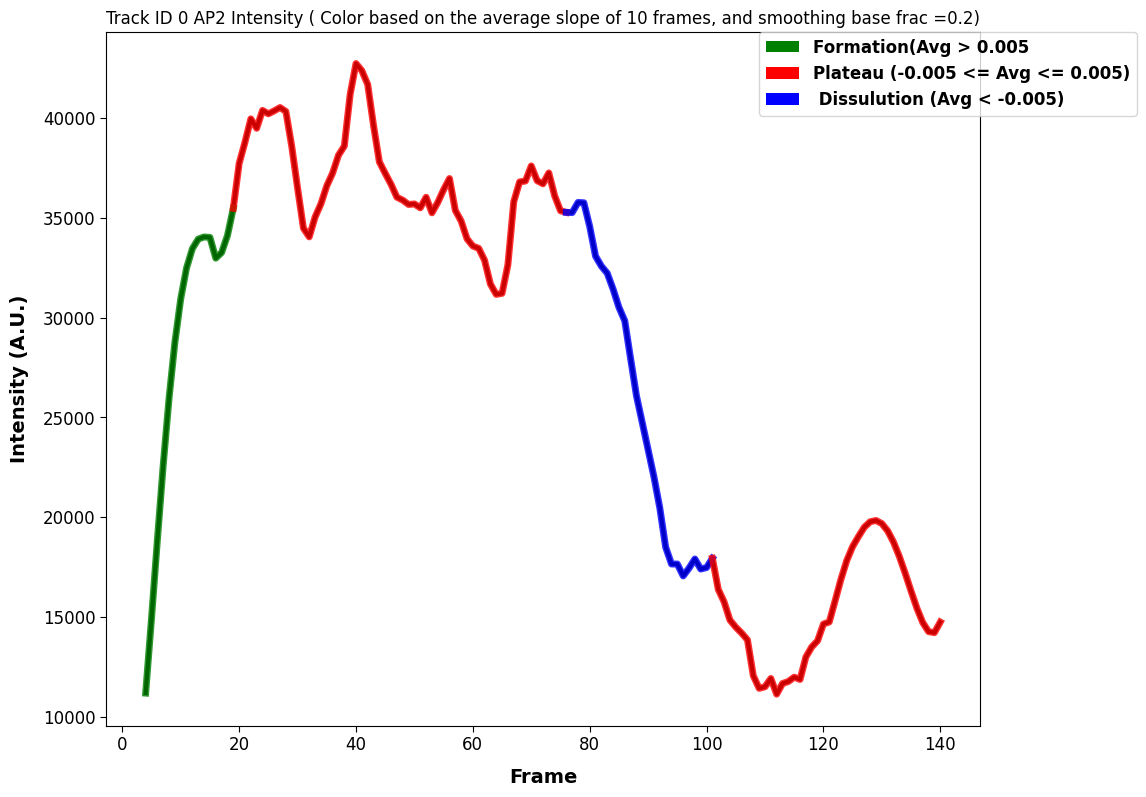

In [404]:
base_frac = 0.2
smooth_slope_color_coded_intensity_time_plot(dataframe = track_df, tracks_to_plot = 0, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_zero[0], avg_size=10, frame_list=np.array(slope_to_frame), threshold = 0.005, base_frac = base_frac, graph_title = 'AP2 Intensity', normalized=False, save_plot = False)

### Arp2/3+ Vs Arp2/3- Slope Analysis

In [405]:
smoothed_slope_df = smoothed_slope_dateframe(ccs_track_df, lumenoid2_frame_ms, time_interval=10.5, forwardp=0)

Processing tracks:   0%|          | 0/67768 [00:00<?, ?it/s]

In [406]:
output_directory = 'datasets'
output_file_name = 'ccs_smoothed_slope_tracks.pkl' # can change this to filtered_tracks_final.pkl. region_filtered... just for testing purposes
output_directory_full = os.path.join(base_dir, input_file_directory, output_directory, output_file_name)
smoothed_slope_df.to_pickle(output_directory_full)

In [407]:
all_arp2_pos_all = trackFilter("All",False, filtered_tracks_treatment)
all_arp2_neg_all = trackFilter("All", False, filtered_tracks_treatment, [False,True])

all_arp2_pos_all_tracks =  smoothed_slope_df[smoothed_slope_df['track_id'].isin(all_arp2_pos_all['track_id'])]
all_arp2_neg_all_tracks =  smoothed_slope_df[smoothed_slope_df['track_id'].isin(all_arp2_neg_all['track_id'])]

In [408]:

# Example: define your bins
bins = np.arange(-0.2, 0.2, 0.01)  # bins: [0.0, 0.5, 1.0, 1.5, 2.0]

# Function to bin slopes for a single track
def bin_slopes(slopes):
    #print(f"Binning slopes: {slopes}")
    counts, _ = np.histogram(slopes, bins=bins)
    #print(f"Counts in bins: {counts}")
    return counts
# df2 = smoothed_slope_df[smoothed_slope_df["track_id"].isin(all_arp2_neg_all_tracks['track_id'].unique())]
# Apply binning per track
def bin_dfs(df):
    df["bin_counts"] = df["slopes"].apply(bin_slopes)

    # Convert list of counts to DataFrame
    bin_counts_df = pd.DataFrame(df["bin_counts"].to_list(), 
                                index=df["track_id"],
                                columns=[f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)])

    # Average across tracks
    average_bin_counts = bin_counts_df.mean(axis=0)#

    return bin_counts_df, average_bin_counts



In [409]:
dfa,dfb = bin_dfs(all_arp2_pos_all_tracks)
dfc,dfd = bin_dfs(all_arp2_neg_all_tracks)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\3794663665.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bin_counts"] = df["slopes"].apply(bin_slopes)
C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\3794663665.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bin_counts"] = df["slopes"].apply(bin_slopes)


In [410]:
dfd

-0.2--0.19                                      0.000000
-0.19--0.18                                     0.000000
-0.18--0.16999999999999998                      0.000000
-0.16999999999999998--0.15999999999999998       0.000000
-0.15999999999999998--0.14999999999999997       0.000000
-0.14999999999999997--0.13999999999999996       0.000000
-0.13999999999999996--0.12999999999999995       0.000000
-0.12999999999999995--0.11999999999999994       0.000000
-0.11999999999999994--0.10999999999999993       0.002091
-0.10999999999999993--0.09999999999999992       0.005925
-0.09999999999999992--0.08999999999999991       0.013942
-0.08999999999999991--0.0799999999999999        0.032764
-0.0799999999999999--0.0699999999999999         0.070408
-0.0699999999999999--0.05999999999999989        0.146741
-0.05999999999999989--0.04999999999999988       0.261415
-0.04999999999999988--0.03999999999999987       0.480307
-0.03999999999999987--0.02999999999999986       0.760195
-0.02999999999999986--0.0199999

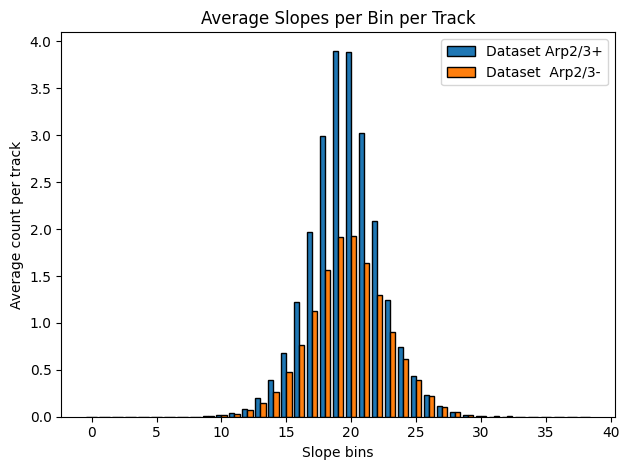

In [411]:
# X positions for bins
x = np.arange(len(dfb))  # one position per bin
width = 0.4               # width of each bar

plt.bar(x - width/2, dfb.values, width=width, label="Dataset Arp2/3+", edgecolor='black')
plt.bar(x + width/2, dfd.values, width=width, label="Dataset  Arp2/3-", edgecolor='black')

plt.xlabel('Slope bins')
plt.ylabel('Average count per track')
plt.title('Average Slopes per Bin per Track')
#plt.xticks(x, dfb.index, rotation=45)  # use bin labels from dfb.index
plt.legend()
plt.tight_layout()
plt.show()

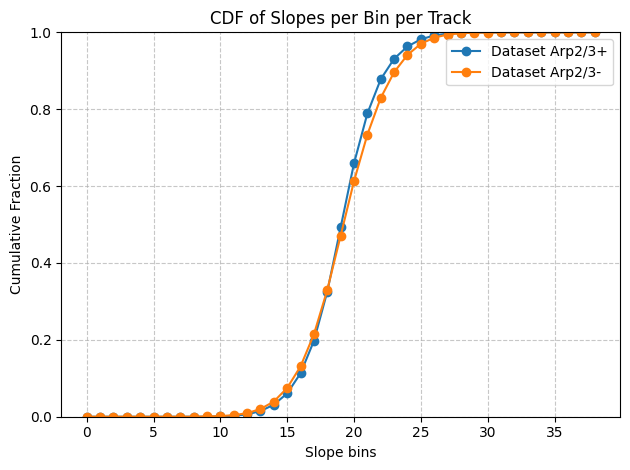

In [412]:
import numpy as np
import matplotlib.pyplot as plt

# X positions for bins
x = np.arange(len(dfb))  # one position per bin

# Convert to CDF (cumulative fraction)
cdf_b = np.cumsum(dfb.values) / np.sum(dfb.values)
cdf_d = np.cumsum(dfd.values) / np.sum(dfd.values)

# Plot dots per bin
plt.plot(x, cdf_b, 'o-', label="Dataset Arp2/3+")
plt.plot(x, cdf_d, 'o-', label="Dataset Arp2/3-")

plt.xlabel('Slope bins')
plt.ylabel('Cumulative Fraction')
plt.title('CDF of Slopes per Bin per Track')
#plt.xticks(x, dfb.index, rotation=45)  # bin labels from dfb.index
plt.ylim(0, 1)  # CDF always between 0 and 1
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


## Color Coded Intensity Slopes on Membrane Regions

#### Apical Slope Graph Testing

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\41269647.py:71: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


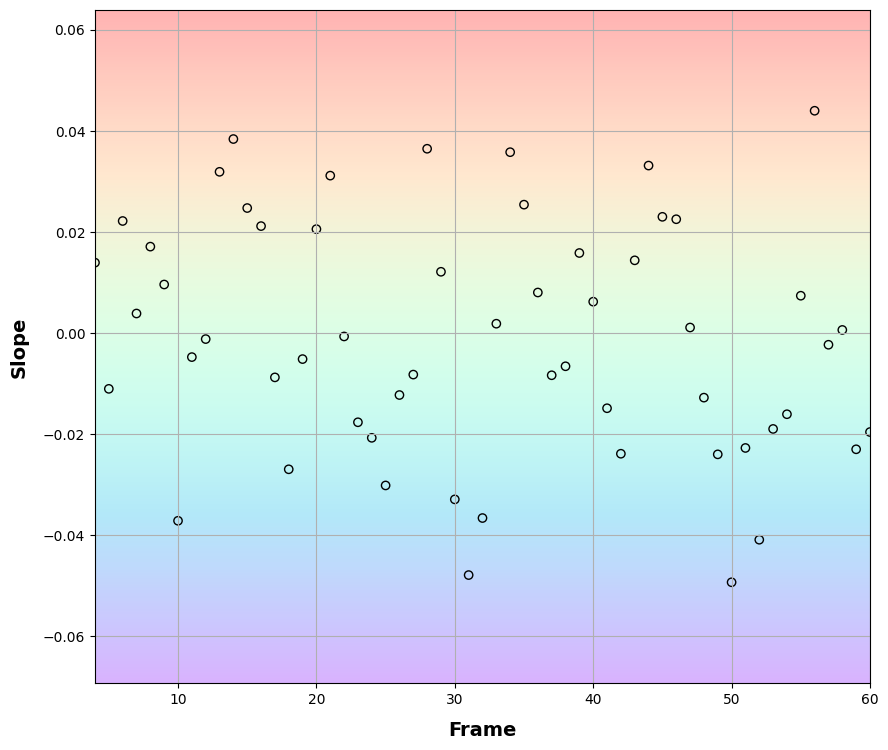

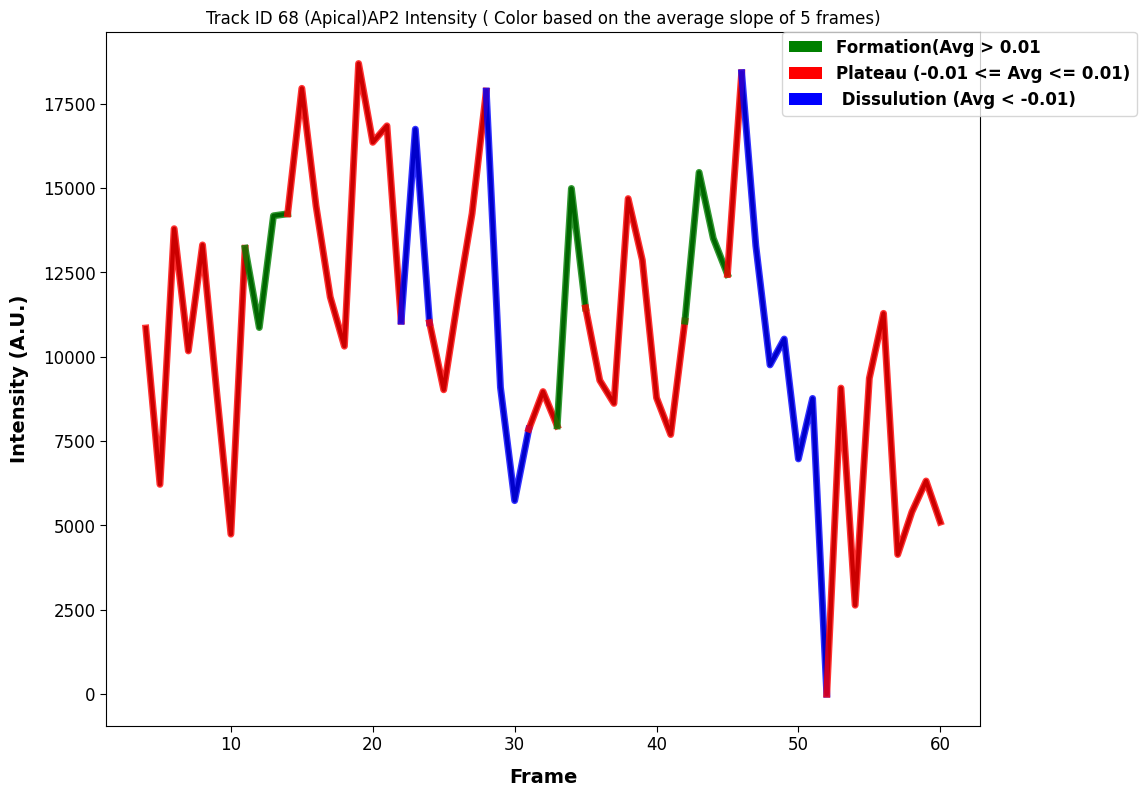

In [413]:
base_frac = 0.2
slope_apical_2, frame_apical_2 = slope_plot(track_df, 68, lumenoid2_frame_ms, 10.5)
slope_color_coded_intensity_time_plot(dataframe = track_df, tracks_to_plot = 68, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_apical_2[0], avg_size=5, frame_list=np.array(frame_apical_2), threshold = 0.01,  graph_title = '(Apical)AP2 Intensity', normalized=False, save_plot = False)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\1554819204.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


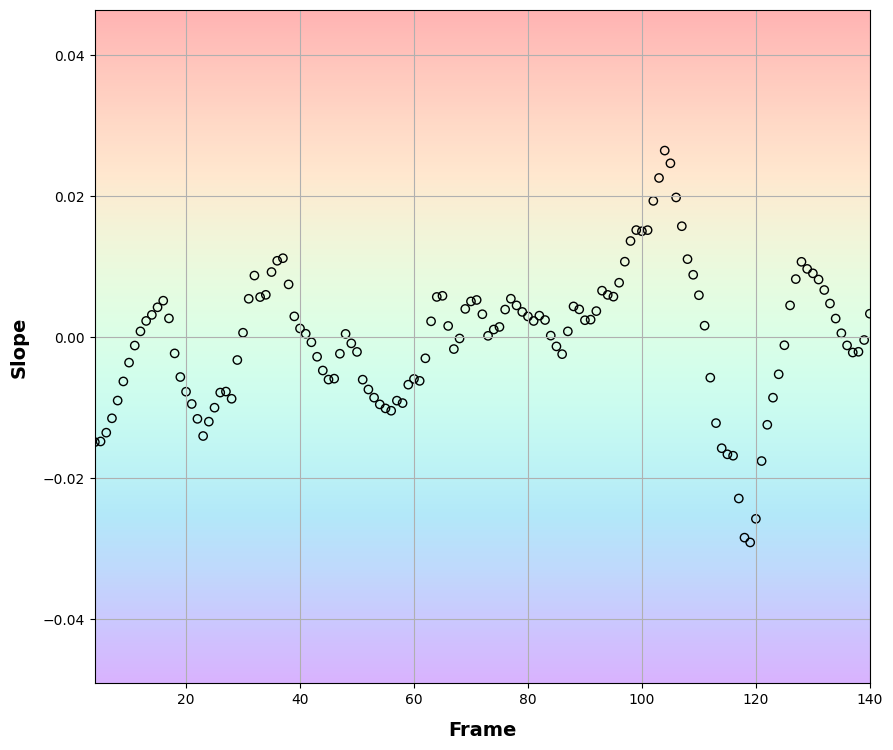

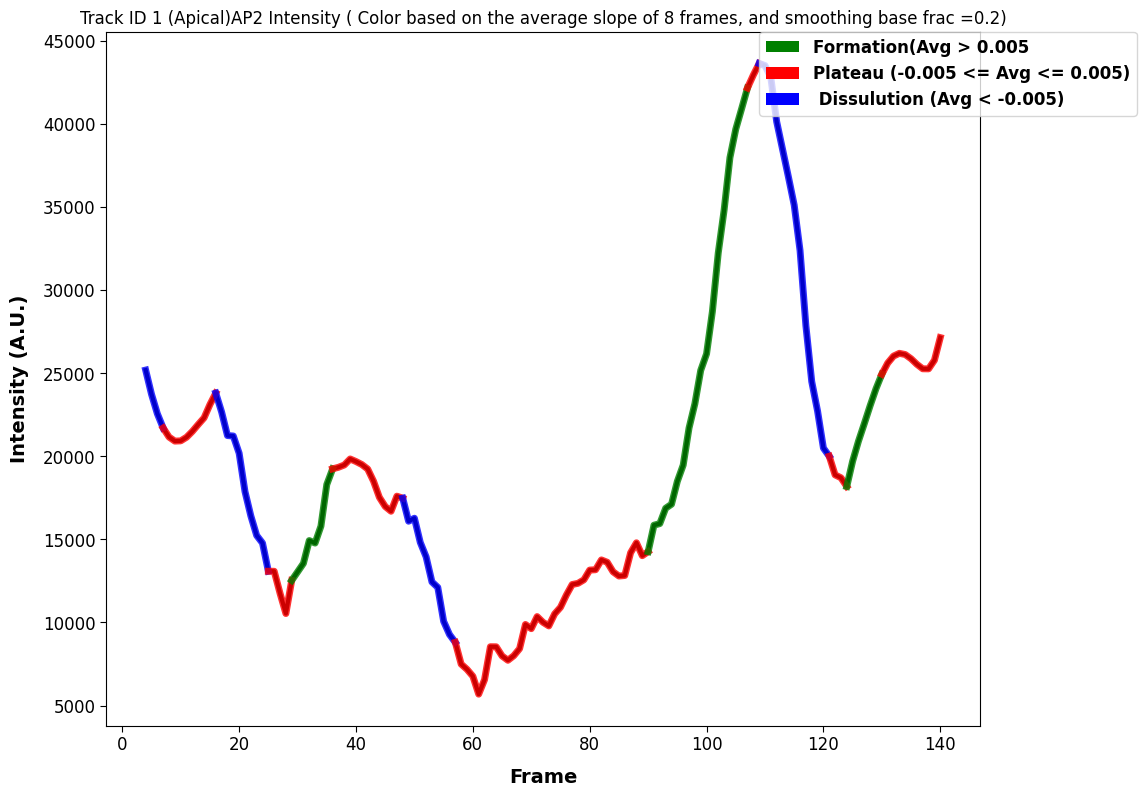

In [414]:
base_frac = 0.2
slope_apical_2, frame_apical_2 = smoothed_slope_plot(track_df, 1, lumenoid2_frame_ms, 10.5,poly=5,base_frac=base_frac)
smooth_slope_color_coded_intensity_time_plot(dataframe = track_df, tracks_to_plot = 1, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_apical_2[0], avg_size=8, frame_list=np.array(frame_apical_2), threshold = 0.005, base_frac = base_frac, graph_title = '(Apical)AP2 Intensity', normalized=False, save_plot = False)

#### Lateral Slope Testing

In [415]:
lateral_tracks_full.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,C3_adjusted_voxel_sum_peak_frame,C2_adjusted_voxel_sum_peak_frame,C1_adjusted_voxel_sum_peak_frame,max_z_movement,max_y_movement,max_x_movement,channel2_positive,channel1_positive,membrane_region,track_radius
0,31 146.0 5850 146.0 5864 147....,31 419.0 5850 419.0 5864 419....,31 83.0 5850 83.0 5864 82.0 9...,0,141,0,140,876.904255,2766.252632,1271.685714,...,42,72,54,6.0,6.0,8.0,True,True,Lateral,224.592965
1,2673 238.0 3295 238.0 7075 237....,2673 134.0 3295 135.0 7075 135....,2673 115.0 3295 115.0 7075 115....,1,141,0,140,604.114286,424.142857,1621.988571,...,111,139,11,12.0,9.0,8.0,True,True,Lateral,253.793223
4,431 328.0 3037 328.0 6639 327....,431 195.0 3037 196.0 6639 196....,431 151.0 3037 151.0 6639 152....,4,141,0,140,622.051429,1997.542857,2796.645714,...,104,132,79,7.0,15.0,8.0,True,True,Lateral,173.026010
5,590 376.0 3572 376.0 7685 376....,590 149.0 3572 149.0 7685 149....,590 181.0 3572 182.0 7685 181....,5,141,0,140,727.262857,365.491429,1472.548571,...,17,10,135,24.0,9.0,6.0,True,True,Lateral,224.120503
6,719 232.0 4003 232.0 8606 232....,719 132.0 4003 133.0 8606 133....,719 104.0 4003 105.0 8606 105....,6,136,0,135,796.931429,1158.348571,2622.422857,...,9,126,86,8.0,9.0,11.0,True,True,Lateral,257.817765


C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\41269647.py:71: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


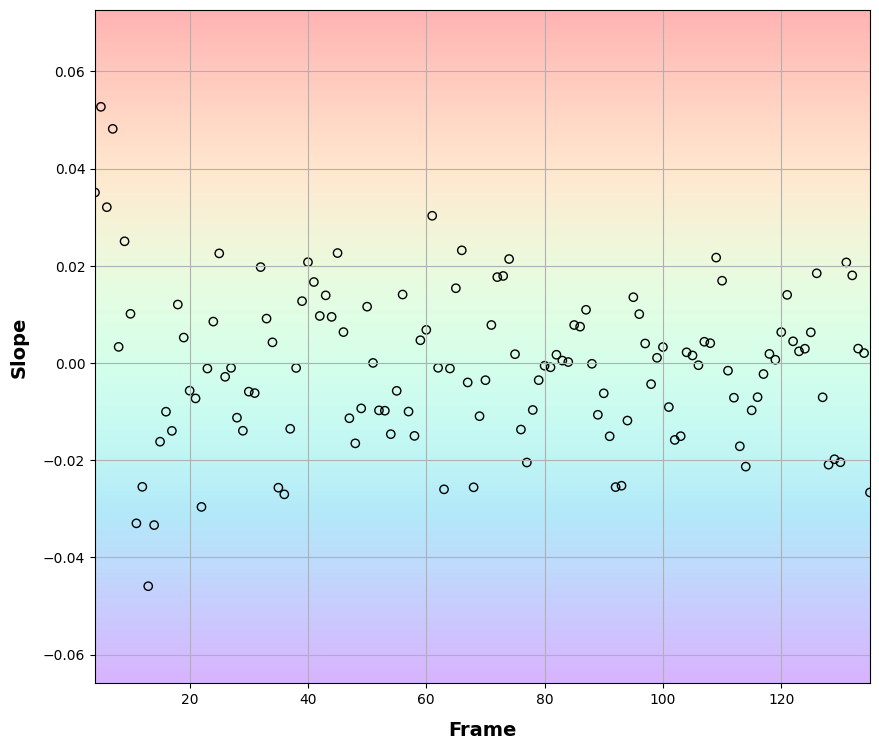

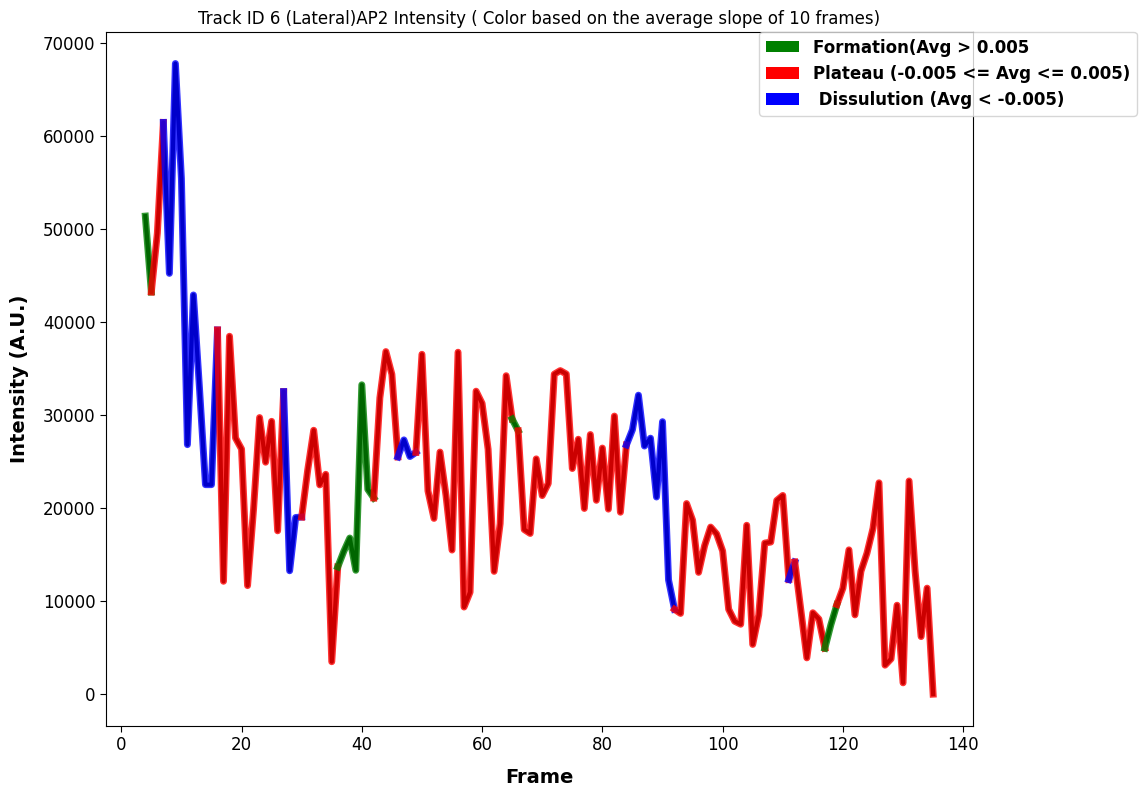

In [416]:
slope_lateral_5, frame_lateral_5 = slope_plot(track_df, 6, lumenoid2_frame_ms, 10.5)
slope_color_coded_intensity_time_plot(dataframe = track_df, tracks_to_plot = 6, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_lateral_5[0], avg_size=10, frame_list=np.array(frame_lateral_5), threshold = 0.005,  graph_title = '(Lateral)AP2 Intensity', normalized=False, save_plot = False)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\1554819204.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


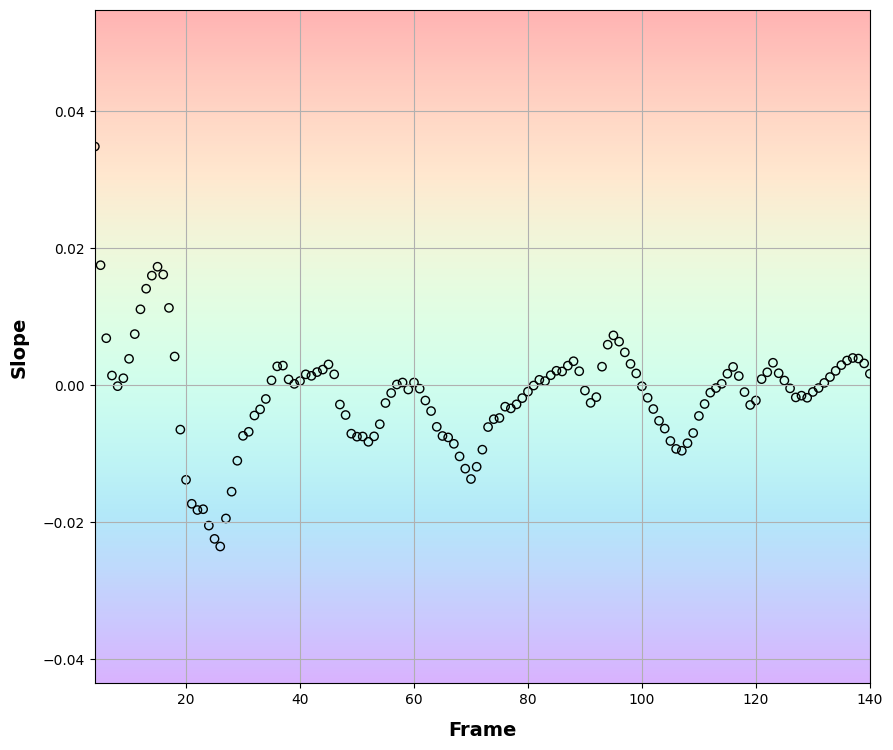

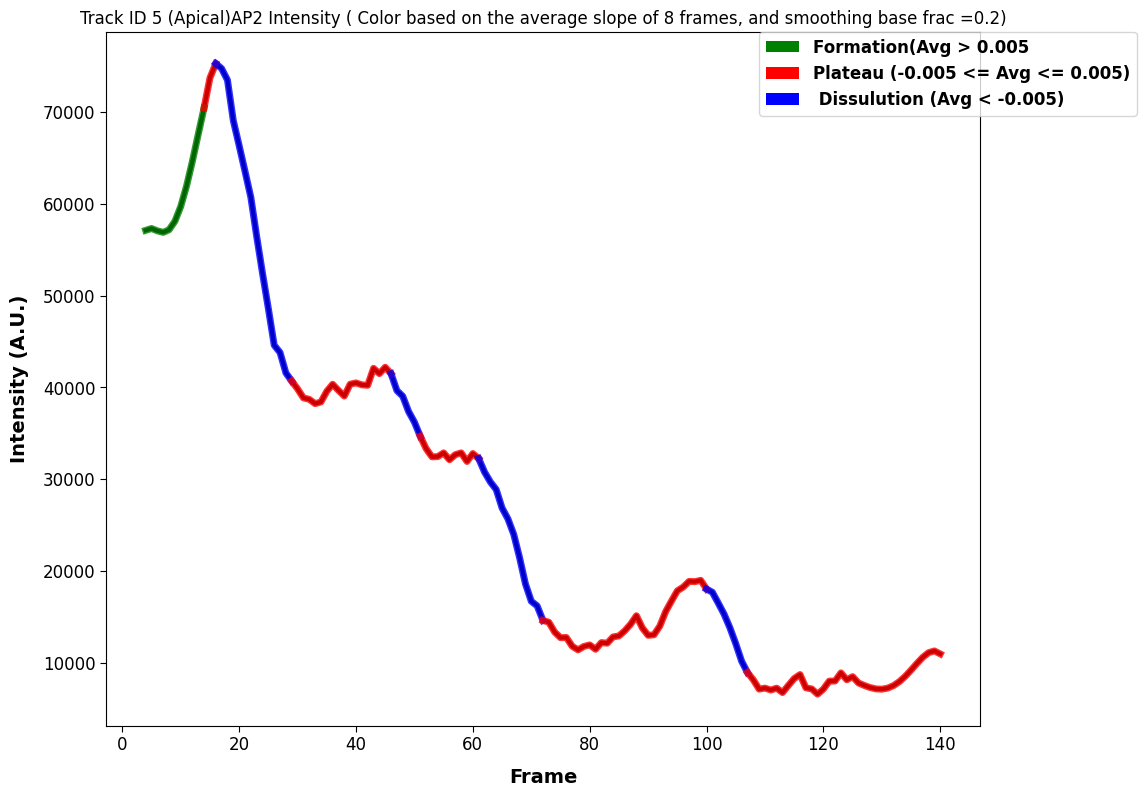

In [417]:
base_frac = 0.2
slope_lateral, frame_lateral= smoothed_slope_plot(track_df, 5, lumenoid2_frame_ms, 10.5,base_frac=base_frac)
smooth_slope_color_coded_intensity_time_plot(dataframe = track_df, tracks_to_plot = 5, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_lateral[0], avg_size=8, frame_list=np.array(frame_lateral), threshold = 0.005, base_frac = base_frac, graph_title = '(Apical)AP2 Intensity', normalized=False, save_plot = False)

#### Basal

In [418]:
basal_tracks_full.head()

,mu_x,mu_y,mu_z,track_id,track_length,track_start,track_end,c3_peak,c2_peak,c1_peak,...,C3_adjusted_voxel_sum_peak_frame,C2_adjusted_voxel_sum_peak_frame,C1_adjusted_voxel_sum_peak_frame,max_z_movement,max_y_movement,max_x_movement,channel2_positive,channel1_positive,membrane_region,track_radius
20,2395 242.0 3127 242.0 6677 241....,2395 110.0 3127 110.0 6677 109....,2395 124.0 3127 124.0 6677 125....,20,97,0,96,631.674286,598.925714,1056.417143,...,78,41,70,8.0,7.0,8.0,True,False,Basal,274.018248
45,1745 249.0 4544 248.0 8466 248....,1745 604.0 4544 604.0 8466 605....,1745 118.0 4544 118.0 8466 117....,45,73,0,72,916.760000,708.091429,1182.034286,...,17,16,8,7.0,11.0,5.0,True,True,Basal,274.082104
46,1735 203.0 4587 204.0 8362 204....,1735 132.0 4587 133.0 8362 133....,1735 82.0 4587 80.0 8362 80.0 9...,46,72,0,71,966.845714,698.434286,917.794286,...,8,0,38,18.0,4.0,13.0,False,True,Basal,273.563521
47,1701 284.0 4669 285.0 8187 285....,1701 79.0 4669 79.0 8187 80.0 9...,1701 141.0 4669 141.0 8187 141....,47,71,0,70,942.217143,1567.091429,1008.011429,...,35,35,69,9.0,6.0,9.0,True,True,Basal,290.368731
63,1421 335.0 5706 335.0 6028 334....,1421 91.0 5706 91.0 6028 91.0 1...,1421 173.0 5706 173.0 6028 174....,63,64,0,63,771.291429,1708.200000,1389.325714,...,14,18,54,9.0,4.0,9.0,True,True,Basal,276.790535


C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\41269647.py:71: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


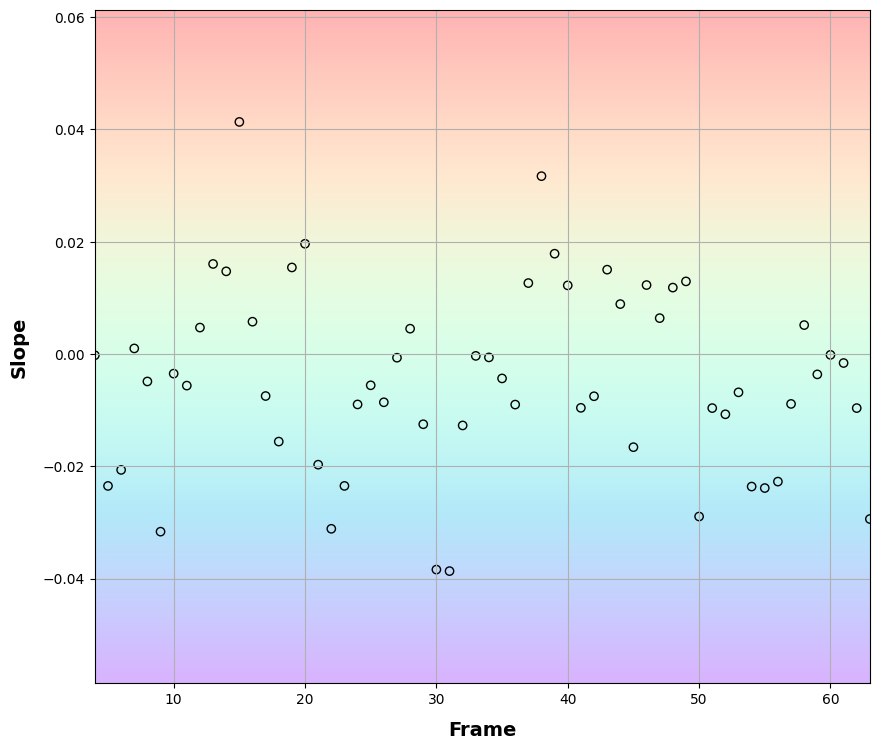

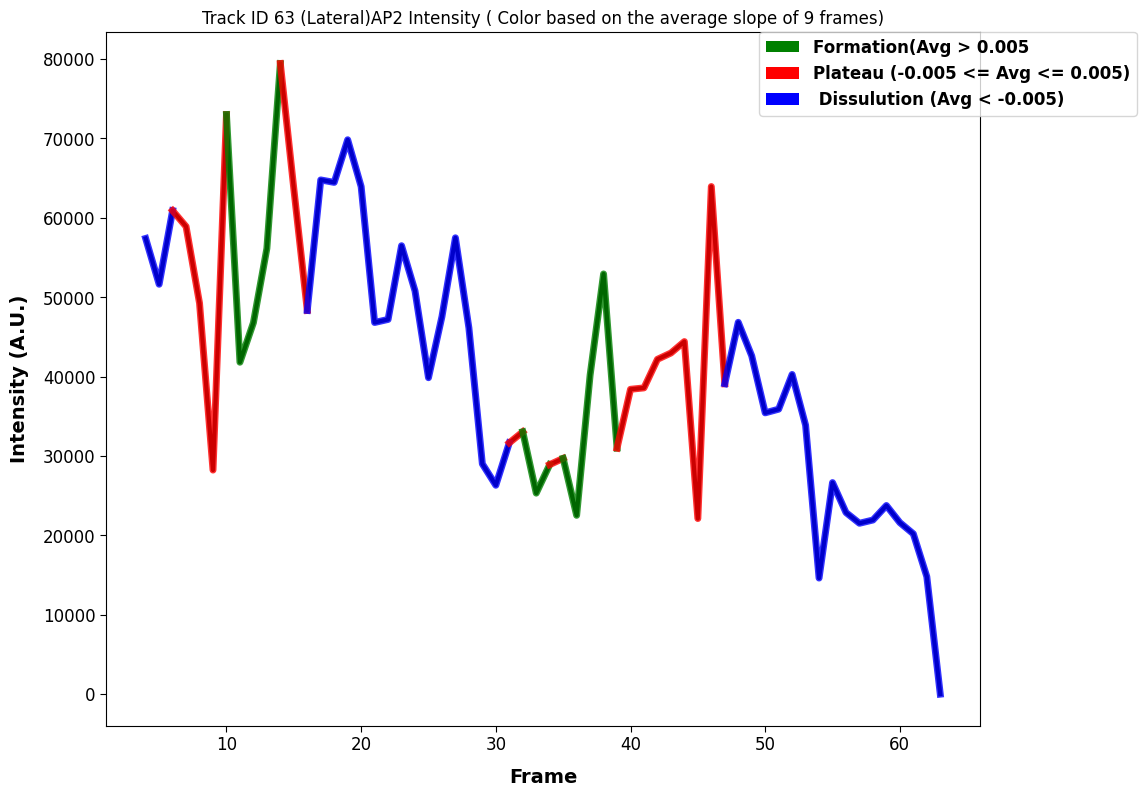

In [419]:
slope_basal, frame_basal = slope_plot(track_df, 63, lumenoid2_frame_ms, 10.5)
slope_color_coded_intensity_time_plot(dataframe = track_df, tracks_to_plot = 63, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_basal[0], avg_size=9, frame_list=np.array(frame_basal), threshold = 0.005,  graph_title = '(Lateral)AP2 Intensity', normalized=False, save_plot = False)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\1554819204.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


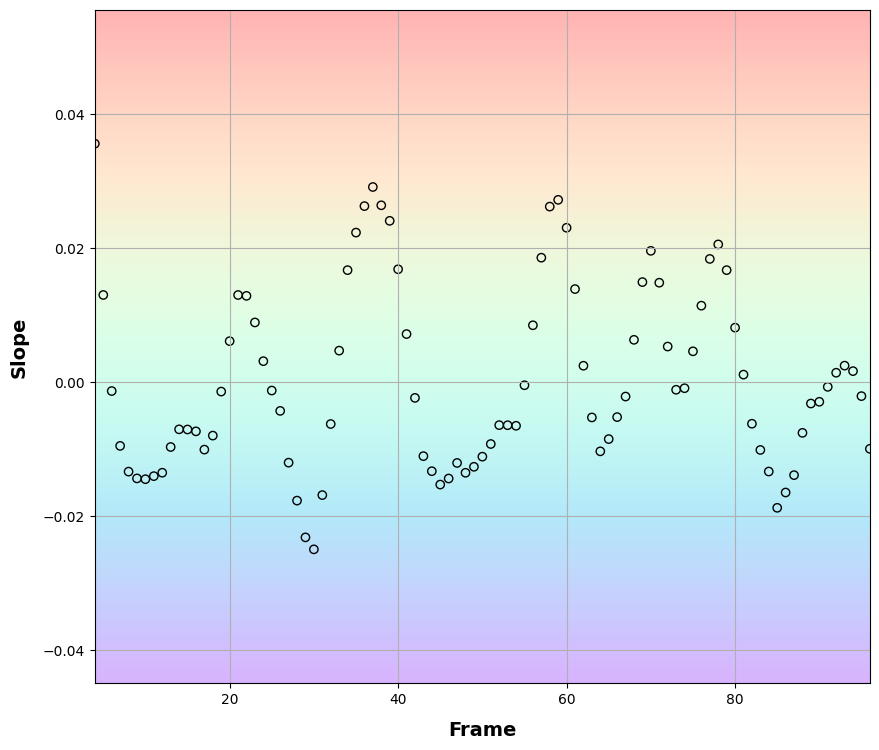

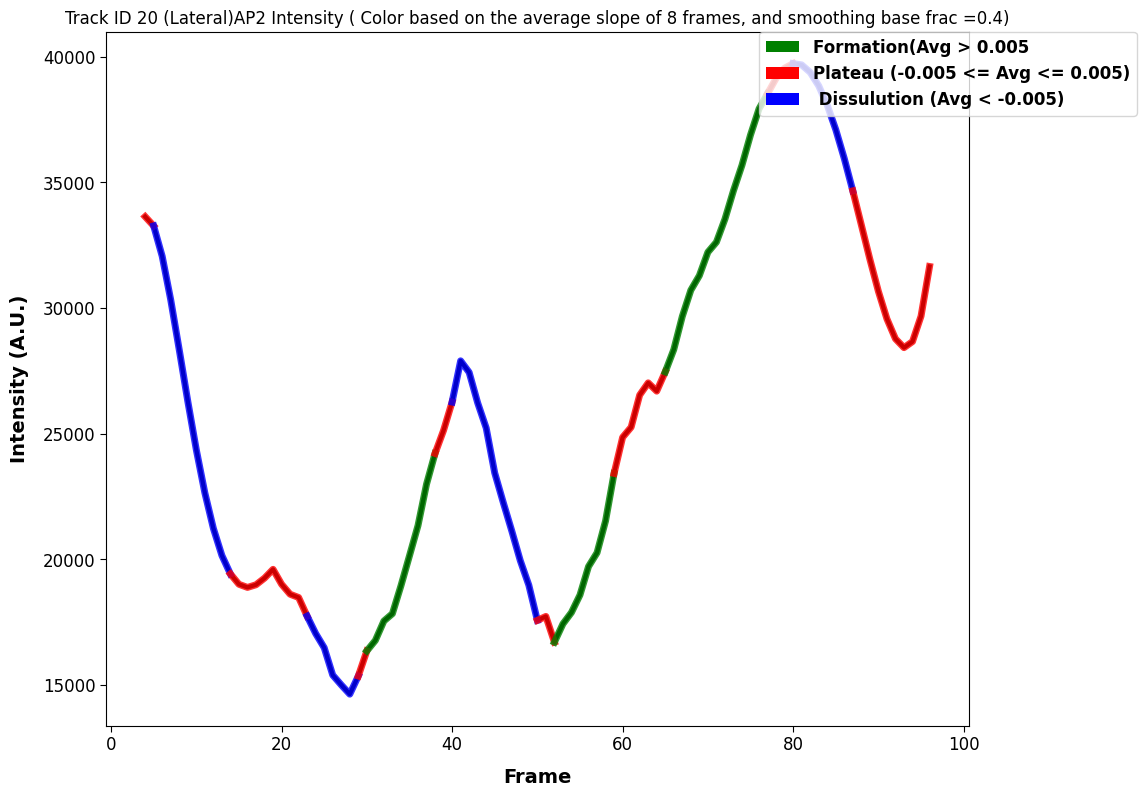

In [420]:
base_frac= 0.2
slope_basal, frame_basal = smoothed_slope_plot(track_df, 20, lumenoid2_frame_ms, 10.5,base_frac=base_frac)
smooth_slope_color_coded_intensity_time_plot(dataframe = track_df, tracks_to_plot = 20, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_basal[0], avg_size=8, frame_list=np.array(frame_basal), threshold = 0.005,  graph_title = '(Lateral)AP2 Intensity', normalized=False, save_plot = False)

## New lumenoid CCS Graphs

In [45]:
# new_lumenoid_input_file_directory = '20250717_MA3_Day3_5min_10um-05_analysis/'
# new_lumenoid_filtered_tracks = pd.read_pickle(os.path.join(base_dir, new_lumenoid_input_file_directory, 'datasets', 'region_filtered_tracks_final.pkl'))

new_lumenoid_all_tracks_full = os.path.join(base_dir, new_lumenoid_input_file_directory) + 'datasets/track_df_cleaned_final_full.pkl'
ccs_new_lumenoid_track_df = pd.read_pickle(new_lumenoid_all_tracks_full)

In [65]:
auto_slopes = auto_growth_distribution(ccs_new_lumenoid_track_df, new_lumenoid_frame_ms, time_interval=10, forwardp=0)

Processing tracks:   0%|          | 0/9411 [00:00<?, ?it/s]

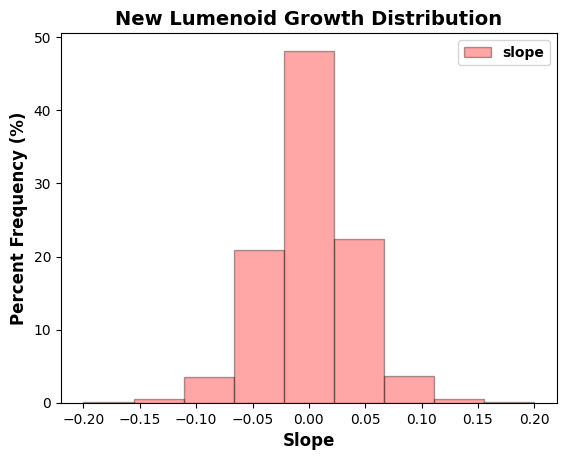

In [66]:
create_growth_dist_histogram(auto_slopes, title="New Lumenoid Growth Distribution", bins=np.linspace(-0.2,0.2,10))

Processing tracks:   0%|          | 0/87 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/445 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/245 [00:00<?, ?it/s]

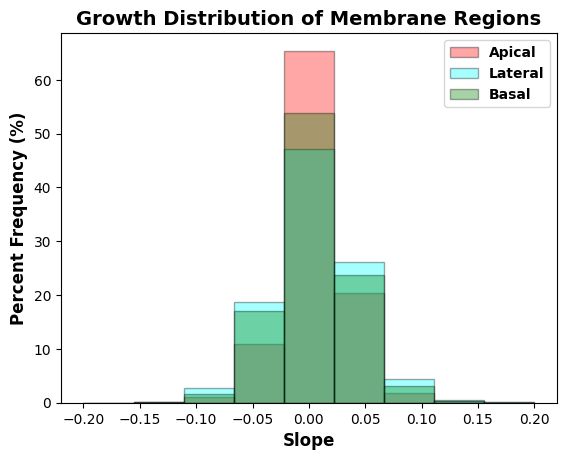

In [86]:
membrane_region_growth_distribution(new_lumenoid_filtered_tracks,ccs_new_lumenoid_track_df, new_lumenoid_frame_ms, time_interval=10, forwardp=0)

Processing tracks:   0%|          | 0/87 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/445 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/245 [00:00<?, ?it/s]

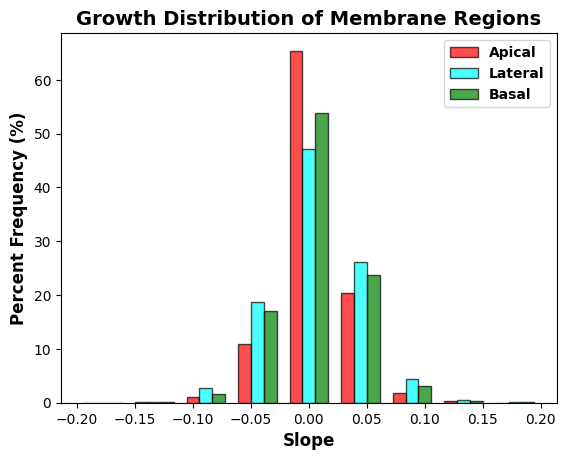

In [96]:
membrane_region_growth_distribution(new_lumenoid_filtered_tracks,ccs_new_lumenoid_track_df, new_lumenoid_frame_ms, isSmoothed=False, isSeperate=True, time_interval=10, forwardp=0)

### Smoothed Graphs

In [313]:
smoothed_auto_slopes = smoothed_auto_growth_distribution(ccs_new_lumenoid_track_df, new_lumenoid_frame_ms, time_interval=10, forwardp=0)

Processing tracks:   0%|          | 0/9411 [00:00<?, ?it/s]

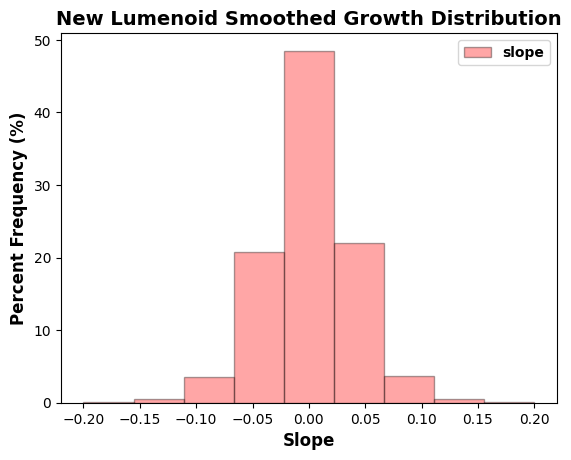

In [93]:
create_growth_dist_histogram(smoothed_auto_slopes, title="New Lumenoid Smoothed Growth Distribution", bins=np.linspace(-0.2,0.2,10))

Processing tracks:   0%|          | 0/87 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/445 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/245 [00:00<?, ?it/s]

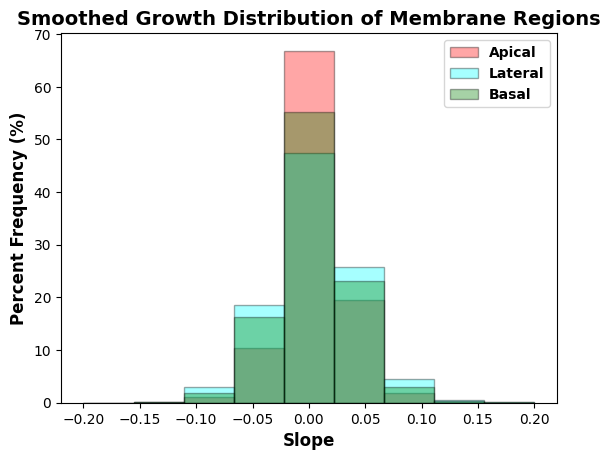

In [100]:
membrane_region_growth_distribution(new_lumenoid_filtered_tracks,ccs_new_lumenoid_track_df, new_lumenoid_frame_ms, isSmoothed=True, isSeperate=False, time_interval=10, forwardp=0)

Processing tracks:   0%|          | 0/87 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/445 [00:00<?, ?it/s]

Processing tracks:   0%|          | 0/245 [00:00<?, ?it/s]

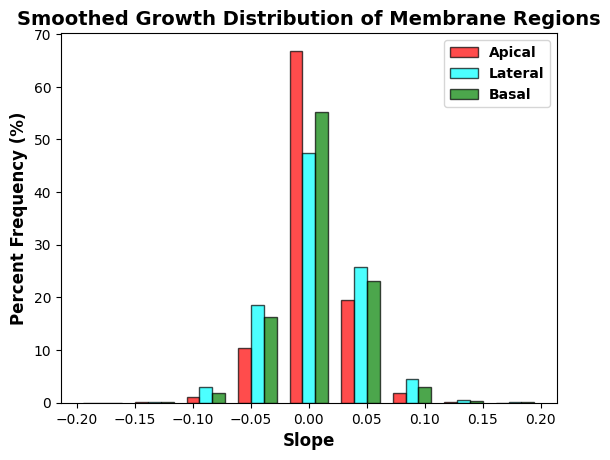

In [97]:
membrane_region_growth_distribution(new_lumenoid_filtered_tracks,ccs_new_lumenoid_track_df, new_lumenoid_frame_ms, isSmoothed=True, isSeperate=True, time_interval=10, forwardp=0)

### Slope Graphs

In [314]:
apical_tracks_full = trackFilter("Apical","False", filtered_tracks_treatment)
lateral_tracks_full = trackFilter("Lateral","False", filtered_tracks_treatment)
basal_tracks_full = trackFilter("Basal","False", filtered_tracks_treatment)

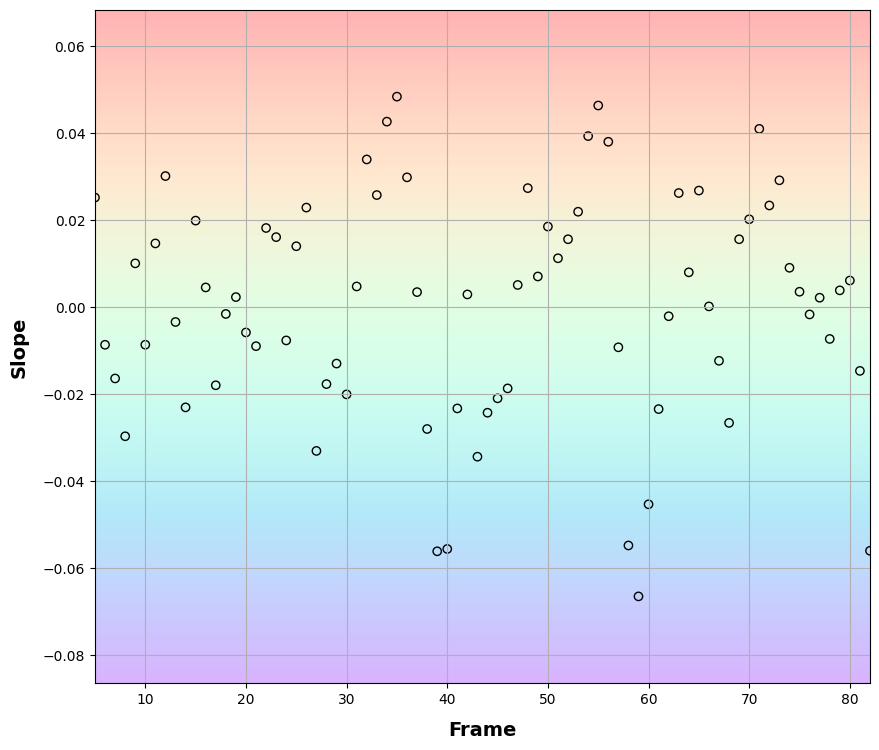

In [423]:
slope_zero, slope_to_frame = slope_plot(ccs_new_lumenoid_track_df, 0, new_lumenoid_frame_ms, 10)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\41269647.py:71: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


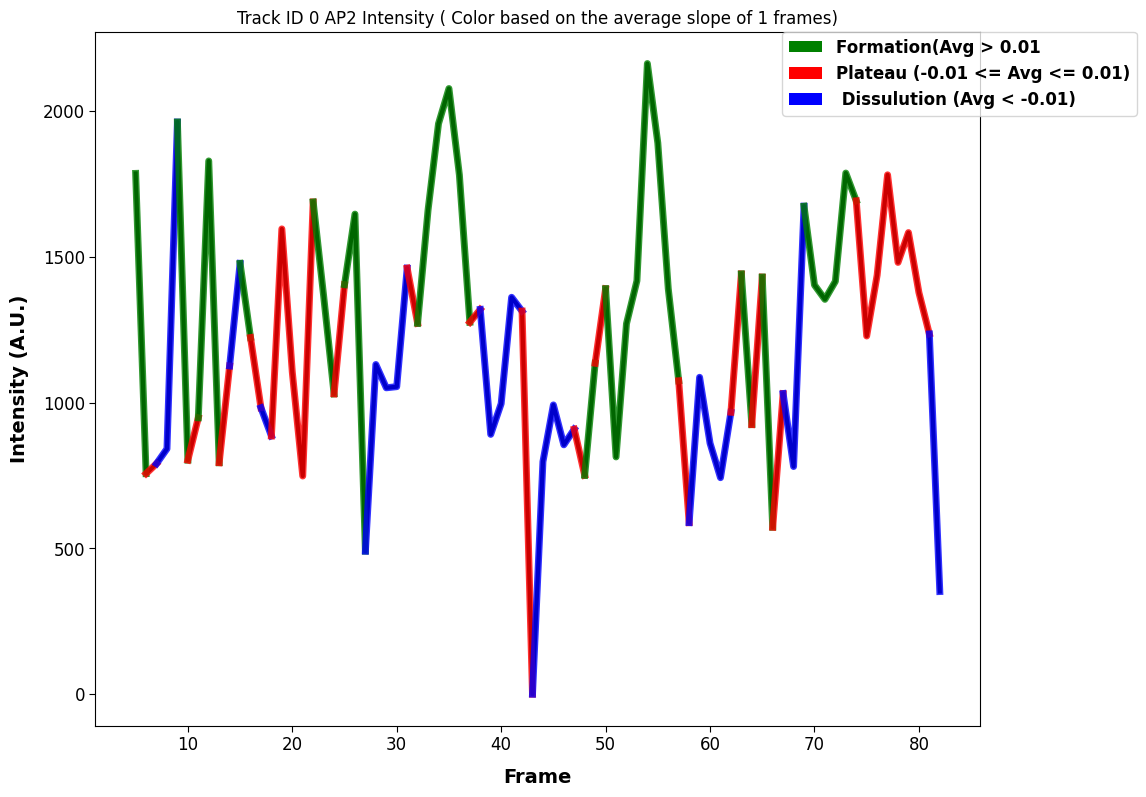

In [424]:
slope_color_coded_intensity_time_plot(dataframe = ccs_new_lumenoid_track_df, tracks_to_plot = 0, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_zero[0], avg_size=1, frame_list=np.array(slope_to_frame), threshold = 0.01,  graph_title = 'AP2 Intensity', normalized=False, save_plot = False)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\1554819204.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


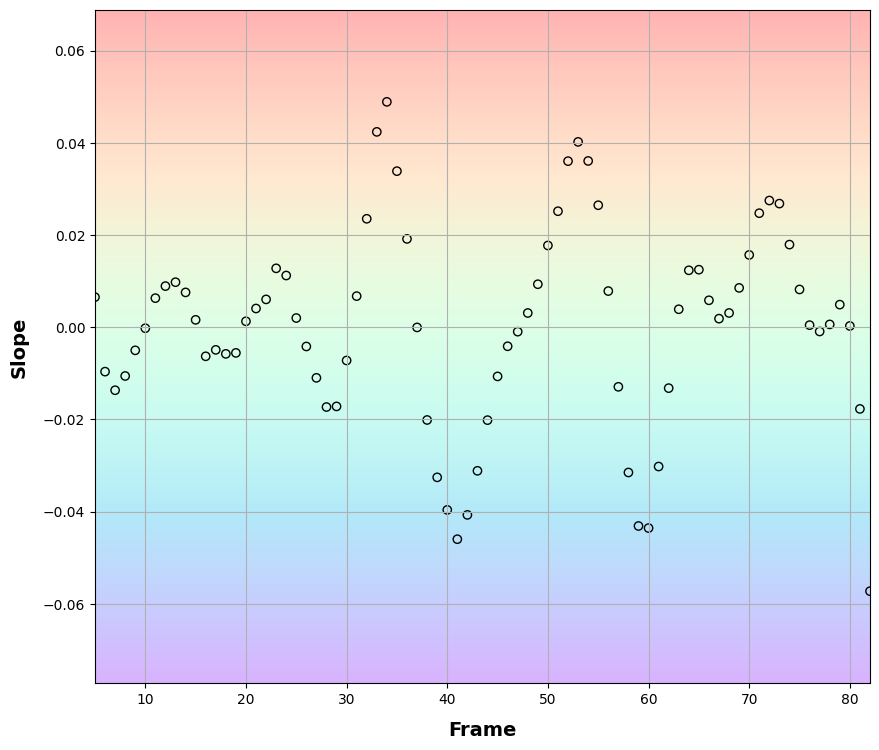

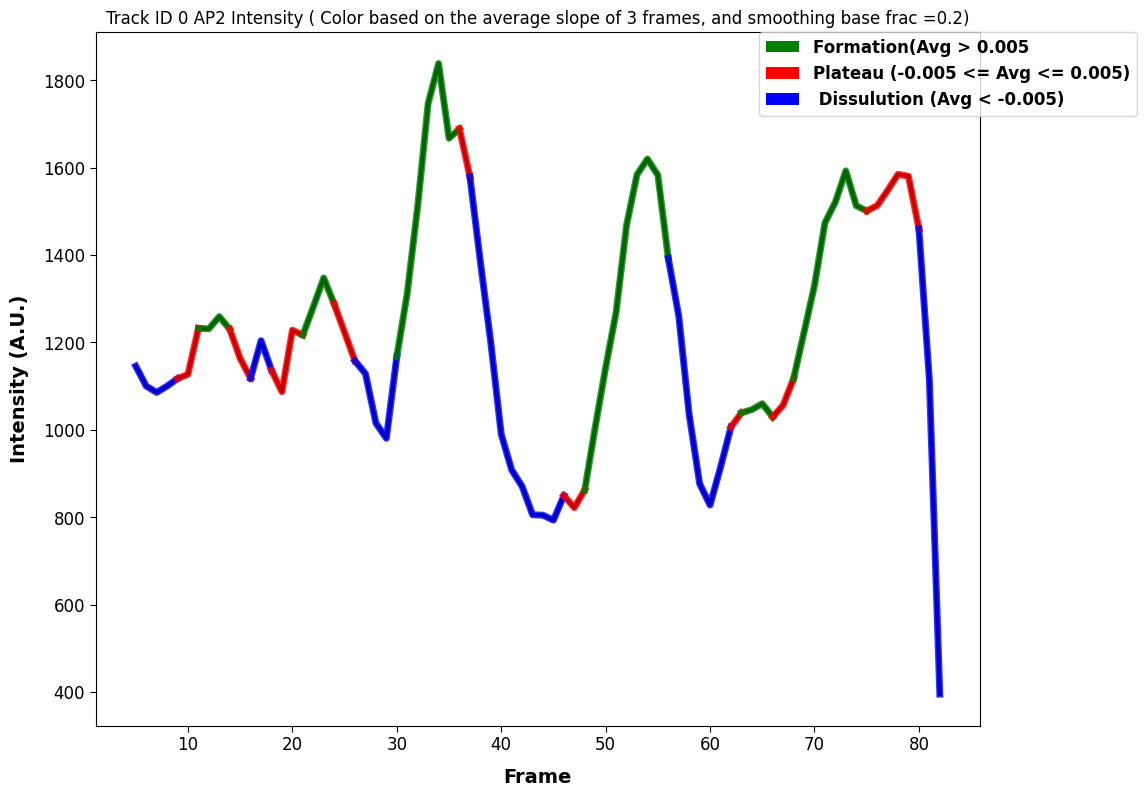

In [437]:
base_frac = 0.2
slope_apical_2, frame_apical_2 = smoothed_slope_plot(ccs_new_lumenoid_track_df, 0, new_lumenoid_frame_ms,poly=5, time_interval=10, base_frac=base_frac)
smooth_slope_color_coded_intensity_time_plot(dataframe = ccs_new_lumenoid_track_df, tracks_to_plot = 0, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_apical_2[0], avg_size=3, frame_list=np.array(frame_apical_2), threshold = 0.005, base_frac = base_frac, graph_title = 'AP2 Intensity', normalized=False, save_plot = False)

## Testing New Plot Filtering

In [41]:
def sliding_window_values(arr, window_size):
    # Create sliding windows of shape (n_windows, window_size)
    windows = np.lib.stride_tricks.sliding_window_view(arr, window_size)
    # Take the mean of each window
    return windows.tolist()

In [239]:
#len(slope_zero[0])
slopes = sliding_window_values(np.array(slope_zero[0]), 3)
top_n_values = np.sort(np.array(slope_zero[0]))
max_threshold = min(top_n_values[-3:]) 
testing = [0,2,3]
if any(testing > np.array(0.05)):
    print("True")
else:
    print("false")

True


In [43]:
def smooth_phases_intensity_time_plot(dataframe: pd.DataFrame, tracks_to_plot: np.ndarray, slope_list, 
                                        frame_list, window_size, num_peaks, poly: int = 5, base_frac: float = 0.4,
                                        line_colors: str = 'black', graph_title = 'AP2 Intensity', normalized: bool = False, save_plot: bool = False):
    
    '''
    
    The function takes in a track to plot the AP2 intensity and highlights the
    formation, plateau and dissulution stages baed on the given avg_size and threshold to classify the stages

    
    Parameters:
    1. dataframe: type(DataFrame), this is the raw dataframe which contains all of the relevant intensity values
    2. tracks_to_plot: type(list), contains the tracks id's of tracks within the specified length range
    3. slope_list: type(list), The slopes via slope_plot function
    4. avg_size: type(int), The number of frames used to average the slope to determine the stages
    5. threshold: type(float), the float representing the threshold to classify the stages based on the average slope
    6. track_id_col_name: type(str), the column name which contains the track id's number. Default value: 'track_id'
    7. frame_col_name: type(string), the column name which contains the track's frame data. Default value: 'frame'
    8. line_colors: type(string), the string that determine the base color of the AP2 intensity
    9. graoh_title: tyoe(string), the string that titles the graph. Default value: 'AP2 Intensity'
    10. normalized: type(bool), if the intensity values are normalized. Default value: False
    11. save_plot: type(bool), a toggle if you want to download the graph.

    Output: 
    Returns an AP2 intensity graph that has been color coded to classify formation, plateau, and dissulution stages for a track.
    
    '''
    # change frame_list to track_data[frame_column] for original
    num_rows = 1
    num_cols = 1
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 8.75))

    # Filter DataFrame for the selected track_id
    track_data = dataframe[dataframe['track_id'] == tracks_to_plot].copy(deep = True)
    

    lines = []
    #for i in range(channels_to_plot):
    min_val = track_data['c3_voxel_sum_adjusted'].min()
    track_data['c3_voxel_sum_adjusted'] -= min_val
    max_val = track_data['c3_voxel_sum_adjusted'].max()          

    # normalize by max_intensity
    if normalized:  
        track_data['c3_voxel_sum_adjusted'] /= max_val
    smoothed_intensity = savgol_smooth_length_scaled(track_data['c3_voxel_sum_adjusted'].tolist(),poly=poly,base_frac=base_frac)
    
    # figure out the values we need to remove in the itensity list 
    mask_keep = np.isin(track_data['frame'], frame_list)
    smoothed_intensity = np.array(smoothed_intensity)[mask_keep]
    axes.plot(frame_list, smoothed_intensity, label='c3_voxel_sum_adjusted', color=line_colors, linewidth = 3)
    # print(track_data[intensity_to_plot[i]])
    #lines.append(line)
    #threshold = 0.1
    sorted_slopes = np.sort(np.array(slope_list))
    max_threshold = min(sorted_slopes[-num_peaks*2:])
    min_threshold = max(sorted_slopes[:num_peaks*2])
    # tuple labels = (start_idx, end_idx, color)

    slopes = sliding_window_values(np.array(slope_list), window_size)
    # Color assignments (spanning windows)
    colors = np.empty(len(frame_list), dtype=object)
    for i, test_slope in enumerate(slopes):
        # Decide color based on slope at center
        start_idx = max(0, i)              # window start
        end_idx = min(len(frame_list), i + window_size)  # window end (exclusive)
        if any(test_slope >= max_threshold):
            #if not red_line and not blue_line:
                c = "green"

        elif any(test_slope <= min_threshold):
            #if red_line and green_line:
                c = "blue"

        elif any((test_slope < np.array(0.05))) and any(test_slope > np.array(-0.05)) :
            #if green_line and not blue_line:
                c = "red"
        
        # if green_line and red_line and blue_line:
        #     axes.plot(frame_list[green_line[0]:green_line[1]], smoothed_intensity[green_line[0]:green_line[1]],
        #               color=green_line[2], linewidth=5, alpha=0.8)
        #     axes.plot(frame_list[red_line[0]:red_line[1]], smoothed_intensity[red_line[0]:red_line[1]],
        #               color=red_line[2], linewidth=5, alpha=0.8)
        #     axes.plot(frame_list[blue_line[0]:blue_line[1]], smoothed_intensity[blue_line[0]:blue_line[1]],
        #               color=blue_line[2], linewidth=5, alpha=0.8)
        #     green_line = () 
        #     red_line = ()
        #     blue_line = ()
        # Span full window frames
        start_idx = max(0, i)              # window start
        end_idx = min(len(frame_list), i + window_size)  # window end (exclusive)
        colors[start_idx:end_idx] = c

    # Fill any NaN edges with nearest color
    colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()
    blue_index = 0
    red_index = 0
    # Plotting Colors
    start_idx = 0
    for i in range(1, len(colors)):
        if colors[i] != colors[i-1]:
            if colors[i-1] == "green" and colors[i] == "red":
                axes.plot(frame_list[start_idx:i+1], smoothed_intensity[start_idx:i+1],
                          color=colors[i-1], linewidth=5, alpha=0.8)
                red_index = i
            elif colors[i-1] == "red" and colors[i] == "blue" and start_idx == red_index:
                axes.plot(frame_list[start_idx:i+1], smoothed_intensity[start_idx:i+1],
                          color=colors[i-1], linewidth=5, alpha=0.8)
                blue_index = i
            elif colors[i-1] == "blue" and start_idx == blue_index:
                axes.plot(frame_list[start_idx:i+1], smoothed_intensity[start_idx:i+1],
                          color=colors[i-1], linewidth=5, alpha=0.8)
            #axes.plot(frame_list[start_idx:i+1], smoothed_intensity[start_idx:i+1],
                     # color=colors[i-1], linewidth=5, alpha=0.8)
            start_idx = i
    #axes.plot(frame_list[start_idx:], smoothed_intensity[start_idx:], 
             # color=colors[-1], linewidth=5, alpha=0.8)

    # for i, avg in enumerate(avg_slopes):
    #     if avg > threshold:
    #         color = "green"
    #     elif avg < -threshold:
    #         color = 'blue'
    #     else:
    #         color = 'red'
    #     mask = (frame_list >= frame_list[i]) & (frame_list <= frame_list[i + avg_size - 1])
    #     #print(track_data[frame_col_name])
    #     axes.plot(frame_list[mask], smoothed_intensity[mask], color=color, linewidth=5, alpha=0.8)
        #print("Done")
    # axes.set_title(f'Track {tracks_to_plot}, length {length}')
    axes.set_xlabel('Frame', fontweight = 'bold', labelpad = 10, fontsize = 14)
    axes.set_ylabel('Intensity (A.U.)', fontweight = 'bold', labelpad = 10, fontsize = 14)
    #axes[row, col].legend()
    axes.tick_params(axis='x', reset=True, direction='out', 
                 color='black', length=4, labelsize=12)
    axes.tick_params(axis='x', which='both', top=False)
    axes.tick_params(axis='y', reset=True, direction='out', 
                    color='black', length=4, labelsize=12)
    axes.tick_params(axis='y', which='both', right=False)

    axes.grid(False)


    # for i in range(channels_to_plot):
    #     handles.append(lines[i])
    #     labels.append(legend_values[i])
        
    legend_elements = [
        Patch(facecolor='green', label=f'Formation'),
        Patch(facecolor='red', label=f'Plateau'),
        Patch(facecolor='blue', label=f' Dissulution')
    ]
    # Set a single legend for all subplots
    legend = fig.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon= True,  bbox_to_anchor=(1.15, 0.89))
    for text in legend.get_texts():
        text.set_fontweight('bold')
    # Adjust layout for better spacing
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, hspace=0.5)
    plt.title(f'Track ID {tracks_to_plot} {graph_title} ( Color based on a window size of {window_size} frames, and smoothing base frac ={base_frac})')

    # save_plot = False  # Set this to True if you want to save the plot
    if save_plot:
        filename = f'intensity_plot_track_{tracks_to_plot}.png'
        plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"Plot saved as {filename}")
    #fig.suptitle(f'Intensity over time \n Channel 3 color: red \n Channel 2 color: green \n Channel 1 color: blue', fontsize=18, fontweight='bold')
    #plt.subplots_adjust(top=0.90)
    plt.show()

C:\Users\Kenny\AppData\Local\Temp\ipykernel_18544\1276888105.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


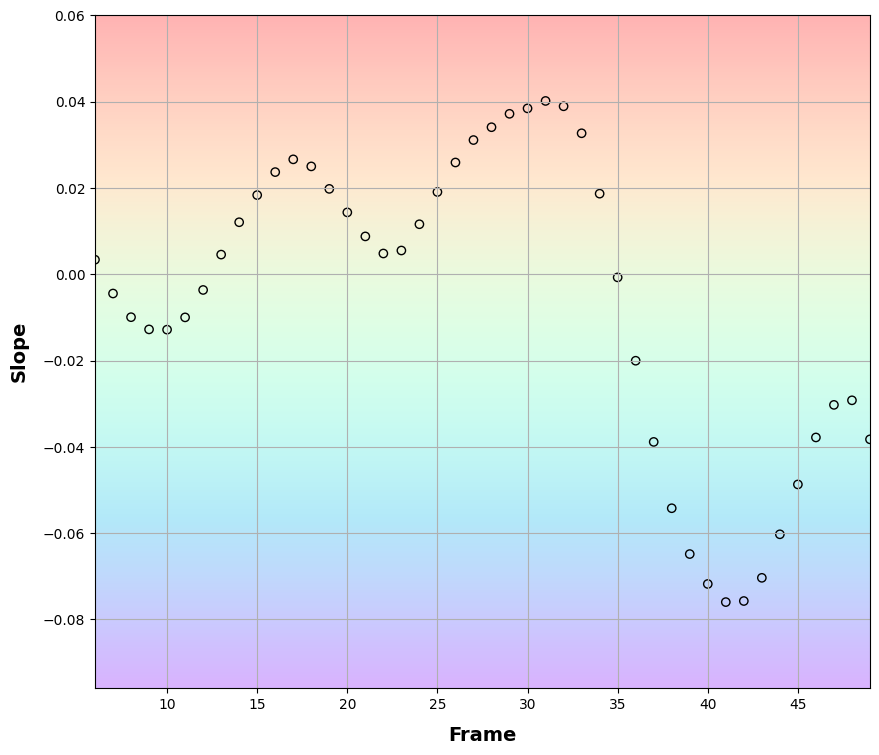

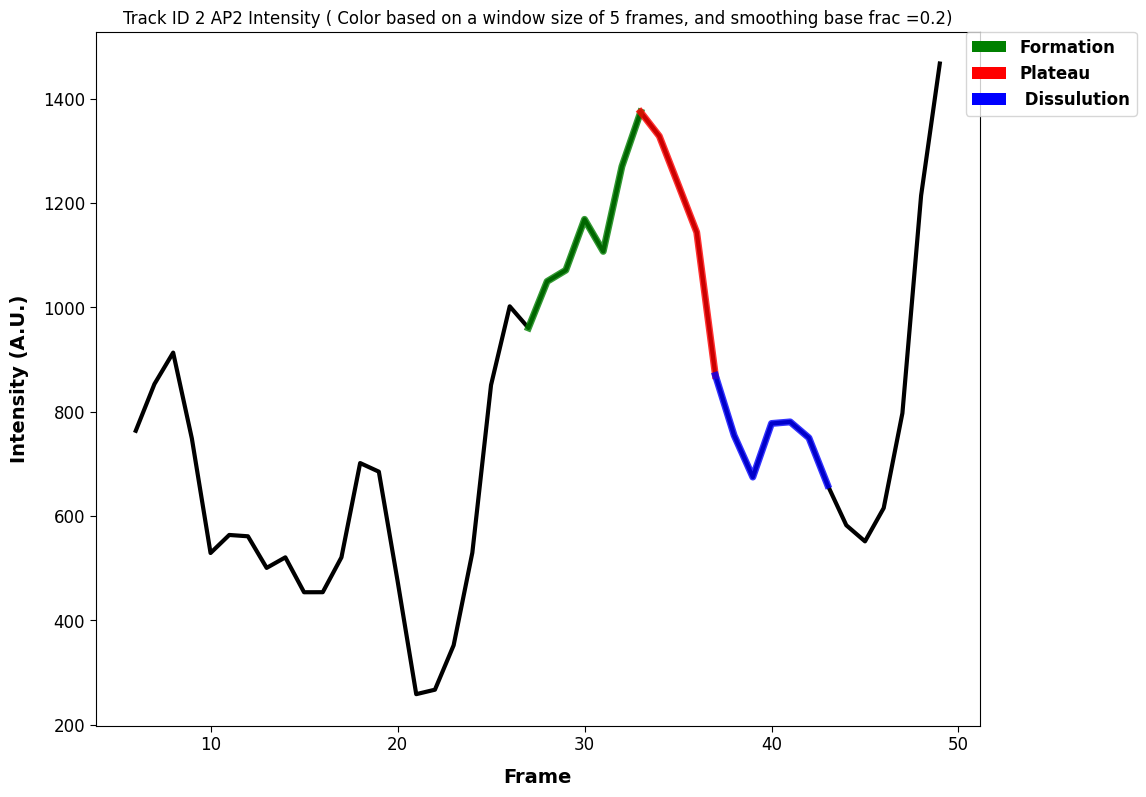

In [46]:
base_frac = 0.2
slope_zero, slope_to_frame = smoothed_slope_plot(ccs_new_lumenoid_track_df, 5869, new_lumenoid_frame_ms, 10.5)
frame_list = ccs_new_lumenoid_track_df[ccs_new_lumenoid_track_df['track_id'] == 5869]['frame'][slope_to_frame[0]:slope_to_frame[-1]]
smooth_phases_intensity_time_plot(dataframe = ccs_new_lumenoid_track_df, tracks_to_plot = 2, num_peaks=1,
slope_list = slope_zero[0], window_size=5, frame_list=np.array(slope_to_frame), base_frac = base_frac, graph_title = 'AP2 Intensity', normalized=False, save_plot = False)

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\1276888105.py:95: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


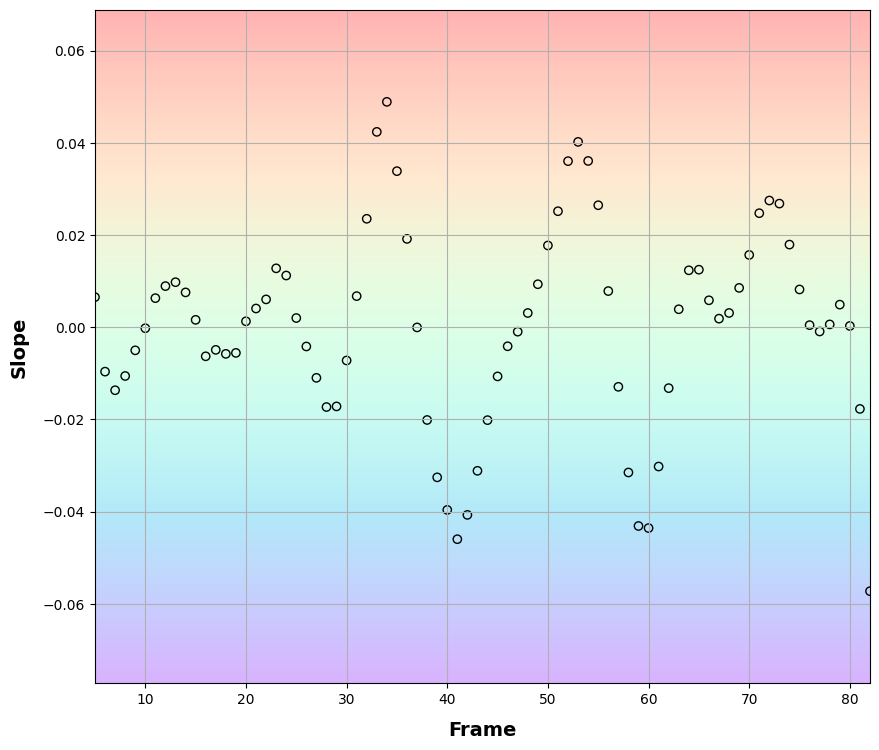

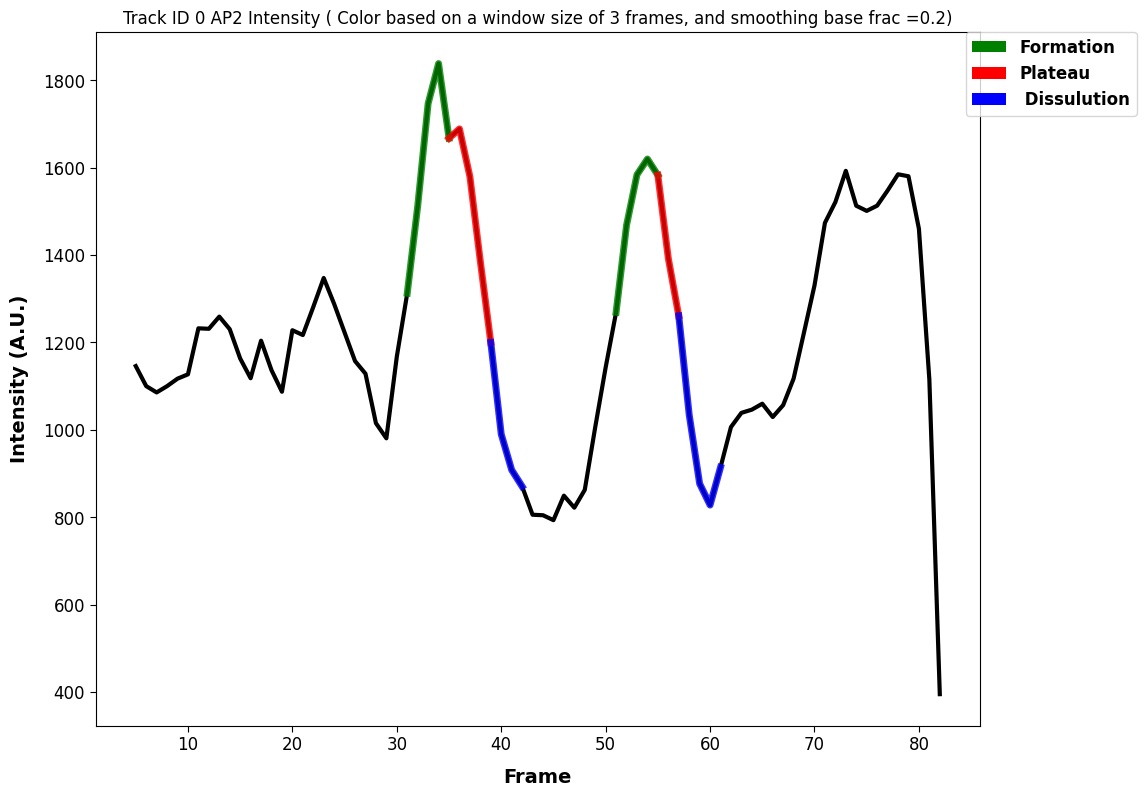

In [479]:
base_frac = 0.2
slope_apical_2, frame_apical_2 = smoothed_slope_plot(ccs_new_lumenoid_track_df, 0, new_lumenoid_frame_ms,poly=5, time_interval=10, base_frac=base_frac)
frame_list = ccs_new_lumenoid_track_df[ccs_new_lumenoid_track_df['track_id'] == 1396]['frame'][5:16]
smooth_phases_intensity_time_plot(dataframe = ccs_new_lumenoid_track_df, tracks_to_plot = 0, num_peaks=2,
slope_list = slope_apical_2[0], window_size=3, frame_list=np.array(frame_apical_2), base_frac = base_frac, graph_title = 'AP2 Intensity', normalized=False, save_plot = False)

In [137]:

def test_smooth_slope_color_coded_intensity_time_plot(dataframe: pd.DataFrame, tracks_to_plot: np.ndarray, slope_list, 
                                        avg_size, frame_list, threshold, poly: int = 5, base_frac: float = 0.4, track_id_col_name: str = 'track_id', 
                                        frame_col_name: str = 'frame', line_colors: str = 'black', 
                                        graph_title = 'AP2 Intensity', normalized: bool = False, save_plot: bool = False):
    
    '''
    
    The function takes in a track to plot the AP2 intensity and highlights the
    formation, plateau and dissulution stages baed on the given avg_size and threshold to classify the stages

    
    Parameters:
    1. dataframe: type(DataFrame), this is the raw dataframe which contains all of the relevant intensity values
    2. tracks_to_plot: type(list), contains the tracks id's of tracks within the specified length range
    3. slope_list: type(list), The slopes via slope_plot function
    4. avg_size: type(int), The number of frames used to average the slope to determine the stages
    5. threshold: type(float), the float representing the threshold to classify the stages based on the average slope
    6. track_id_col_name: type(str), the column name which contains the track id's number. Default value: 'track_id'
    7. frame_col_name: type(string), the column name which contains the track's frame data. Default value: 'frame'
    8. line_colors: type(string), the string that determine the base color of the AP2 intensity
    9. graoh_title: tyoe(string), the string that titles the graph. Default value: 'AP2 Intensity'
    10. normalized: type(bool), if the intensity values are normalized. Default value: False
    11. save_plot: type(bool), a toggle if you want to download the graph.

    Output: 
    Returns an AP2 intensity graph that has been color coded to classify formation, plateau, and dissulution stages for a track.
    
    '''
    # change frame_list to track_data[frame_column] for original
    num_rows = 1
    num_cols = 1
    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(10, 8.75))

    # Filter DataFrame for the selected track_id
    track_data = dataframe[dataframe[track_id_col_name] == tracks_to_plot].copy(deep = True)
    

    lines = []
    #for i in range(channels_to_plot):
    min_val = track_data['c3_voxel_sum_adjusted'].min()
    track_data['c3_voxel_sum_adjusted'] -= min_val
    max_val = track_data['c3_voxel_sum_adjusted'].max()          

    # normalize by max_intensity
    if normalized:  
        track_data['c3_voxel_sum_adjusted'] /= max_val
    smoothed_intensity = savgol_smooth_length_scaled(track_data['c3_voxel_sum_adjusted'].tolist(),poly=poly,base_frac=base_frac)

    # figure out the values we need to remove in the itensity list 
    mask_keep = np.isin(track_data[frame_col_name], frame_list)
    smoothed_intensity = np.array(smoothed_intensity)[mask_keep]
    axes.plot(frame_list, smoothed_intensity, label='c3_voxel_sum_adjusted', color=line_colors, linewidth = 3)
    # print(track_data[intensity_to_plot[i]])
    #lines.append(line)
    #threshold = 0.1
    
    avg_slopes = sliding_window_avg(np.array(slope_list), avg_size)
    # Color assignments (spanning windows)
    colors = np.empty(len(frame_list), dtype=object)
    for i, avg in enumerate(avg_slopes):
        # Decide color based on slope at center
        if avg > threshold:
            c = "green"
        elif avg < -threshold:
            c = "blue"
        else:
            c = "red"

        # Span full window frames
        start_idx = max(0, i)              # window start
        end_idx = min(len(frame_list), i + avg_size)  # window end (exclusive)
        colors[start_idx:end_idx] = c

    # Fill any NaN edges with nearest color
    colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()

    # Plotting Colors
    start_idx = 0
    for i in range(1, len(colors)):
        if colors[i] != colors[i-1]:
            axes.plot(frame_list[start_idx:i+1], smoothed_intensity[start_idx:i+1],
                      color=colors[i-1], linewidth=5, alpha=0.8)
            start_idx = i
    axes.plot(frame_list[start_idx:], smoothed_intensity[start_idx:], 
              color=colors[-1], linewidth=5, alpha=0.8)

    # for i, avg in enumerate(avg_slopes):
    #     if avg > threshold:
    #         color = "green"
    #     elif avg < -threshold:
    #         color = 'blue'
    #     else:
    #         color = 'red'
    #     mask = (frame_list >= frame_list[i]) & (frame_list <= frame_list[i + avg_size - 1])
    #     #print(track_data[frame_col_name])
    #     axes.plot(frame_list[mask], smoothed_intensity[mask], color=color, linewidth=5, alpha=0.8)
        #print("Done")
    # axes.set_title(f'Track {tracks_to_plot}, length {length}')
    axes.set_xlabel('Frame', fontweight = 'bold', labelpad = 10, fontsize = 14)
    axes.set_ylabel('Intensity (A.U.)', fontweight = 'bold', labelpad = 10, fontsize = 14)
    #axes[row, col].legend()
    axes.tick_params(axis='x', reset=True, direction='out', 
                 color='black', length=4, labelsize=12)
    axes.tick_params(axis='x', which='both', top=False)
    axes.tick_params(axis='y', reset=True, direction='out', 
                    color='black', length=4, labelsize=12)
    axes.tick_params(axis='y', which='both', right=False)

    axes.grid(False)


    # for i in range(channels_to_plot):
    #     handles.append(lines[i])
    #     labels.append(legend_values[i])
        
    legend_elements = [
        Patch(facecolor='green', label=f'Formation(Avg > {threshold}'),
        Patch(facecolor='red', label=f'Plateau (-{threshold} <= Avg <= {threshold})'),
        Patch(facecolor='blue', label=f' Dissulution (Avg < -{threshold})')
    ]
    # Set a single legend for all subplots
    legend = fig.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon= True,  bbox_to_anchor=(1.15, 0.89))
    for text in legend.get_texts():
        text.set_fontweight('bold')
    # Adjust layout for better spacing
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, hspace=0.5)
    plt.title(f'Track ID {tracks_to_plot} {graph_title} ( Color based on the average slope of {avg_size} frames, and smoothing base frac ={base_frac})')

    # save_plot = False  # Set this to True if you want to save the plot
    if save_plot:
        filename = f'intensity_plot_track_{tracks_to_plot}.png'
        plt.savefig(filename, dpi=600, bbox_inches='tight', facecolor='white')
        print(f"Plot saved as {filename}")
    #fig.suptitle(f'Intensity over time \n Channel 3 color: red \n Channel 2 color: green \n Channel 1 color: blue', fontsize=18, fontweight='bold')
    #plt.subplots_adjust(top=0.90)
    plt.show()

C:\Users\Kenny\AppData\Local\Temp\ipykernel_14820\423347104.py:75: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  colors = pd.Series(colors).fillna(method='ffill').fillna(method='bfill').to_numpy()


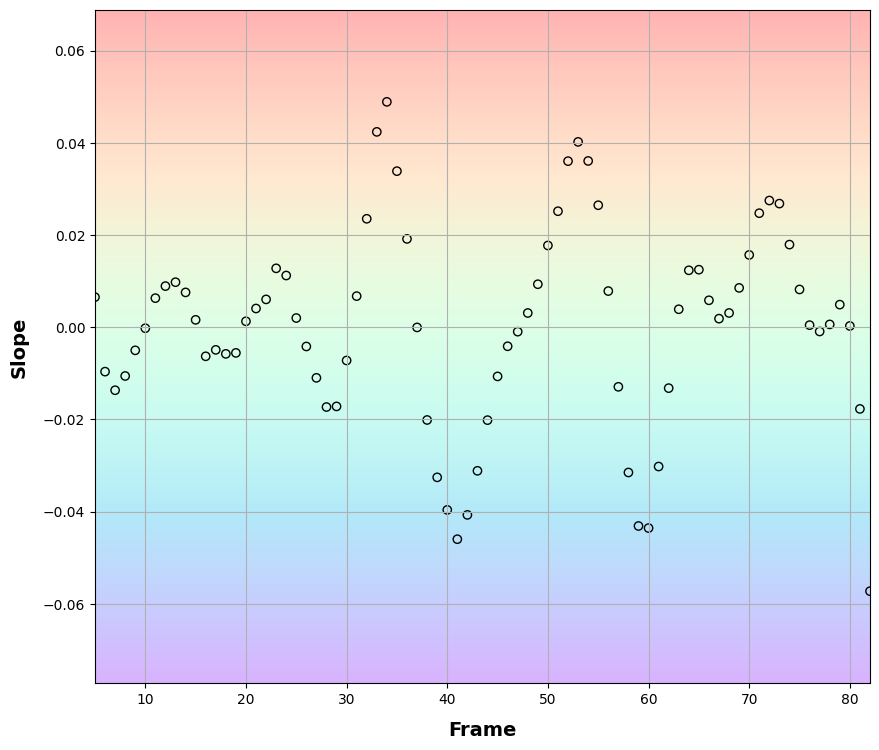

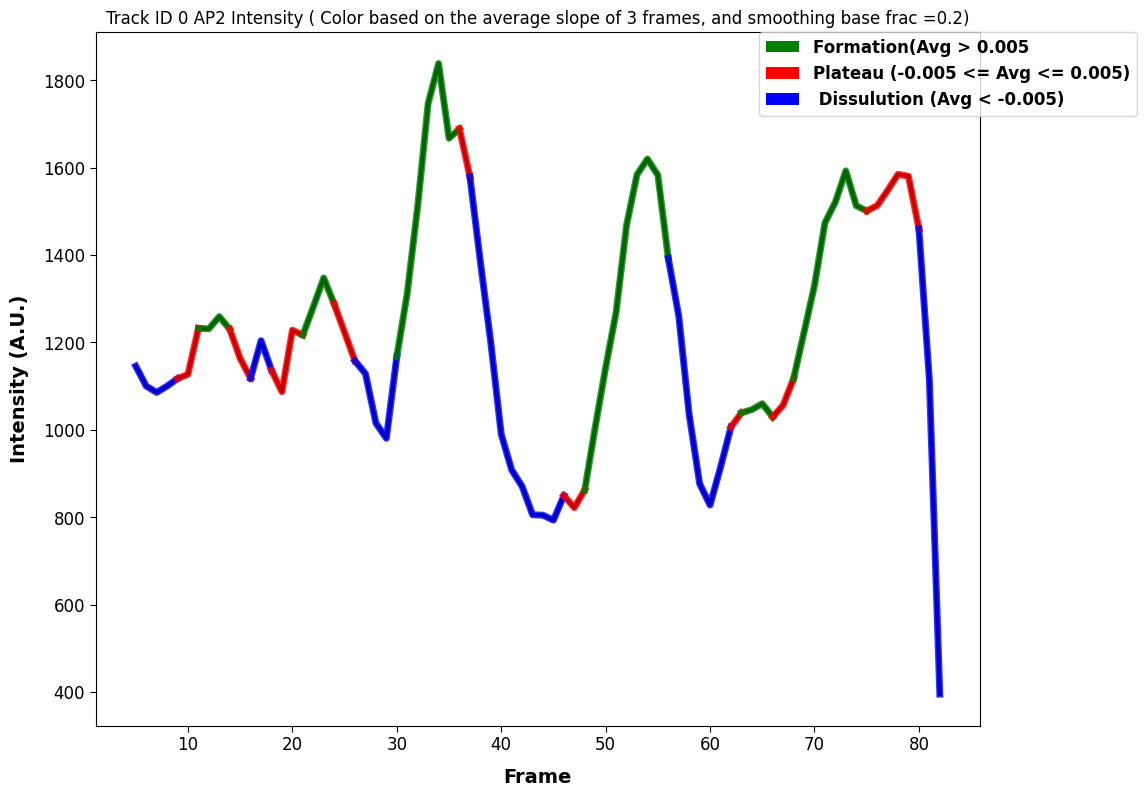

In [139]:
base_frac = 0.2
slope_apical_2, frame_apical_2 = smoothed_slope_plot(ccs_new_lumenoid_track_df, 0, new_lumenoid_frame_ms,poly=5, time_interval=10, base_frac=base_frac)
test_smooth_slope_color_coded_intensity_time_plot(dataframe = ccs_new_lumenoid_track_df, tracks_to_plot = 0, track_id_col_name = 'track_id', 
frame_col_name = 'frame', slope_list = slope_apical_2[0], avg_size=3, frame_list=np.array(frame_apical_2), threshold = 0.005, base_frac = base_frac, graph_title = 'AP2 Intensity', normalized=False, save_plot = False)